# CHECKING NVIDIA

In [ ]:
  !nvidia-smi

Tue May  5 20:14:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# INSTALLING LIBRARIES AND PREPARING ENVIROMENT

In [ ]:
!pip install -q "transformers>=4.56.0" "accelerate>=1.8.0" "huggingface_hub>=0.34.0,<1.0" "bitsandbytes>=0.46.0"
!pip install -q datasets scipy pandas tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 36.0 MB/s eta 0:00:00


In [ ]:
import os
import re
import gc
import ast
import json
import time
import math
import uuid
import shutil
import random
import tempfile
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm
from scipy.stats import mannwhitneyu
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, set_seed

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
!nvidia-smi

device: cuda
Tue May  5 20:15:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   40C    P8             14W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------

In [ ]:
BASE_MODEL = "deepseek-ai/deepseek-coder-6.7b-base"
MERGED_MODEL = "ori-ai-fabric/ds-trinity-7b-v1"

LAYER_ID = 12

# Comece pequeno para smoke test. Depois mude para None.
MAX_TASKS = None          # depois: None para 164
NUM_GENERATIONS = 1     # depois: 3 ou 10
MAX_NEW_TOKENS = 192

TEMPERATURE = 0.1
TOP_P = 1.0

PERF_REPEATS = 1
PERF_TIMEOUT_SECONDS = 5

ROOT_DIR = Path("recatcher_crosscoder_humaneval")
GEN_DIR = ROOT_DIR / "generations"
EVAL_DIR = ROOT_DIR / "evaluation"
ACT_DIR = ROOT_DIR / "activations"
CC_DIR = ROOT_DIR / "crosscoder"
STEER_DIR = ROOT_DIR / "steering"

for d in [GEN_DIR, EVAL_DIR, ACT_DIR, CC_DIR, STEER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(ROOT_DIR)

recatcher_crosscoder_humaneval


In [ ]:
dataset = load_dataset("openai/openai_humaneval", split="test")

examples = list(dataset)
if MAX_TASKS is not None:
    examples = examples[:MAX_TASKS]

print("num examples:", len(examples))
print(examples[0].keys())
print(examples[0]["prompt"][:500])

num examples: 164
dict_keys(['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point'])
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)
    True
    """



In [ ]:
def load_quantized_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=torch.float16,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        attn_implementation="eager",
    )

    model.eval()
    return model, tokenizer

In [ ]:
@torch.no_grad()
def generate_completion(model, tokenizer, prompt, seed=0):
    set_seed(seed)
    torch.manual_seed(seed)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
    ).to(model.device)

    output_ids = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=TEMPERATURE,
        top_p=TOP_P,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    gen_ids = output_ids[0, inputs["input_ids"].shape[1]:]
    completion = tokenizer.decode(gen_ids, skip_special_tokens=True)
    return completion

In [ ]:
def strip_markdown_fences(text):
    text = text.replace("```python", "```")

    if "```" in text:
        parts = text.split("```")
        if len(parts) >= 3:
            candidates = parts[1::2]
            return max(candidates, key=len).strip("\n")

    return text.strip("\n")


def truncate_completion(completion):
    """
    Cut common post-solution noise while preserving indentation.
    """

    markers = [
        "\n\nif __name__",
        "\nif __name__",
        "\n\n# Test",
        "\n# Test",
        "\n\n# test",
        "\n# test",
        "\n\nprint(",
        "\nprint(",
        "\n\nassert ",
        "\nassert ",
        "\n\nExplanation:",
        "\nExplanation:",
        "\n\nThe function",
        "\nThe function",
        "\n\nThis function",
        "\nThis function",
        "\n```",
    ]

    cut = len(completion)

    for marker in markers:
        idx = completion.find(marker)
        if idx != -1:
            cut = min(cut, idx)

    # If the model starts defining a new top-level function after the body,
    # cut there. This handles cases like HumanEval/2.
    for pattern in ["\n\ndef ", "\n\n\ndef "]:
        idx = completion.find(pattern)
        if idx != -1:
            cut = min(cut, idx)

    return completion[:cut].rstrip() + "\n"


def make_candidate_code(prompt, completion, entry_point):
    cleaned = strip_markdown_fences(completion)
    cleaned = truncate_completion(cleaned)

    function_marker = f"def {entry_point}"

    # If the model generated the full function, use it from that function onward.
    idx = cleaned.find(function_marker)

    if idx != -1:
        code = cleaned[idx:].rstrip() + "\n"
    else:
        # Critical: do NOT lstrip the completion.
        # HumanEval completions are usually indented function bodies.
        code = prompt.rstrip() + "\n" + cleaned.rstrip() + "\n"

    return code

def quick_syntax_check(code):
    try:
        ast.parse(code)
        return True, None
    except Exception as e:
        return False, repr(e)

In [ ]:
def run_candidate_in_subprocess(candidate_code, test_code, entry_point, repeats=5, timeout=10):
    """
    Execute candidate code in a subprocess.

    The temporary script:
    1. Defines the candidate solution.
    2. Defines HumanEval's check(candidate).
    3. Runs check once for correctness.
    4. Runs check multiple times to measure execution time.
    """

    script = f"""
import json
import time
import traceback
import math
import statistics
from typing import *

RESULT = {{"correct": False, "times": [], "error": None}}

try:
    exec({candidate_code!r}, globals())
    exec({test_code!r}, globals())

    check({entry_point})

    times = []
    for _ in range({repeats}):
        t0 = time.perf_counter()
        check({entry_point})
        t1 = time.perf_counter()
        times.append(t1 - t0)

    RESULT["correct"] = True
    RESULT["times"] = times

except Exception as e:
    RESULT["correct"] = False
    RESULT["times"] = []
    RESULT["error"] = repr(e) + "\\n" + traceback.format_exc(limit=3)

print(json.dumps(RESULT))
"""

    with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False) as f:
        f.write(script)
        path = f.name

    try:
        completed = subprocess.run(
            ["python", path],
            capture_output=True,
            text=True,
            timeout=timeout,
        )

        stdout = completed.stdout.strip()
        stderr = completed.stderr.strip()

        if completed.returncode != 0:
            return {
                "correct": False,
                "times": [],
                "error": f"returncode={completed.returncode}\nSTDOUT={stdout}\nSTDERR={stderr}",
            }

        if not stdout:
            return {
                "correct": False,
                "times": [],
                "error": f"empty stdout\nSTDERR={stderr}",
            }

        return json.loads(stdout.splitlines()[-1])

    except subprocess.TimeoutExpired:
        return {
            "correct": False,
            "times": [],
            "error": "timeout",
        }

    finally:
        try:
            os.remove(path)
        except OSError:
            pass

def indent_code(code, spaces):
    pad = " " * spaces
    return "\n".join(pad + line for line in code.splitlines())

In [ ]:
def generate_and_evaluate_model(model_name, model_label, examples, output_path):
    model, tokenizer = load_quantized_model(model_name)

    rows = []

    for task_idx, ex in enumerate(tqdm(examples, desc=f"Generating {model_label}")):
        task_id = ex["task_id"]
        prompt = ex["prompt"]
        test_code = ex["test"]
        entry_point = ex["entry_point"]

        for gen_idx in range(NUM_GENERATIONS):
            seed = 1000 + task_idx * 100 + gen_idx

            completion = generate_completion(
                model=model,
                tokenizer=tokenizer,
                prompt=prompt,
                seed=seed,
            )

            candidate_code = make_candidate_code(
                prompt=prompt,
                completion=completion,
                entry_point=entry_point,
            )

            syntax_ok, syntax_error = quick_syntax_check(candidate_code)

            if syntax_ok:
                eval_result = run_candidate_in_subprocess(
                    candidate_code=candidate_code,
                    test_code=test_code,
                    entry_point=entry_point,
                    repeats=PERF_REPEATS,
                    timeout=PERF_TIMEOUT_SECONDS,
                )
            else:
                eval_result = {
                    "correct": False,
                    "times": [],
                    "error": syntax_error,
                }

            row = {
                "model_label": model_label,
                "model_name": model_name,
                "task_idx": task_idx,
                "task_id": task_id,
                "gen_idx": gen_idx,
                "entry_point": entry_point,
                "prompt": prompt,
                "raw_completion": completion,
                "candidate_code": candidate_code,
                "syntax_ok": syntax_ok,
                "correct": bool(eval_result["correct"]),
                "times": eval_result["times"],
                "median_time": float(np.median(eval_result["times"])) if eval_result["times"] else None,
                "error": eval_result["error"],
            }

            rows.append(row)

            print(
                model_label,
                task_id,
                "gen",
                gen_idx,
                "syntax",
                syntax_ok,
                "correct",
                row["correct"],
                "median",
                row["median_time"],
            )

    with open(output_path, "w") as f:
        json.dump(rows, f, indent=2)

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return rows

In [ ]:
base_gen_path = GEN_DIR / "base_generations_v2.json"

base_rows = generate_and_evaluate_model(
    model_name=BASE_MODEL,
    model_label="base",
    examples=examples,
    output_path=base_gen_path,
)

df_base = pd.DataFrame(base_rows)
print("syntax_ok:", df_base["syntax_ok"].mean())
print("correct:", df_base["correct"].mean())
display(df_base[["task_id", "syntax_ok", "correct", "median_time", "error"]])

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Generating base:   0%|          | 0/164 [00:00<?, ?it/s]

base HumanEval/0 gen 0 syntax True correct True median 5.058000169810839e-06
base HumanEval/1 gen 0 syntax True correct False median None
base HumanEval/2 gen 0 syntax True correct True median 1.948999852174893e-06
base HumanEval/3 gen 0 syntax True correct True median 3.017999915755354e-06
base HumanEval/4 gen 0 syntax True correct True median 5.068999598734081e-06
base HumanEval/5 gen 0 syntax True correct False median None
base HumanEval/6 gen 0 syntax True correct True median 1.3011000191909261e-05
base HumanEval/7 gen 0 syntax True correct True median 3.7010004234616645e-06
base HumanEval/8 gen 0 syntax True correct True median 2.855999809980858e-06
base HumanEval/9 gen 0 syntax True correct True median 7.297999218280893e-06
base HumanEval/10 gen 0 syntax True correct False median None
base HumanEval/11 gen 0 syntax True correct True median 8.022999281820375e-06
base HumanEval/12 gen 0 syntax True correct True median 3.1700001272838563e-06
base HumanEval/13 gen 0 syntax True corre

,task_id,syntax_ok,correct,median_time,error
0,HumanEval/0,True,True,0.000005,None
1,HumanEval/1,True,False,NaN,AssertionError()\nTraceback (most recent call ...
2,HumanEval/2,True,True,0.000002,None
3,HumanEval/3,True,True,0.000003,None
4,HumanEval/4,True,True,0.000005,None
...,...,...,...,...,...
159,HumanEval/159,True,False,NaN,AssertionError('Error')\nTraceback (most recen...
160,HumanEval/160,True,False,NaN,AssertionError()\nTraceback (most recent call ...
161,HumanEval/161,True,False,NaN,AssertionError()\nTraceback (most recent call ...
162,HumanEval/162,True,False,NaN,"NameError(""name 'hashlib' is not defined"")\nTr..."


In [ ]:
merged_gen_path = GEN_DIR / "merged_generations_v2.json"

merged_rows = generate_and_evaluate_model(
    model_name=MERGED_MODEL,
    model_label="merged",
    examples=examples,
    output_path=merged_gen_path,
)

df_merged = pd.DataFrame(merged_rows)
print("syntax_ok:", df_merged["syntax_ok"].mean())
print("correct:", df_merged["correct"].mean())
display(df_merged[["task_id", "syntax_ok", "correct", "median_time", "error"]])

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00007.safetensors:   0%|          | 0.00/1.99G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

Generating merged:   0%|          | 0/164 [00:00<?, ?it/s]

merged HumanEval/0 gen 0 syntax True correct True median 4.915998943033628e-06
merged HumanEval/1 gen 0 syntax True correct False median None
merged HumanEval/2 gen 0 syntax True correct True median 1.962998794624582e-06
merged HumanEval/3 gen 0 syntax True correct True median 2.999999196617864e-06
merged HumanEval/4 gen 0 syntax True correct True median 6.009999196976423e-06
merged HumanEval/5 gen 0 syntax True correct True median 3.598999683163129e-06
merged HumanEval/6 gen 0 syntax True correct True median 9.676001354819164e-06
merged HumanEval/7 gen 0 syntax True correct True median 3.5189987102057785e-06
merged HumanEval/8 gen 0 syntax True correct True median 3.301700053270906e-05
merged HumanEval/9 gen 0 syntax True correct False median None
merged HumanEval/10 gen 0 syntax True correct True median 6.555001164088026e-06
merged HumanEval/11 gen 0 syntax True correct True median 3.376999302417971e-06
merged HumanEval/12 gen 0 syntax True correct True median 3.254001057939604e-06
m

,task_id,syntax_ok,correct,median_time,error
0,HumanEval/0,True,True,0.000005,None
1,HumanEval/1,True,False,NaN,AssertionError()\nTraceback (most recent call ...
2,HumanEval/2,True,True,0.000002,None
3,HumanEval/3,True,True,0.000003,None
4,HumanEval/4,True,True,0.000006,None
...,...,...,...,...,...
159,HumanEval/159,True,True,0.000002,None
160,HumanEval/160,True,True,0.000031,None
161,HumanEval/161,True,True,0.000013,None
162,HumanEval/162,True,True,0.000006,None


In [ ]:
print("BASE")
print("syntax_ok:", df_base["syntax_ok"].mean())
print("correct:", df_base["correct"].mean())

print("\nMERGED")
print("syntax_ok:", df_merged["syntax_ok"].mean())
print("correct:", df_merged["correct"].mean())

BASE
syntax_ok: 0.9695121951219512
correct: 0.40853658536585363

MERGED
syntax_ok: 0.9878048780487805
correct: 0.7195121951219512


In [ ]:
summary_generation = {
    "base_rows": len(df_base),
    "merged_rows": len(df_merged),
    "base_syntax_ok_rate": float(df_base["syntax_ok"].mean()),
    "base_correct_rate": float(df_base["correct"].mean()),
    "merged_syntax_ok_rate": float(df_merged["syntax_ok"].mean()),
    "merged_correct_rate": float(df_merged["correct"].mean()),
}

summary_generation

{'base_rows': 164,
 'merged_rows': 164,
 'base_syntax_ok_rate': 0.9695121951219512,
 'base_correct_rate': 0.40853658536585363,
 'merged_syntax_ok_rate': 0.9878048780487805,
 'merged_correct_rate': 0.7195121951219512}

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import mannwhitneyu

base_gen_path = GEN_DIR / "base_generations_v2.json"
merged_gen_path = GEN_DIR / "merged_generations_v2.json"

with open(base_gen_path) as f:
    base_rows = json.load(f)

with open(merged_gen_path) as f:
    merged_rows = json.load(f)

print("Base rows:", len(base_rows))
print("Merged rows:", len(merged_rows))

df_base = pd.DataFrame(base_rows)
df_merged = pd.DataFrame(merged_rows)

print("\nBase quality:")
print("syntax_ok:", df_base["syntax_ok"].mean())
print("correct:", df_base["correct"].mean())

print("\nMerged quality:")
print("syntax_ok:", df_merged["syntax_ok"].mean())
print("correct:", df_merged["correct"].mean())

display(df_base[["task_id", "syntax_ok", "correct", "median_time", "error"]].head(20))
display(df_merged[["task_id", "syntax_ok", "correct", "median_time", "error"]].head(20))

Base rows: 164
Merged rows: 164

Base quality:
syntax_ok: 0.9695121951219512
correct: 0.40853658536585363

Merged quality:
syntax_ok: 0.9878048780487805
correct: 0.7195121951219512


,task_id,syntax_ok,correct,median_time,error
0,HumanEval/0,True,True,0.000005,None
1,HumanEval/1,True,False,NaN,AssertionError()\nTraceback (most recent call ...
2,HumanEval/2,True,True,0.000002,None
3,HumanEval/3,True,True,0.000003,None
4,HumanEval/4,True,True,0.000005,None
5,HumanEval/5,True,False,NaN,IndexError('list index out of range')\nTraceba...
6,HumanEval/6,True,True,0.000013,None
7,HumanEval/7,True,True,0.000004,None
8,HumanEval/8,True,True,0.000003,None
9,HumanEval/9,True,True,0.000007,None


,task_id,syntax_ok,correct,median_time,error
0,HumanEval/0,True,True,0.000005,None
1,HumanEval/1,True,False,NaN,AssertionError()\nTraceback (most recent call ...
2,HumanEval/2,True,True,0.000002,None
3,HumanEval/3,True,True,0.000003,None
4,HumanEval/4,True,True,0.000006,None
5,HumanEval/5,True,True,0.000004,None
6,HumanEval/6,True,True,0.000010,None
7,HumanEval/7,True,True,0.000004,None
8,HumanEval/8,True,True,0.000033,None
9,HumanEval/9,True,False,NaN,IndexError('list index out of range')\nTraceba...


In [ ]:
def show_failures(df, rows, n=10):
    failed = df[~df["correct"]].head(n)

    for _, row in failed.iterrows():
        r = rows[int(row.name)]

        print("=" * 120)
        print("TASK:", r["task_id"])
        print("syntax_ok:", r["syntax_ok"], "correct:", r["correct"])
        print("error:", r["error"])

        print("\n--- RAW COMPLETION ---")
        print(r["raw_completion"][:1200])

        print("\n--- CANDIDATE CODE ---")
        print(r["candidate_code"][:1200])


print("BASE FAILURES")
show_failures(df_base, base_rows, n=5)

print("\n\nMERGED FAILURES")
show_failures(df_merged, merged_rows, n=5)

BASE FAILURES
TASK: HumanEval/1
syntax_ok: True correct: False
error: AssertionError()
Traceback (most recent call last):
  File "/tmp/tmphdztvqln.py", line 15, in <module>
    check(separate_paren_groups)
  File "<string>", line 10, in check
AssertionError


--- RAW COMPLETION ---
    # TODO: Implement me
    pass

--- CANDIDATE CODE ---
from typing import List


def separate_paren_groups(paren_string: str) -> List[str]:
    """ Input to this function is a string containing multiple groups of nested parentheses. Your goal is to
    separate those group into separate strings and return the list of those.
    Separate groups are balanced (each open brace is properly closed) and not nested within each other
    Ignore any spaces in the input string.
    >>> separate_paren_groups('( ) (( )) (( )( ))')
    ['()', '(())', '(()())']
    """
    # TODO: Implement me
    pass

TASK: HumanEval/5
syntax_ok: True correct: False
error: IndexError('list index out of range')
Traceback (most recent c

In [ ]:
def classify_task_performance(base_task_rows, merged_task_rows, pvalue_threshold=0.05):
    # Performance comparison is only meaningful when both models have correct code.
    base_correct = [r for r in base_task_rows if r["correct"] and r["times"]]
    merged_correct = [r for r in merged_task_rows if r["correct"] and r["times"]]

    if len(base_correct) == 0 or len(merged_correct) == 0:
        return {
            "label": "incorrect",
            "reason": "one_or_both_models_no_correct_generation",
            "base_correct_count": len(base_correct),
            "merged_correct_count": len(merged_correct),
            "base_median": None,
            "merged_median": None,
            "speedup_ratio": None,
            "pvalue": None,
        }

    base_times = np.array([t for r in base_correct for t in r["times"]], dtype=np.float64)
    merged_times = np.array([t for r in merged_correct for t in r["times"]], dtype=np.float64)

    base_median = float(np.median(base_times))
    merged_median = float(np.median(merged_times))

    speedup_ratio = float(base_median / merged_median) if merged_median > 0 else None

    try:
        _, pvalue = mannwhitneyu(base_times, merged_times, alternative="two-sided")
        pvalue = float(pvalue)
    except Exception:
        pvalue = None

    if pvalue is not None and pvalue < pvalue_threshold:
        if merged_median < base_median:
            label = "merged_faster"
        elif base_median < merged_median:
            label = "base_faster"
        else:
            label = "same"
    else:
        label = "same"

    return {
        "label": label,
        "reason": "mann_whitney" if pvalue is not None else "fallback",
        "base_correct_count": len(base_correct),
        "merged_correct_count": len(merged_correct),
        "base_median": base_median,
        "merged_median": merged_median,
        "speedup_ratio": speedup_ratio,
        "pvalue": pvalue,
    }


base_by_task = {}
merged_by_task = {}

for r in base_rows:
    base_by_task.setdefault(r["task_id"], []).append(r)

for r in merged_rows:
    merged_by_task.setdefault(r["task_id"], []).append(r)

task_labels = []

for task_idx, ex in enumerate(examples):
    task_id = ex["task_id"]

    cls = classify_task_performance(
        base_by_task.get(task_id, []),
        merged_by_task.get(task_id, []),
    )

    cls["task_id"] = task_id
    cls["task_idx"] = task_idx
    task_labels.append(cls)

with open(EVAL_DIR / "task_performance_labels_v3.json", "w") as f:
    json.dump(task_labels, f, indent=2)

df_labels = pd.DataFrame(task_labels)

display(df_labels)
print(df_labels["label"].value_counts())

,label,reason,base_correct_count,merged_correct_count,base_median,merged_median,speedup_ratio,pvalue,task_id,task_idx
0,same,mann_whitney,1,1,0.000005,0.000005,1.028886,1.0,HumanEval/0,0
1,incorrect,one_or_both_models_no_correct_generation,0,0,NaN,NaN,NaN,NaN,HumanEval/1,1
2,same,mann_whitney,1,1,0.000002,0.000002,0.992869,1.0,HumanEval/2,2
3,same,mann_whitney,1,1,0.000003,0.000003,1.006000,1.0,HumanEval/3,3
4,same,mann_whitney,1,1,0.000005,0.000006,0.843428,1.0,HumanEval/4,4
...,...,...,...,...,...,...,...,...,...,...
159,incorrect,one_or_both_models_no_correct_generation,0,1,NaN,NaN,NaN,NaN,HumanEval/159,159
160,incorrect,one_or_both_models_no_correct_generation,0,1,NaN,NaN,NaN,NaN,HumanEval/160,160
161,incorrect,one_or_both_models_no_correct_generation,0,1,NaN,NaN,NaN,NaN,HumanEval/161,161
162,incorrect,one_or_both_models_no_correct_generation,0,1,NaN,NaN,NaN,NaN,HumanEval/162,162


label
incorrect    100
same          64
Name: count, dtype: int64


In [ ]:
total = len(df_labels)

summary = {
    "total_tasks": int(total),
    "merged_faster": int((df_labels["label"] == "merged_faster").sum()),
    "base_faster": int((df_labels["label"] == "base_faster").sum()),
    "same": int((df_labels["label"] == "same").sum()),
    "incorrect": int((df_labels["label"] == "incorrect").sum()),
}

for key in ["merged_faster", "base_faster", "same", "incorrect"]:
    summary[f"{key}_rate"] = summary[key] / total if total else 0.0

with open(EVAL_DIR / "mini_recatcher_summary_v3.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'total_tasks': 164,
 'merged_faster': 0,
 'base_faster': 0,
 'same': 64,
 'incorrect': 100,
 'merged_faster_rate': 0.0,
 'base_faster_rate': 0.0,
 'same_rate': 0.3902439024390244,
 'incorrect_rate': 0.6097560975609756}

In [ ]:
# Build task-level correctness labels.
# We care especially about tasks where the merged model is correct and the base model is not.

base_by_task = {r["task_id"]: r for r in base_rows}
merged_by_task = {r["task_id"]: r for r in merged_rows}

correctness_labels = []
for task_idx, ex in enumerate(examples):
    task_id = ex["task_id"]

    b = base_by_task[task_id]
    m = merged_by_task[task_id]

    base_correct = bool(b["correct"])
    merged_correct = bool(m["correct"])

    if base_correct and merged_correct:
        label = "both_correct"
    elif (not base_correct) and merged_correct:
        label = "merged_only_correct"
    elif base_correct and (not merged_correct):
        label = "base_only_correct"
    else:
        label = "both_incorrect"

    correctness_labels.append({
        "task_idx": task_idx,
        "task_id": task_id,
        "label": label,
        "base_correct": base_correct,
        "merged_correct": merged_correct,
        "base_syntax_ok": bool(b["syntax_ok"]),
        "merged_syntax_ok": bool(m["syntax_ok"]),
        "base_median_time": b["median_time"],
        "merged_median_time": m["median_time"],
    })

df_correctness = pd.DataFrame(correctness_labels)

display(df_correctness)
print(df_correctness["label"].value_counts())

with open(EVAL_DIR / "task_correctness_labels_v3.json", "w") as f:
    json.dump(correctness_labels, f, indent=2)

,task_idx,task_id,label,base_correct,merged_correct,base_syntax_ok,merged_syntax_ok,base_median_time,merged_median_time
0,0,HumanEval/0,both_correct,True,True,True,True,0.000005,0.000005
1,1,HumanEval/1,both_incorrect,False,False,True,True,NaN,NaN
2,2,HumanEval/2,both_correct,True,True,True,True,0.000002,0.000002
3,3,HumanEval/3,both_correct,True,True,True,True,0.000003,0.000003
4,4,HumanEval/4,both_correct,True,True,True,True,0.000005,0.000006
...,...,...,...,...,...,...,...,...,...
159,159,HumanEval/159,merged_only_correct,False,True,True,True,NaN,0.000002
160,160,HumanEval/160,merged_only_correct,False,True,True,True,NaN,0.000031
161,161,HumanEval/161,merged_only_correct,False,True,True,True,NaN,0.000013
162,162,HumanEval/162,merged_only_correct,False,True,True,True,NaN,0.000006


label
both_correct           64
merged_only_correct    54
both_incorrect         43
base_only_correct       3
Name: count, dtype: int64


In [ ]:
total = len(df_correctness)

summary_correctness = {
    "total_tasks": int(total),
    "base_correct": int(df_correctness["base_correct"].sum()),
    "merged_correct": int(df_correctness["merged_correct"].sum()),
    "base_correct_rate": float(df_correctness["base_correct"].mean()),
    "merged_correct_rate": float(df_correctness["merged_correct"].mean()),
    "both_correct": int((df_correctness["label"] == "both_correct").sum()),
    "merged_only_correct": int((df_correctness["label"] == "merged_only_correct").sum()),
    "base_only_correct": int((df_correctness["label"] == "base_only_correct").sum()),
    "both_incorrect": int((df_correctness["label"] == "both_incorrect").sum()),
}

summary_correctness["absolute_correctness_gain"] = (
    summary_correctness["merged_correct_rate"] -
    summary_correctness["base_correct_rate"]
)

summary_correctness

with open(EVAL_DIR / "correctness_summary_v3.json", "w") as f:
    json.dump(summary_correctness, f, indent=2)

summary_correctness

{'total_tasks': 164,
 'base_correct': 67,
 'merged_correct': 118,
 'base_correct_rate': 0.40853658536585363,
 'merged_correct_rate': 0.7195121951219512,
 'both_correct': 64,
 'merged_only_correct': 54,
 'base_only_correct': 3,
 'both_incorrect': 43,
 'absolute_correctness_gain': 0.31097560975609756}

In [ ]:
# Build texts for activation capture.
# Each generated candidate solution becomes one activation example.
# We will pass the same text through both models and compare their internal activations.

label_by_task = {
    row["task_id"]: row
    for row in correctness_labels
}

activation_texts = []

def add_activation_texts(rows, source_model):
    for r in rows:
        task_label = label_by_task[r["task_id"]]["label"]

        # Use the actual tested code.
        # This avoids extra markdown/explanations that were removed by the extraction pipeline.
        full_text = r["candidate_code"]

        activation_texts.append({
            "text_id": len(activation_texts),
            "source_model": source_model,
            "task_id": r["task_id"],
            "task_idx": r["task_idx"],
            "gen_idx": r["gen_idx"],
            "entry_point": r["entry_point"],
            "task_label": task_label,
            "source_correct": bool(r["correct"]),
            "base_correct": bool(label_by_task[r["task_id"]]["base_correct"]),
            "merged_correct": bool(label_by_task[r["task_id"]]["merged_correct"]),
            "prompt": r["prompt"],
            "raw_completion": r["raw_completion"],
            "candidate_code": r["candidate_code"],
            "full_text": full_text,
            "median_time": r["median_time"],
        })

add_activation_texts(base_rows, "base")
add_activation_texts(merged_rows, "merged")

with open(ACT_DIR / "activation_texts_correctness_v3.json", "w") as f:
    json.dump(activation_texts, f, indent=2)

df_activation_texts = pd.DataFrame(activation_texts)

print("Activation texts:", len(activation_texts))
display(
    df_activation_texts[
        ["source_model", "task_label", "source_correct", "base_correct", "merged_correct"]
    ].value_counts().reset_index(name="count")
)

Activation texts: 328


,source_model,task_label,source_correct,base_correct,merged_correct,count
0,base,both_correct,True,True,True,64
1,merged,both_correct,True,True,True,64
2,merged,merged_only_correct,True,False,True,54
3,base,merged_only_correct,False,False,True,54
4,merged,both_incorrect,False,False,False,43
5,base,both_incorrect,False,False,False,43
6,base,base_only_correct,True,True,False,3
7,merged,base_only_correct,False,True,False,3


In [ ]:
def get_layer_activations_for_full_text(model, tokenizer, full_text, prompt, layer_id=12, max_length=1536):
    inputs = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    ).to(model.device)

    prompt_ids = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )["input_ids"][0]

    prompt_len = int(prompt_ids.shape[0])

    captured = {}

    def hook_fn(module, module_input, module_output):
        if isinstance(module_output, tuple):
            hidden = module_output[0]
        else:
            hidden = module_output

        # Store activations in float16 to reduce disk usage.
        captured["activation"] = hidden.detach().to(torch.float16).cpu()

    hook = model.model.layers[layer_id].register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(**inputs, use_cache=False)

    hook.remove()

    return {
        "activation": captured["activation"].numpy(),
        "input_ids": inputs["input_ids"].detach().cpu().numpy(),
        "prompt_len": prompt_len,
    }

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
!df -h
!du -sh ~/.cache/huggingface 2>/dev/null || true
!du -sh /root/.cache/huggingface 2>/dev/null || true
!du -sh recatcher_crosscoder_humaneval 2>/dev/null || true
!du -sh /content/* 2>/dev/null | sort -h | tail -20

Filesystem      Size  Used Avail Use% Mounted on
overlay          95G   95G     0 100% /
tmpfs            64M     0   64M   0% /dev
shm             7.6G  4.0K  7.6G   1% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/nvme0n2     98G  553M   98G   1% /content
tmpfs           7.9G  3.3M  7.9G   1% /var/colab
/dev/nvme0n1p1   95G   95G     0 100% /etc/hosts
tmpfs           7.9G     0  7.9G   0% /proc/acpi
tmpfs           7.9G     0  7.9G   0% /proc/scsi
tmpfs           7.9G     0  7.9G   0% /sys/firmware
25G	/root/.cache/huggingface
25G	/root/.cache/huggingface
553M	recatcher_crosscoder_humaneval
553M	/content/recatcher_crosscoder_humaneval


In [ ]:
!rm -rf /root/.cache/huggingface/hub
!rm -rf /root/.cache/huggingface/assets
!rm -rf /root/.cache/huggingface/xet
!df -h
!du -sh /root/.cache/huggingface 2>/dev/null || true

Filesystem      Size  Used Avail Use% Mounted on
overlay          95G   70G   25G  74% /
tmpfs            64M     0   64M   0% /dev
shm             7.6G  4.0K  7.6G   1% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/nvme0n2     98G  553M   98G   1% /content
tmpfs           7.9G  3.3M  7.9G   1% /var/colab
/dev/nvme0n1p1   95G   70G   25G  74% /etc/hosts
tmpfs           7.9G     0  7.9G   0% /proc/acpi
tmpfs           7.9G     0  7.9G   0% /proc/scsi
tmpfs           7.9G     0  7.9G   0% /sys/firmware
220K	/root/.cache/huggingface


In [ ]:
BASE_ACT_OUTPUT_DIR = ACT_DIR / f"base_layer_{LAYER_ID}_correctness_v3"
BASE_ACT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

base_act_metadata_path = ACT_DIR / "base_activation_metadata_correctness_v3.json"

if base_act_metadata_path.exists():
    with open(base_act_metadata_path) as f:
        base_act_metadata = json.load(f)
    print("Loaded base activation metadata:", len(base_act_metadata))
else:
    base_model, tokenizer = load_quantized_model(BASE_MODEL)

    base_act_metadata = []

    for item in tqdm(activation_texts, desc="Capturing base activations"):
        text_id = item["text_id"]

        out = get_layer_activations_for_full_text(
            model=base_model,
            tokenizer=tokenizer,
            full_text=item["full_text"],
            prompt=item["prompt"],
            layer_id=LAYER_ID,
            max_length=1536,
        )

        act_path = BASE_ACT_OUTPUT_DIR / f"text_{text_id:05d}.npy"
        ids_path = BASE_ACT_OUTPUT_DIR / f"text_{text_id:05d}_input_ids.npy"

        np.save(act_path, out["activation"])
        np.save(ids_path, out["input_ids"])

        meta = {
            **{k: item[k] for k in [
                "text_id",
                "source_model",
                "task_id",
                "task_idx",
                "gen_idx",
                "entry_point",
                "task_label",
                "source_correct",
                "base_correct",
                "merged_correct",
                "median_time",
            ]},
            "activation_path": str(act_path),
            "input_ids_path": str(ids_path),
            "activation_shape": list(out["activation"].shape),
            "prompt_len": int(out["prompt_len"]),
        }

        base_act_metadata.append(meta)

        # Save incrementally.
        with open(base_act_metadata_path, "w") as f:
            json.dump(base_act_metadata, f, indent=2)

    del base_model
    gc.collect()
    torch.cuda.empty_cache()

print("Base activations:", len(base_act_metadata))

tokenizer_config.json:   0%|          | 0.00/793 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

Capturing base activations:   0%|          | 0/328 [00:00<?, ?it/s]

Base activations: 328


In [ ]:
MERGED_ACT_OUTPUT_DIR = ACT_DIR / f"merged_layer_{LAYER_ID}_correctness_v3"
MERGED_ACT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

merged_act_metadata_path = ACT_DIR / "merged_activation_metadata_correctness_v3.json"

if merged_act_metadata_path.exists():
    with open(merged_act_metadata_path) as f:
        merged_act_metadata = json.load(f)
    print("Loaded merged activation metadata:", len(merged_act_metadata))
else:
    merged_model, tokenizer = load_quantized_model(MERGED_MODEL)

    merged_act_metadata = []

    for item in tqdm(activation_texts, desc="Capturing merged activations"):
        text_id = item["text_id"]

        out = get_layer_activations_for_full_text(
            model=merged_model,
            tokenizer=tokenizer,
            full_text=item["full_text"],
            prompt=item["prompt"],
            layer_id=LAYER_ID,
            max_length=1536,
        )

        act_path = MERGED_ACT_OUTPUT_DIR / f"text_{text_id:05d}.npy"
        ids_path = MERGED_ACT_OUTPUT_DIR / f"text_{text_id:05d}_input_ids.npy"

        np.save(act_path, out["activation"])
        np.save(ids_path, out["input_ids"])

        meta = {
            **{k: item[k] for k in [
                "text_id",
                "source_model",
                "task_id",
                "task_idx",
                "gen_idx",
                "entry_point",
                "task_label",
                "source_correct",
                "base_correct",
                "merged_correct",
                "median_time",
            ]},
            "activation_path": str(act_path),
            "input_ids_path": str(ids_path),
            "activation_shape": list(out["activation"].shape),
            "prompt_len": int(out["prompt_len"]),
        }

        merged_act_metadata.append(meta)

        # Save incrementally.
        with open(merged_act_metadata_path, "w") as f:
            json.dump(merged_act_metadata, f, indent=2)

    del merged_model
    gc.collect()
    torch.cuda.empty_cache()

print("Merged activations:", len(merged_act_metadata))

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00007-of-00007.safetensors:   0%|          | 0.00/1.84G [00:00<?, ?B/s]

model-00005-of-00007.safetensors:   0%|          | 0.00/1.75G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

Capturing merged activations:   0%|          | 0/328 [00:00<?, ?it/s]

Merged activations: 328


In [ ]:
assert len(base_act_metadata) == len(merged_act_metadata)

all_base = []
all_merged = []
paired_index = []

offset = 0

for b, m in tqdm(list(zip(base_act_metadata, merged_act_metadata)), desc="Consolidating"):
    assert b["text_id"] == m["text_id"]
    assert b["task_id"] == m["task_id"]

    base_act = np.load(b["activation_path"])
    merged_act = np.load(m["activation_path"])

    base_ids = np.load(b["input_ids_path"])
    merged_ids = np.load(m["input_ids_path"])

    min_seq = min(
        base_act.shape[1],
        merged_act.shape[1],
        base_ids.shape[1],
        merged_ids.shape[1],
    )

    # Keep only candidate solution tokens after the original prompt.
    prompt_len = min(b["prompt_len"], m["prompt_len"], min_seq - 1)

    start_pos = prompt_len
    end_pos = min_seq

    if end_pos <= start_pos:
        continue

    base_tokens = base_act[0, start_pos:end_pos, :]
    merged_tokens = merged_act[0, start_pos:end_pos, :]

    num_tokens = base_tokens.shape[0]

    all_base.append(base_tokens)
    all_merged.append(merged_tokens)

    paired_index.append({
        "text_id": b["text_id"],
        "task_id": b["task_id"],
        "task_idx": b["task_idx"],
        "gen_idx": b["gen_idx"],
        "source_model": b["source_model"],
        "task_label": b["task_label"],
        "source_correct": b["source_correct"],
        "base_correct": b["base_correct"],
        "merged_correct": b["merged_correct"],
        "median_time": b["median_time"],
        "prompt_len": int(prompt_len),
        "local_start_pos": int(start_pos),
        "local_end_pos": int(end_pos),
        "global_start": int(offset),
        "global_end": int(offset + num_tokens),
        "num_tokens": int(num_tokens),
        "input_ids_path": b["input_ids_path"],
    })

    offset += num_tokens

X_base = np.concatenate(all_base, axis=0).astype(np.float16)
X_merged = np.concatenate(all_merged, axis=0).astype(np.float16)

print("X_base:", X_base.shape, X_base.dtype)
print("X_merged:", X_merged.shape, X_merged.dtype)

CC_READY_DIR = ACT_DIR / "crosscoder_ready_correctness_v3"
CC_READY_DIR.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    CC_READY_DIR / f"base_vs_merged_layer_{LAYER_ID}_correctness_v3.npz",
    X_base=X_base,
    X_merged=X_merged,
)

with open(CC_READY_DIR / "paired_index_correctness_v3.json", "w") as f:
    json.dump(paired_index, f, indent=2)

summary_activations = {
    "base_model": BASE_MODEL,
    "merged_model": MERGED_MODEL,
    "layer_id": LAYER_ID,
    "num_texts": len(paired_index),
    "X_base_shape": list(X_base.shape),
    "X_merged_shape": list(X_merged.shape),
    "outputs_only": True,
    "objective": "correctness_gain",
}

with open(CC_READY_DIR / "summary_correctness_v3.json", "w") as f:
    json.dump(summary_activations, f, indent=2)

summary_activations

Consolidating:   0%|          | 0/328 [00:00<?, ?it/s]

X_base: (18999, 4096) float16
X_merged: (18999, 4096) float16


{'base_model': 'deepseek-ai/deepseek-coder-6.7b-base',
 'merged_model': 'ori-ai-fabric/ds-trinity-7b-v1',
 'layer_id': 12,
 'num_texts': 328,
 'X_base_shape': [18999, 4096],
 'X_merged_shape': [18999, 4096],
 'outputs_only': True,
 'objective': 'correctness_gain'}

In [ ]:
data = np.load(CC_READY_DIR / f"base_vs_merged_layer_{LAYER_ID}_correctness_v3.npz")

X_base = data["X_base"]
X_merged = data["X_merged"]

print("Loaded:", X_base.shape, X_base.dtype, X_merged.shape, X_merged.dtype)

# Remove extreme activation outliers.
norm_base = np.linalg.norm(X_base.astype(np.float32), axis=1)
norm_merged = np.linalg.norm(X_merged.astype(np.float32), axis=1)

mask = (norm_base < 500) & (norm_merged < 500)

print("Before:", X_base.shape[0])
print("After:", int(mask.sum()))
print("Removed:", int((~mask).sum()))

X_base = X_base[mask]
X_merged = X_merged[mask]

def rms_normalize_np(x, eps=1e-6):
    x = x.astype(np.float32)
    rms = np.sqrt(np.mean(x ** 2, axis=1, keepdims=True) + eps)
    return x / rms, rms

X_base_norm, rms_base = rms_normalize_np(X_base)
X_merged_norm, rms_merged = rms_normalize_np(X_merged)

X_base_t = torch.from_numpy(X_base_norm).float()
X_merged_t = torch.from_numpy(X_merged_norm).float()

N, d_model = X_base_t.shape

print("N:", N)
print("d_model:", d_model)

Loaded: (18999, 4096) float16 (18999, 4096) float16
Before: 18999
After: 18931
Removed: 68
N: 18931
d_model: 4096


In [ ]:
class CrossCoder(nn.Module):
    def __init__(self, d_model, d_hidden):
        super().__init__()

        self.encoder_base = nn.Linear(d_model, d_hidden, bias=False)
        self.encoder_merged = nn.Linear(d_model, d_hidden, bias=False)

        self.encoder_bias = nn.Parameter(torch.zeros(d_hidden))

        self.decoder_base = nn.Linear(d_hidden, d_model, bias=False)
        self.decoder_merged = nn.Linear(d_hidden, d_model, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.encoder_base.weight, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.encoder_merged.weight, a=math.sqrt(5))
        nn.init.normal_(self.decoder_base.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.decoder_merged.weight, mean=0.0, std=0.02)

    def encode(self, x_base, x_merged):
        pre = (
            self.encoder_base(x_base)
            + self.encoder_merged(x_merged)
            + self.encoder_bias
        )
        return F.relu(pre)

    def forward(self, x_base, x_merged):
        z = self.encode(x_base, x_merged)
        xhat_base = self.decoder_base(z)
        xhat_merged = self.decoder_merged(z)
        return xhat_base, xhat_merged, z

In [ ]:
d_hidden = 4096
batch_size = 512
num_steps = 3000
lr = 1e-3
lambda_l1 = 3e-3

cc_model = CrossCoder(d_model=d_model, d_hidden=d_hidden).to(device)
optimizer = torch.optim.AdamW(cc_model.parameters(), lr=lr, weight_decay=0.0)

loss_history = []
start_time = time.time()

for step in range(1, num_steps + 1):
    idx = torch.randint(0, N, (batch_size,))

    xb = X_base_t[idx].to(device)
    xm = X_merged_t[idx].to(device)

    xhat_b, xhat_m, z = cc_model(xb, xm)

    recon_loss = F.mse_loss(xhat_b, xb) + F.mse_loss(xhat_m, xm)
    sparse_loss = z.abs().mean()

    loss = recon_loss + lambda_l1 * sparse_loss

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    record = {
        "step": step,
        "loss": float(loss.detach().cpu()),
        "recon_loss": float(recon_loss.detach().cpu()),
        "sparse_loss": float(sparse_loss.detach().cpu()),
        "active_frac": float((z.detach() > 0).float().mean().cpu()),
    }

    loss_history.append(record)

    if step % 100 == 0 or step == 1:
        elapsed = time.time() - start_time
        print(
            f"step={step:04d} "
            f"loss={record['loss']:.5f} "
            f"recon={record['recon_loss']:.5f} "
            f"sparse={record['sparse_loss']:.5f} "
            f"active_frac={record['active_frac']:.4f} "
            f"elapsed={elapsed:.1f}s"
        )

step=0001 loss=3.08033 recon=3.07937 sparse=0.32027 active_frac=0.4958 elapsed=0.3s
step=0100 loss=0.79406 recon=0.79375 sparse=0.10065 active_frac=0.0548 elapsed=4.3s
step=0200 loss=0.61185 recon=0.61142 sparse=0.14444 active_frac=0.0730 elapsed=8.3s
step=0300 loss=0.52283 recon=0.52234 sparse=0.16460 active_frac=0.0824 elapsed=12.3s
step=0400 loss=0.50203 recon=0.50150 sparse=0.17545 active_frac=0.0889 elapsed=16.3s
step=0500 loss=0.48316 recon=0.48261 sparse=0.18133 active_frac=0.0927 elapsed=20.3s
step=0600 loss=0.46283 recon=0.46228 sparse=0.18277 active_frac=0.0952 elapsed=24.4s
step=0700 loss=0.45846 recon=0.45790 sparse=0.18795 active_frac=0.0975 elapsed=28.4s
step=0800 loss=0.45932 recon=0.45876 sparse=0.18725 active_frac=0.0984 elapsed=32.4s
step=0900 loss=0.44475 recon=0.44419 sparse=0.18692 active_frac=0.0997 elapsed=36.4s
step=1000 loss=0.43201 recon=0.43145 sparse=0.18637 active_frac=0.1006 elapsed=40.4s
step=1100 loss=0.43686 recon=0.43630 sparse=0.18514 active_frac=0.10

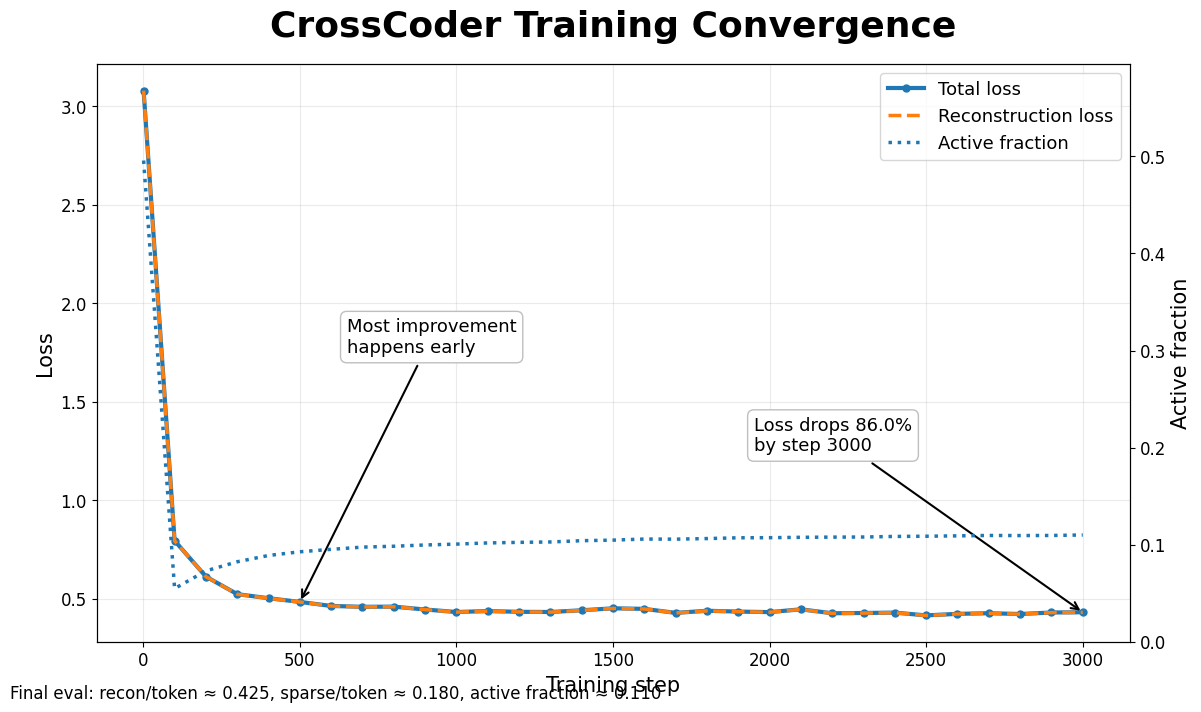

Saved PNG: /content/presentation_assets/crosscoder_training_convergence.png
Saved SVG: /content/presentation_assets/crosscoder_training_convergence.svg
Copied to gs://data-intelligence-bucket/tests/


In [212]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess

log_text = """
step=0001 loss=3.08033 recon=3.07937 sparse=0.32027 active_frac=0.4958 elapsed=0.3s
step=0100 loss=0.79406 recon=0.79375 sparse=0.10065 active_frac=0.0548 elapsed=4.3s
step=0200 loss=0.61185 recon=0.61142 sparse=0.14444 active_frac=0.0730 elapsed=8.3s
step=0300 loss=0.52283 recon=0.52234 sparse=0.16460 active_frac=0.0824 elapsed=12.3s
step=0400 loss=0.50203 recon=0.50150 sparse=0.17545 active_frac=0.0889 elapsed=16.3s
step=0500 loss=0.48316 recon=0.48261 sparse=0.18133 active_frac=0.0927 elapsed=20.3s
step=0600 loss=0.46283 recon=0.46228 sparse=0.18277 active_frac=0.0952 elapsed=24.4s
step=0700 loss=0.45846 recon=0.45790 sparse=0.18795 active_frac=0.0975 elapsed=28.4s
step=0800 loss=0.45932 recon=0.45876 sparse=0.18725 active_frac=0.0984 elapsed=32.4s
step=0900 loss=0.44475 recon=0.44419 sparse=0.18692 active_frac=0.0997 elapsed=36.4s
step=1000 loss=0.43201 recon=0.43145 sparse=0.18637 active_frac=0.1006 elapsed=40.4s
step=1100 loss=0.43686 recon=0.43630 sparse=0.18514 active_frac=0.1018 elapsed=44.4s
step=1200 loss=0.43301 recon=0.43245 sparse=0.18775 active_frac=0.1024 elapsed=48.4s
step=1300 loss=0.43203 recon=0.43148 sparse=0.18570 active_frac=0.1028 elapsed=52.4s
step=1400 loss=0.44086 recon=0.44029 sparse=0.18934 active_frac=0.1041 elapsed=56.4s
step=1500 loss=0.45078 recon=0.45022 sparse=0.18725 active_frac=0.1047 elapsed=60.4s
step=1600 loss=0.44802 recon=0.44746 sparse=0.18756 active_frac=0.1058 elapsed=64.4s
step=1700 loss=0.42757 recon=0.42702 sparse=0.18410 active_frac=0.1057 elapsed=68.4s
step=1800 loss=0.43834 recon=0.43778 sparse=0.18486 active_frac=0.1063 elapsed=72.4s
step=1900 loss=0.43420 recon=0.43364 sparse=0.18666 active_frac=0.1071 elapsed=76.4s
step=2000 loss=0.43148 recon=0.43093 sparse=0.18338 active_frac=0.1072 elapsed=80.5s
step=2100 loss=0.44568 recon=0.44513 sparse=0.18528 active_frac=0.1076 elapsed=84.5s
step=2200 loss=0.42567 recon=0.42512 sparse=0.18347 active_frac=0.1078 elapsed=88.4s
step=2300 loss=0.42705 recon=0.42650 sparse=0.18405 active_frac=0.1079 elapsed=92.4s
step=2400 loss=0.42899 recon=0.42845 sparse=0.18284 active_frac=0.1085 elapsed=96.4s
step=2500 loss=0.41485 recon=0.41431 sparse=0.18083 active_frac=0.1087 elapsed=100.4s
step=2600 loss=0.42264 recon=0.42209 sparse=0.18115 active_frac=0.1091 elapsed=104.4s
step=2700 loss=0.42586 recon=0.42531 sparse=0.18294 active_frac=0.1095 elapsed=108.4s
step=2800 loss=0.42185 recon=0.42131 sparse=0.17882 active_frac=0.1094 elapsed=112.4s
step=2900 loss=0.42957 recon=0.42903 sparse=0.18161 active_frac=0.1095 elapsed=116.4s
step=3000 loss=0.43070 recon=0.43016 sparse=0.18126 active_frac=0.1100 elapsed=120.4s
"""

rows = []
pattern = re.compile(
    r"step=(\d+)\s+loss=([\d.]+)\s+recon=([\d.]+)\s+sparse=([\d.]+)\s+active_frac=([\d.]+)\s+elapsed=([\d.]+)s"
)

for line in log_text.strip().splitlines():
    m = pattern.search(line)
    if m:
        rows.append({
            "step": int(m.group(1)),
            "loss": float(m.group(2)),
            "recon": float(m.group(3)),
            "sparse": float(m.group(4)),
            "active_frac": float(m.group(5)),
            "elapsed": float(m.group(6)),
        })

df_conv = pd.DataFrame(rows)

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

# --- Slide-style plot ---
fig, ax1 = plt.subplots(figsize=(13.33, 7.5))

ax1.plot(df_conv["step"], df_conv["loss"], linewidth=3, marker="o", markersize=5, label="Total loss")
ax1.plot(df_conv["step"], df_conv["recon"], linewidth=2.5, linestyle="--", label="Reconstruction loss")

ax1.set_title("CrossCoder Training Convergence", fontsize=26, fontweight="bold", pad=20)
ax1.set_xlabel("Training step", fontsize=15)
ax1.set_ylabel("Loss", fontsize=15)
ax1.tick_params(axis="both", labelsize=12)
ax1.grid(True, alpha=0.25)

# second axis for active fraction
ax2 = ax1.twinx()
ax2.plot(df_conv["step"], df_conv["active_frac"], linewidth=2.5, linestyle=":", label="Active fraction")
ax2.set_ylabel("Active fraction", fontsize=15)
ax2.tick_params(axis="y", labelsize=12)
ax2.set_ylim(0, max(df_conv["active_frac"]) * 1.2)

# annotations
initial_loss = df_conv.iloc[0]["loss"]
final_loss = df_conv.iloc[-1]["loss"]
reduction = 100 * (1 - final_loss / initial_loss)

ax1.annotate(
    f"Loss drops {reduction:.1f}%\nby step 3000",
    xy=(df_conv.iloc[-1]["step"], final_loss),
    xytext=(1950, 1.25),
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.75")
)

ax1.annotate(
    "Most improvement\nhappens early",
    xy=(500, df_conv[df_conv["step"].eq(500)]["loss"].iloc[0]),
    xytext=(650, 1.75),
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.75")
)

# combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", fontsize=13, frameon=True)

# footer note
fig.text(
    0.06, 0.035,
    "Final eval: recon/token ≈ 0.425, sparse/token ≈ 0.180, active fraction ≈ 0.110",
    fontsize=12
)

png_path = OUT_DIR / "crosscoder_training_convergence.png"
svg_path = OUT_DIR / "crosscoder_training_convergence.svg"

fig.savefig(png_path, dpi=220, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")
plt.show()

print("Saved PNG:", png_path)
print("Saved SVG:", svg_path)

# Optional: copy to GCS
try:
    subprocess.run(["gsutil", "cp", str(png_path), "gs://data-intelligence-bucket/tests/"], check=True)
    subprocess.run(["gsutil", "cp", str(svg_path), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)

In [ ]:
@torch.no_grad()
def evaluate_crosscoder(cc_model, X_base_t, X_merged_t, batch_size=1024):
    cc_model.eval()

    total_recon = 0.0
    total_sparse = 0.0
    total_active = 0.0
    total_n = 0

    for start in range(0, X_base_t.shape[0], batch_size):
        end = min(start + batch_size, X_base_t.shape[0])

        xb = X_base_t[start:end].to(device)
        xm = X_merged_t[start:end].to(device)

        xhat_b, xhat_m, z = cc_model(xb, xm)

        recon = (
            ((xhat_b - xb) ** 2).mean(dim=1)
            + ((xhat_m - xm) ** 2).mean(dim=1)
        )

        total_recon += recon.sum().item()
        total_sparse += z.abs().mean(dim=1).sum().item()
        total_active += (z > 0).float().mean(dim=1).sum().item()
        total_n += end - start

    return {
        "recon_per_token": total_recon / total_n,
        "sparse_per_token": total_sparse / total_n,
        "active_frac": total_active / total_n,
    }

eval_metrics = evaluate_crosscoder(cc_model, X_base_t, X_merged_t)
print(eval_metrics)

CC_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": cc_model.state_dict(),
        "d_model": d_model,
        "d_hidden": d_hidden,
        "layer_id": LAYER_ID,
        "base_model": BASE_MODEL,
        "merged_model": MERGED_MODEL,
        "eval_metrics": eval_metrics,
        "lambda_l1": lambda_l1,
        "objective": "correctness_gain",
    },
    CC_DIR / "crosscoder_correctness_v3.pt",
)

with open(CC_DIR / "loss_history_correctness_v3.json", "w") as f:
    json.dump(loss_history, f, indent=2)

with open(CC_DIR / "eval_metrics_correctness_v3.json", "w") as f:
    json.dump(eval_metrics, f, indent=2)

{'recon_per_token': 0.42465837045502003, 'sparse_per_token': 0.18005239389871028, 'active_frac': 0.10979625896759944}


In [ ]:
@torch.no_grad()
def collect_feature_activations(cc_model, X_base_t, X_merged_t, batch_size=1024):
    cc_model.eval()
    all_z = []

    for start in range(0, X_base_t.shape[0], batch_size):
        end = min(start + batch_size, X_base_t.shape[0])

        xb = X_base_t[start:end].to(device)
        xm = X_merged_t[start:end].to(device)

        z = cc_model.encode(xb, xm)
        all_z.append(z.detach().cpu())

    return torch.cat(all_z, dim=0).numpy()


Z = collect_feature_activations(cc_model, X_base_t, X_merged_t)

print("Z:", Z.shape)
print("Z mean:", Z.mean())
print("Z active fraction:", (Z > 0).mean())

Z: (18931, 4096)
Z mean: 0.18005252
Z active fraction: 0.10979625896759944


In [ ]:
token_task_label_full = []
token_source_model_full = []
token_source_correct_full = []
token_base_correct_full = []
token_merged_correct_full = []
token_task_id_full = []
token_text_id_full = []

for item in paired_index:
    n = item["num_tokens"]

    token_task_label_full.extend([item["task_label"]] * n)
    token_source_model_full.extend([item["source_model"]] * n)
    token_source_correct_full.extend([item["source_correct"]] * n)
    token_base_correct_full.extend([item["base_correct"]] * n)
    token_merged_correct_full.extend([item["merged_correct"]] * n)
    token_task_id_full.extend([item["task_id"]] * n)
    token_text_id_full.extend([item["text_id"]] * n)

token_task_label_full = np.array(token_task_label_full, dtype=object)
token_source_model_full = np.array(token_source_model_full, dtype=object)
token_source_correct_full = np.array(token_source_correct_full, dtype=bool)
token_base_correct_full = np.array(token_base_correct_full, dtype=bool)
token_merged_correct_full = np.array(token_merged_correct_full, dtype=bool)
token_task_id_full = np.array(token_task_id_full, dtype=object)
token_text_id_full = np.array(token_text_id_full)

print("Full token metadata:", len(token_task_label_full))
print("Mask length:", len(mask))
print("Z rows:", Z.shape[0])

token_task_label = token_task_label_full[mask]
token_source_model = token_source_model_full[mask]
token_source_correct = token_source_correct_full[mask]
token_base_correct = token_base_correct_full[mask]
token_merged_correct = token_merged_correct_full[mask]
token_task_id = token_task_id_full[mask]
token_text_id = token_text_id_full[mask]

assert len(token_task_label) == Z.shape[0]

print(pd.Series(token_task_label).value_counts())
print(pd.Series(token_source_model).value_counts())

Full token metadata: 18999
Mask length: 18999
Z rows: 18931
both_correct           6284
merged_only_correct    6240
both_incorrect         6102
base_only_correct       305
Name: count, dtype: int64
merged    9991
base      8940
Name: count, dtype: int64


In [ ]:
with torch.no_grad():
    W_base = cc_model.decoder_base.weight.detach().cpu().numpy().T
    W_merged = cc_model.decoder_merged.weight.detach().cpu().numpy().T

print("W_base:", W_base.shape)
print("W_merged:", W_merged.shape)

base_norm = np.linalg.norm(W_base, axis=1)
merged_norm = np.linalg.norm(W_merged, axis=1)

total_norm = base_norm + merged_norm + 1e-8
merged_score = merged_norm / total_norm
base_score = base_norm / total_norm

print("merged_score range:", merged_score.min(), merged_score.max())
print("base_score range:", base_score.min(), base_score.max())

W_base: (4096, 4096)
W_merged: (4096, 4096)
merged_score range: 0.22662325 0.7481455
base_score range: 0.25185448 0.7733767


In [ ]:
merged_output_mask = token_source_model == "merged"

merged_only_correct_mask = (
    merged_output_mask &
    (token_task_label == "merged_only_correct")
)

other_merged_mask = (
    merged_output_mask &
    (token_task_label != "merged_only_correct")
)

print("Merged output tokens:", int(merged_output_mask.sum()))
print("Merged-only-correct tokens:", int(merged_only_correct_mask.sum()))
print("Other merged tokens:", int(other_merged_mask.sum()))

feature_rows = []

for j in range(d_hidden):
    z_j = Z[:, j]

    global_mean = float(z_j.mean())
    global_active_frac = float((z_j > 0).mean())

    merged_mean = float(z_j[merged_output_mask].mean()) if merged_output_mask.sum() else 0.0
    merged_active_frac = float((z_j[merged_output_mask] > 0).mean()) if merged_output_mask.sum() else 0.0

    pos_mean = float(z_j[merged_only_correct_mask].mean()) if merged_only_correct_mask.sum() else 0.0
    neg_mean = float(z_j[other_merged_mask].mean()) if other_merged_mask.sum() else 0.0

    pos_active_frac = (
        float((z_j[merged_only_correct_mask] > 0).mean())
        if merged_only_correct_mask.sum()
        else 0.0
    )

    neg_active_frac = (
        float((z_j[other_merged_mask] > 0).mean())
        if other_merged_mask.sum()
        else 0.0
    )

    correctness_diff = pos_mean - neg_mean
    correctness_active_diff = pos_active_frac - neg_active_frac

    correctness_gain_score = (
        float(merged_score[j] - 0.5)
        * float(total_norm[j])
        * float(correctness_diff)
    )

    feature_rows.append({
        "feature": int(j),
        "base_norm": float(base_norm[j]),
        "merged_norm": float(merged_norm[j]),
        "total_norm": float(total_norm[j]),
        "base_score": float(base_score[j]),
        "merged_score": float(merged_score[j]),
        "global_mean": global_mean,
        "global_active_frac": global_active_frac,
        "merged_mean": merged_mean,
        "merged_active_frac": merged_active_frac,
        "merged_only_correct_mean": pos_mean,
        "other_merged_mean": neg_mean,
        "correctness_diff": float(correctness_diff),
        "merged_only_correct_active_frac": pos_active_frac,
        "other_merged_active_frac": neg_active_frac,
        "correctness_active_diff": float(correctness_active_diff),
        "correctness_gain_score": float(correctness_gain_score),
    })

df_features = pd.DataFrame(feature_rows)

df_top_correctness = (
    df_features
    .sort_values("correctness_gain_score", ascending=False)
    .head(50)
)

display(df_top_correctness)

df_features.to_csv(CC_DIR / "feature_correctness_scores_v3.csv", index=False)
df_top_correctness.to_csv(CC_DIR / "top_correctness_candidate_features_v3.csv", index=False)

Merged output tokens: 9991
Merged-only-correct tokens: 3395
Other merged tokens: 6596


,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,merged_only_correct_mean,other_merged_mean,correctness_diff,merged_only_correct_active_frac,other_merged_active_frac,correctness_active_diff,correctness_gain_score
1323,1323,2.181551,0.639262,2.820813,0.773377,0.226623,0.191388,0.015794,0.186291,0.014613,0.129589,0.215476,-0.085887,0.011487,0.016222,-0.004734,0.066231
2673,2673,1.703638,0.962338,2.665976,0.639030,0.360970,0.282507,0.118483,0.245199,0.110600,0.194522,0.271282,-0.076760,0.100442,0.115828,-0.015386,0.028451
1962,1962,2.001312,1.221670,3.222982,0.620950,0.379050,0.320095,0.132851,0.319291,0.127214,0.284917,0.336984,-0.052066,0.124300,0.128714,-0.004414,0.020297
165,165,1.615107,1.696584,3.311691,0.487699,0.512301,1.802555,0.943585,1.904559,0.955960,2.219241,1.742591,0.476650,0.965832,0.950879,0.014953,0.019418
1477,1477,1.468110,1.560784,3.028895,0.484702,0.515298,1.719485,0.947916,1.751521,0.950555,1.997301,1.625017,0.372284,0.966716,0.942238,0.024478,0.017251
2648,2648,1.590848,1.698883,3.289731,0.483580,0.516420,1.768996,0.938778,1.802765,0.941647,2.011467,1.695344,0.316123,0.954345,0.935112,0.019232,0.017076
1907,1907,1.659202,1.758191,3.417393,0.485517,0.514483,1.765634,0.935397,1.946014,0.952257,2.161298,1.835206,0.326091,0.959647,0.948454,0.011193,0.016140
3807,3807,1.584416,1.685282,3.269698,0.484576,0.515424,1.425218,0.941208,1.464371,0.945351,1.673347,1.356809,0.316537,0.955817,0.939964,0.015854,0.015964
1639,1639,1.604855,1.244459,2.849314,0.563242,0.436758,0.168400,0.051503,0.149653,0.047343,0.091557,0.179555,-0.087998,0.037113,0.052608,-0.015494,0.015857
690,690,1.520368,1.598289,3.118658,0.487507,0.512493,1.907127,0.945275,1.971691,0.952958,2.228097,1.839718,0.388380,0.971134,0.943602,0.027532,0.015131


In [ ]:
print("Top by merged_score:")
display(
    df_features
    .sort_values("merged_score", ascending=False)
    .head(20)
)

print("Top by correctness_diff:")
display(
    df_features
    .sort_values("correctness_diff", ascending=False)
    .head(20)
)

print("Top by correctness_active_diff:")
display(
    df_features
    .sort_values("correctness_active_diff", ascending=False)
    .head(20)
)

print("Top by total_norm among merged-specific features:")
display(
    df_features[df_features["merged_score"] > 0.55]
    .sort_values("total_norm", ascending=False)
    .head(20)
)

Top by merged_score:


,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,merged_only_correct_mean,other_merged_mean,correctness_diff,merged_only_correct_active_frac,other_merged_active_frac,correctness_active_diff,correctness_gain_score
1797,1797,0.765576,2.274179,3.039754,0.251854,0.748146,0.260966,0.022291,0.241172,0.020719,0.185384,0.269886,-0.084501,0.018851,0.021680,-0.002829,-0.063740
845,845,0.878443,1.473823,2.352266,0.373445,0.626555,0.546831,0.529660,0.532375,0.547393,0.455111,0.572143,-0.117032,0.525479,0.558672,-0.033193,-0.034839
2507,2507,0.844291,1.401992,2.246282,0.375861,0.624139,0.009770,0.000264,0.007455,0.000200,0.000000,0.011292,-0.011292,0.000000,0.000303,-0.000303,-0.003149
3923,3923,1.201544,1.714160,2.915704,0.412094,0.587906,0.135589,0.042576,0.124367,0.040336,0.084303,0.144988,-0.060686,0.030633,0.045331,-0.014697,-0.015554
2819,2819,1.691443,2.087361,3.778804,0.447613,0.552387,0.166527,0.015900,0.172678,0.015714,0.183045,0.167342,0.015703,0.015611,0.015767,-0.000156,0.003109
830,830,1.047587,1.284366,2.331953,0.449232,0.550769,0.035357,0.004015,0.002748,0.001001,0.005643,0.001259,0.004385,0.001767,0.000606,0.001161,0.000519
1875,1875,0.996999,1.222228,2.219227,0.449255,0.550745,0.026838,0.002588,0.042588,0.003803,0.075233,0.025785,0.049448,0.006186,0.002577,0.003608,0.005569
124,124,1.238424,1.400457,2.638881,0.469299,0.530701,0.061208,0.007659,0.058176,0.006806,0.168080,0.001608,0.166472,0.017673,0.001213,0.016460,0.013487
527,527,1.443184,1.628516,3.071699,0.469832,0.530168,0.902451,0.877397,0.941015,0.875088,0.987885,0.916890,0.070994,0.879234,0.872953,0.006281,0.006579
1492,1492,1.655314,1.861216,3.516530,0.470724,0.529276,0.119158,0.017907,0.120821,0.019217,0.113313,0.124685,-0.011372,0.019146,0.019254,-0.000108,-0.001171


Top by correctness_diff:


,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,merged_only_correct_mean,other_merged_mean,correctness_diff,merged_only_correct_active_frac,other_merged_active_frac,correctness_active_diff,correctness_gain_score
165,165,1.615107,1.696584,3.311691,0.487699,0.512301,1.802555,0.943585,1.904559,0.955960,2.219241,1.742591,0.476650,0.965832,0.950879,0.014953,0.019418
2826,2826,1.624142,1.694251,3.318393,0.489436,0.510564,1.986312,0.954519,2.061795,0.957061,2.325281,1.926176,0.399105,0.972901,0.948908,0.023993,0.013991
690,690,1.520368,1.598289,3.118658,0.487507,0.512493,1.907127,0.945275,1.971691,0.952958,2.228097,1.839718,0.388380,0.971134,0.943602,0.027532,0.015131
1477,1477,1.468110,1.560784,3.028895,0.484702,0.515298,1.719485,0.947916,1.751521,0.950555,1.997301,1.625017,0.372284,0.966716,0.942238,0.024478,0.017251
2924,2924,1.596014,1.669349,3.265363,0.488771,0.511229,1.804435,0.936770,1.770756,0.930738,1.999425,1.653058,0.346367,0.936966,0.927532,0.009434,0.012700
1907,1907,1.659202,1.758191,3.417393,0.485517,0.514483,1.765634,0.935397,1.946014,0.952257,2.161298,1.835206,0.326091,0.959647,0.948454,0.011193,0.016140
874,874,1.574428,1.657887,3.232316,0.487090,0.512910,1.806953,0.948920,1.820819,0.953358,2.034595,1.710787,0.323808,0.969072,0.945270,0.023802,0.013512
3807,3807,1.584416,1.685282,3.269698,0.484576,0.515424,1.425218,0.941208,1.464371,0.945351,1.673347,1.356809,0.316537,0.955817,0.939964,0.015854,0.015964
2648,2648,1.590848,1.698883,3.289731,0.483580,0.516420,1.768996,0.938778,1.802765,0.941647,2.011467,1.695344,0.316123,0.954345,0.935112,0.019232,0.017076
985,985,1.458635,1.547686,3.006320,0.485189,0.514811,1.705565,0.946807,1.788718,0.952657,1.995656,1.682207,0.313450,0.962887,0.947392,0.015494,0.013956


Top by correctness_active_diff:


,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,merged_only_correct_mean,other_merged_mean,correctness_diff,merged_only_correct_active_frac,other_merged_active_frac,correctness_active_diff,correctness_gain_score
76,76,1.324006,1.340015,2.664021,0.496995,0.503004,0.112402,0.027363,0.101830,0.025823,0.241667,0.029856,0.211811,0.053608,0.011522,0.042086,0.001695
1341,1341,1.422947,1.515072,2.938019,0.484322,0.515678,0.972788,0.901167,1.025022,0.908217,1.008323,1.033618,-0.025295,0.927246,0.898423,0.028823,-0.001165
690,690,1.520368,1.598289,3.118658,0.487507,0.512493,1.907127,0.945275,1.971691,0.952958,2.228097,1.839718,0.388380,0.971134,0.943602,0.027532,0.015131
1015,1015,1.700507,1.583667,3.284173,0.517788,0.482212,1.174047,0.928424,1.208417,0.936143,1.264517,1.179542,0.084975,0.952577,0.927683,0.024894,-0.004964
1477,1477,1.468110,1.560784,3.028895,0.484702,0.515298,1.719485,0.947916,1.751521,0.950555,1.997301,1.625017,0.372284,0.966716,0.942238,0.024478,0.017251
3203,3203,1.293507,1.296757,2.590265,0.499373,0.500627,0.902145,0.818657,0.778293,0.822240,0.804746,0.764677,0.040068,0.838292,0.813978,0.024313,0.000065
2826,2826,1.624142,1.694251,3.318393,0.489436,0.510564,1.986312,0.954519,2.061795,0.957061,2.325281,1.926176,0.399105,0.972901,0.948908,0.023993,0.013991
874,874,1.574428,1.657887,3.232316,0.487090,0.512910,1.806953,0.948920,1.820819,0.953358,2.034595,1.710787,0.323808,0.969072,0.945270,0.023802,0.013512
3422,3422,1.374797,1.451181,2.825978,0.486485,0.513515,1.924258,0.952987,2.010869,0.955460,2.207844,1.909484,0.298360,0.970839,0.947544,0.023296,0.011395
505,505,1.212925,1.262252,2.475177,0.490036,0.509964,0.097022,0.028630,0.092972,0.029126,0.157855,0.059576,0.098279,0.043594,0.021680,0.021914,0.002424


Top by total_norm among merged-specific features:


,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,merged_only_correct_mean,other_merged_mean,correctness_diff,merged_only_correct_active_frac,other_merged_active_frac,correctness_active_diff,correctness_gain_score
2819,2819,1.691443,2.087361,3.778804,0.447613,0.552387,0.166527,0.015900,0.172678,0.015714,0.183045,0.167342,0.015703,0.015611,0.015767,-0.000156,0.003109
1797,1797,0.765576,2.274179,3.039754,0.251854,0.748146,0.260966,0.022291,0.241172,0.020719,0.185384,0.269886,-0.084501,0.018851,0.021680,-0.002829,-0.063740
3923,3923,1.201544,1.714160,2.915704,0.412094,0.587906,0.135589,0.042576,0.124367,0.040336,0.084303,0.144988,-0.060686,0.030633,0.045331,-0.014697,-0.015554
845,845,0.878443,1.473823,2.352266,0.373445,0.626555,0.546831,0.529660,0.532375,0.547393,0.455111,0.572143,-0.117032,0.525479,0.558672,-0.033193,-0.034839
830,830,1.047587,1.284366,2.331953,0.449232,0.550769,0.035357,0.004015,0.002748,0.001001,0.005643,0.001259,0.004385,0.001767,0.000606,0.001161,0.000519
2507,2507,0.844291,1.401992,2.246282,0.375861,0.624139,0.009770,0.000264,0.007455,0.000200,0.000000,0.011292,-0.011292,0.000000,0.000303,-0.000303,-0.003149
1875,1875,0.996999,1.222228,2.219227,0.449255,0.550745,0.026838,0.002588,0.042588,0.003803,0.075233,0.025785,0.049448,0.006186,0.002577,0.003608,0.005569


In [ ]:
df_features.sort_values("correctness_diff", ascending=False).head(10)

,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,merged_only_correct_mean,other_merged_mean,correctness_diff,merged_only_correct_active_frac,other_merged_active_frac,correctness_active_diff,correctness_gain_score
165,165,1.615107,1.696584,3.311691,0.487699,0.512301,1.802555,0.943585,1.904559,0.955960,2.219241,1.742591,0.476650,0.965832,0.950879,0.014953,0.019418
2826,2826,1.624142,1.694251,3.318393,0.489436,0.510564,1.986312,0.954519,2.061795,0.957061,2.325281,1.926176,0.399105,0.972901,0.948908,0.023993,0.013991
690,690,1.520368,1.598289,3.118658,0.487507,0.512493,1.907127,0.945275,1.971691,0.952958,2.228097,1.839718,0.388380,0.971134,0.943602,0.027532,0.015131
1477,1477,1.468110,1.560784,3.028895,0.484702,0.515298,1.719485,0.947916,1.751521,0.950555,1.997301,1.625017,0.372284,0.966716,0.942238,0.024478,0.017251
2924,2924,1.596014,1.669349,3.265363,0.488771,0.511229,1.804435,0.936770,1.770756,0.930738,1.999425,1.653058,0.346367,0.936966,0.927532,0.009434,0.012700
1907,1907,1.659202,1.758191,3.417393,0.485517,0.514483,1.765634,0.935397,1.946014,0.952257,2.161298,1.835206,0.326091,0.959647,0.948454,0.011193,0.016140
874,874,1.574428,1.657887,3.232316,0.487090,0.512910,1.806953,0.948920,1.820819,0.953358,2.034595,1.710787,0.323808,0.969072,0.945270,0.023802,0.013512
3807,3807,1.584416,1.685282,3.269698,0.484576,0.515424,1.425218,0.941208,1.464371,0.945351,1.673347,1.356809,0.316537,0.955817,0.939964,0.015854,0.015964
2648,2648,1.590848,1.698883,3.289731,0.483580,0.516420,1.768996,0.938778,1.802765,0.941647,2.011467,1.695344,0.316123,0.954345,0.935112,0.019232,0.017076
985,985,1.458635,1.547686,3.006320,0.485189,0.514811,1.705565,0.946807,1.788718,0.952657,1.995656,1.682207,0.313450,0.962887,0.947392,0.015494,0.013956


In [ ]:
df_helpful_merged = df_features[
    (df_features["merged_score"] > 0.5) &
    (df_features["correctness_diff"] > 0)
].copy()

df_helpful_merged["score"] = (
    (df_helpful_merged["merged_score"] - 0.5)
    * df_helpful_merged["total_norm"]
    * df_helpful_merged["correctness_diff"]
)

df_helpful_merged = df_helpful_merged.sort_values("score", ascending=False)

display(df_helpful_merged.head(20))

,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,merged_only_correct_mean,other_merged_mean,correctness_diff,merged_only_correct_active_frac,other_merged_active_frac,correctness_active_diff,correctness_gain_score,score
165,165,1.615107,1.696584,3.311691,0.487699,0.512301,1.802555,0.943585,1.904559,0.955960,2.219241,1.742591,0.476650,0.965832,0.950879,0.014953,0.019418,0.019418
1477,1477,1.468110,1.560784,3.028895,0.484702,0.515298,1.719485,0.947916,1.751521,0.950555,1.997301,1.625017,0.372284,0.966716,0.942238,0.024478,0.017251,0.017251
2648,2648,1.590848,1.698883,3.289731,0.483580,0.516420,1.768996,0.938778,1.802765,0.941647,2.011467,1.695344,0.316123,0.954345,0.935112,0.019232,0.017076,0.017076
1907,1907,1.659202,1.758191,3.417393,0.485517,0.514483,1.765634,0.935397,1.946014,0.952257,2.161298,1.835206,0.326091,0.959647,0.948454,0.011193,0.016140,0.016140
3807,3807,1.584416,1.685282,3.269698,0.484576,0.515424,1.425218,0.941208,1.464371,0.945351,1.673347,1.356809,0.316537,0.955817,0.939964,0.015854,0.015964,0.015964
690,690,1.520368,1.598289,3.118658,0.487507,0.512493,1.907127,0.945275,1.971691,0.952958,2.228097,1.839718,0.388380,0.971134,0.943602,0.027532,0.015131,0.015131
2826,2826,1.624142,1.694251,3.318393,0.489436,0.510564,1.986312,0.954519,2.061795,0.957061,2.325281,1.926176,0.399105,0.972901,0.948908,0.023993,0.013991,0.013991
985,985,1.458635,1.547686,3.006320,0.485189,0.514811,1.705565,0.946807,1.788718,0.952657,1.995656,1.682207,0.313450,0.962887,0.947392,0.015494,0.013956,0.013956
874,874,1.574428,1.657887,3.232316,0.487090,0.512910,1.806953,0.948920,1.820819,0.953358,2.034595,1.710787,0.323808,0.969072,0.945270,0.023802,0.013512,0.013512
124,124,1.238424,1.400457,2.638881,0.469299,0.530701,0.061208,0.007659,0.058176,0.006806,0.168080,0.001608,0.166472,0.017673,0.001213,0.016460,0.013487,0.013487


In [ ]:
df_harmful_base = df_features[
    (df_features["merged_score"] < 0.5) &
    (df_features["correctness_diff"] < 0)
].copy()

df_harmful_base["score"] = (
    (0.5 - df_harmful_base["merged_score"])
    * df_harmful_base["total_norm"]
    * (-df_harmful_base["correctness_diff"])
)

df_harmful_base = df_harmful_base.sort_values("score", ascending=False)

display(df_harmful_base.head(20))

,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,merged_only_correct_mean,other_merged_mean,correctness_diff,merged_only_correct_active_frac,other_merged_active_frac,correctness_active_diff,correctness_gain_score,score
1323,1323,2.181551,0.639262,2.820813,0.773377,0.226623,0.191388,0.015794,0.186291,0.014613,0.129589,0.215476,-0.085887,0.011487,0.016222,-0.004734,0.066231,0.066231
2673,2673,1.703638,0.962338,2.665976,0.639030,0.360970,0.282507,0.118483,0.245199,0.110600,0.194522,0.271282,-0.076760,0.100442,0.115828,-0.015386,0.028451,0.028451
1962,1962,2.001312,1.221670,3.222982,0.620950,0.379050,0.320095,0.132851,0.319291,0.127214,0.284917,0.336984,-0.052066,0.124300,0.128714,-0.004414,0.020297,0.020297
1639,1639,1.604855,1.244459,2.849314,0.563242,0.436758,0.168400,0.051503,0.149653,0.047343,0.091557,0.179555,-0.087998,0.037113,0.052608,-0.015494,0.015857,0.015857
421,421,1.568511,0.951061,2.519572,0.622531,0.377469,0.146036,0.044741,0.145961,0.044540,0.121249,0.158680,-0.037431,0.037703,0.048059,-0.010357,0.011556,0.011556
2934,2934,1.378256,0.948597,2.326853,0.592326,0.407674,0.074520,0.017696,0.074023,0.017416,0.053063,0.084812,-0.031749,0.014728,0.018799,-0.004072,0.006821,0.006821
810,810,1.405970,1.370517,2.776487,0.506384,0.493616,0.094806,0.013787,0.175714,0.023922,0.000384,0.265958,-0.265573,0.000295,0.036082,-0.035788,0.004708,0.004708
3707,3707,1.883405,1.148243,3.031647,0.621248,0.378752,0.093802,0.022291,0.093082,0.022720,0.085219,0.097130,-0.011911,0.022091,0.023044,-0.000953,0.004378,0.004378
615,615,1.392973,1.366851,2.759823,0.504733,0.495267,0.038342,0.003803,0.066182,0.006005,0.000000,0.100247,-0.100247,0.000000,0.009096,-0.009096,0.001309,0.001309
549,549,1.610402,1.582950,3.193352,0.504298,0.495702,1.098427,0.907718,1.100175,0.911620,1.045917,1.128102,-0.082185,0.913991,0.910400,0.003591,0.001128,0.001128


NameError: name 'show_top_examples_for_feature' is not defined

In [ ]:
# Build per-text feature summaries.
# Token-level statistics can be misleading because long outputs contribute more tokens.
# This cell aggregates feature activations per generated solution text.

text_rows = []

for item in paired_index:
    start = item["global_start"]
    end = item["global_end"]

    # Map full token indices to filtered indices after outlier removal.
    full_indices = np.arange(start, end)
    keep = mask[start:end]

    if keep.sum() == 0:
        continue

    # Z is already filtered, so we need filtered positions.
    # filtered_to_full maps filtered index -> full index.
    # Build reverse mapping once if not already present.
    text_rows.append({
        "text_id": item["text_id"],
        "task_id": item["task_id"],
        "task_idx": item["task_idx"],
        "source_model": item["source_model"],
        "task_label": item["task_label"],
        "source_correct": item["source_correct"],
        "base_correct": item["base_correct"],
        "merged_correct": item["merged_correct"],
        "global_start": item["global_start"],
        "global_end": item["global_end"],
        "num_tokens": item["num_tokens"],
    })

df_texts = pd.DataFrame(text_rows)

print("Texts:", len(df_texts))
display(df_texts.head())
display(df_texts[["source_model", "task_label", "source_correct"]].value_counts().reset_index(name="count"))

Texts: 328


,text_id,task_id,task_idx,source_model,task_label,source_correct,base_correct,merged_correct,global_start,global_end,num_tokens
0,0,HumanEval/0,0,base,both_correct,True,True,True,0,47,47
1,1,HumanEval/1,1,base,both_incorrect,False,False,False,47,58,11
2,2,HumanEval/2,2,base,both_correct,True,True,True,58,65,7
3,3,HumanEval/3,3,base,both_correct,True,True,True,65,97,32
4,4,HumanEval/4,4,base,both_correct,True,True,True,97,134,37


,source_model,task_label,source_correct,count
0,base,both_correct,True,64
1,merged,both_correct,True,64
2,merged,merged_only_correct,True,54
3,base,merged_only_correct,False,54
4,merged,both_incorrect,False,43
5,base,both_incorrect,False,43
6,base,base_only_correct,True,3
7,merged,base_only_correct,False,3


In [ ]:
# Create mappings between full token indices and filtered Z indices.

filtered_to_full = np.where(mask)[0]
full_to_filtered = {int(full_idx): int(filtered_idx) for filtered_idx, full_idx in enumerate(filtered_to_full)}

def get_filtered_indices_for_text(item):
    full_indices = range(item["global_start"], item["global_end"])
    return np.array(
        [full_to_filtered[i] for i in full_indices if i in full_to_filtered],
        dtype=np.int64,
    )

# Quick sanity check.
example_item = paired_index[0]
idxs = get_filtered_indices_for_text(example_item)
print("Example filtered token count:", len(idxs))
print("Z rows:", Z.shape[0])

Example filtered token count: 47
Z rows: 18931


In [ ]:
def aggregate_feature_by_text(feature_id):
    rows = []

    for item in paired_index:
        idxs = get_filtered_indices_for_text(item)

        if len(idxs) == 0:
            continue

        vals = Z[idxs, feature_id]

        rows.append({
            "feature": int(feature_id),
            "text_id": item["text_id"],
            "task_id": item["task_id"],
            "task_idx": item["task_idx"],
            "source_model": item["source_model"],
            "task_label": item["task_label"],
            "source_correct": bool(item["source_correct"]),
            "base_correct": bool(item["base_correct"]),
            "merged_correct": bool(item["merged_correct"]),
            "num_tokens": int(len(vals)),
            "mean_activation": float(vals.mean()),
            "max_activation": float(vals.max()),
            "sum_activation": float(vals.sum()),
            "active_frac": float((vals > 0).mean()),
            "p95_activation": float(np.percentile(vals, 95)),
            "p99_activation": float(np.percentile(vals, 99)),
        })

    return pd.DataFrame(rows)

In [ ]:
from scipy.stats import pointbiserialr, spearmanr
from sklearn.metrics import roc_auc_score

def safe_auc(y_true, scores):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(roc_auc_score(y_true, scores))


def summarize_feature_error_correlation(feature_id):
    df_feat = aggregate_feature_by_text(feature_id)

    rows = []

    for source in ["base", "merged"]:
        d = df_feat[df_feat["source_model"] == source].copy()

        if len(d) == 0:
            continue

        # Error label: 1 = generated solution failed tests.
        y_error = (~d["source_correct"]).astype(int).values

        for score_col in ["mean_activation", "max_activation", "p95_activation", "p99_activation", "active_frac"]:
            scores = d[score_col].values.astype(float)

            auc_error = safe_auc(y_error, scores)

            try:
                corr, pval = pointbiserialr(y_error, scores)
                corr = float(corr)
                pval = float(pval)
            except Exception:
                corr, pval = np.nan, np.nan

            rows.append({
                "feature": int(feature_id),
                "source_model": source,
                "score_col": score_col,
                "n_texts": int(len(d)),
                "error_rate": float(y_error.mean()),
                "mean_score_correct": float(d.loc[d["source_correct"], score_col].mean()) if d["source_correct"].any() else np.nan,
                "mean_score_error": float(d.loc[~d["source_correct"], score_col].mean()) if (~d["source_correct"]).any() else np.nan,
                "diff_error_minus_correct": (
                    float(d.loc[~d["source_correct"], score_col].mean()) -
                    float(d.loc[d["source_correct"], score_col].mean())
                    if d["source_correct"].any() and (~d["source_correct"]).any()
                    else np.nan
                ),
                "auc_predict_error": auc_error,
                "pointbiserial_corr_with_error": corr,
                "pvalue": pval,
            })

    return pd.DataFrame(rows)

In [ ]:
# Use the candidate lists you already computed.
# If df_harmful_base or df_helpful_merged does not exist, recreate them.

df_harmful_base = df_features[
    (df_features["merged_score"] < 0.5) &
    (df_features["correctness_diff"] < 0)
].copy()

df_harmful_base["score"] = (
    (0.5 - df_harmful_base["merged_score"])
    * df_harmful_base["total_norm"]
    * (-df_harmful_base["correctness_diff"])
)

df_harmful_base = df_harmful_base.sort_values("score", ascending=False)

df_helpful_merged = df_features[
    (df_features["merged_score"] > 0.5) &
    (df_features["correctness_diff"] > 0)
].copy()

df_helpful_merged["score"] = (
    (df_helpful_merged["merged_score"] - 0.5)
    * df_helpful_merged["total_norm"]
    * df_helpful_merged["correctness_diff"]
)

df_helpful_merged = df_helpful_merged.sort_values("score", ascending=False)

harmful_features = df_harmful_base["feature"].head(20).astype(int).tolist()
helpful_features = df_helpful_merged["feature"].head(20).astype(int).tolist()

print("Harmful/base-specific candidates:", harmful_features[:10])
print("Helpful/merged candidates:", helpful_features[:10])

all_candidate_features = sorted(set(harmful_features + helpful_features))

corr_tables = []

for feat in all_candidate_features:
    corr_tables.append(summarize_feature_error_correlation(feat))

df_feature_error_corr = pd.concat(corr_tables, ignore_index=True)

display(
    df_feature_error_corr
    .sort_values(["source_model", "auc_predict_error"], ascending=[True, False])
    .head(40)
)

df_feature_error_corr.to_csv(CC_DIR / "feature_error_correlation_by_text_v3.csv", index=False)

Harmful/base-specific candidates: [1323, 2673, 1962, 1639, 421, 2934, 810, 3707, 615, 549]
Helpful/merged candidates: [165, 1477, 2648, 1907, 3807, 690, 2826, 985, 874, 124]


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/usr/local/lib/python3.12/dist

,feature,source_model,score_col,n_texts,error_rate,mean_score_correct,mean_score_error,diff_error_minus_correct,auc_predict_error,pointbiserial_corr_with_error,pvalue
241,2350,base,max_activation,164,0.591463,5.532943,6.199669,0.666726,0.721342,0.375684,7.154863e-07
243,2350,base,p99_activation,164,0.591463,5.269740,5.900850,0.631110,0.707801,0.344503,6.269048e-06
242,2350,base,p95_activation,164,0.591463,4.699483,5.237336,0.537853,0.647946,0.247682,1.385785e-03
384,3807,base,active_frac,164,0.591463,0.916735,0.954120,0.037384,0.624250,0.257071,8.906822e-04
240,2350,base,mean_activation,164,0.591463,2.471115,2.911006,0.439891,0.618403,0.220257,4.597172e-03
194,1996,base,active_frac,164,0.591463,0.934451,0.949677,0.015226,0.596476,0.130338,9.621788e-02
154,1617,base,active_frac,164,0.591463,0.947797,0.953142,0.005345,0.588090,0.036388,6.436613e-01
344,2939,base,active_frac,164,0.591463,0.950141,0.965789,0.015648,0.587629,0.148578,5.760013e-02
341,2939,base,max_activation,164,0.591463,4.481983,4.694532,0.212549,0.576858,0.126606,1.062128e-01
343,2939,base,p99_activation,164,0.591463,4.269692,4.470249,0.200557,0.574704,0.122200,1.190436e-01


,feature,score_col,auc_predict_error,mean_score_correct,mean_score_error,diff_error_minus_correct,pointbiserial_corr_with_error,pvalue
241,2350,max_activation,0.721342,5.532943,6.199669,0.666726,0.375684,7.154863e-07
372,3707,p95_activation,0.553470,0.125105,0.240465,0.115360,0.091408,2.443906e-01
74,855,active_frac,0.523619,0.000466,0.023102,0.022635,0.108115,1.682017e-01
143,1494,p99_activation,0.520619,0.000000,1.039278,1.039278,0.131307,9.374735e-02
90,962,mean_activation,0.505155,0.000000,0.004366,0.004366,0.065097,4.075886e-01


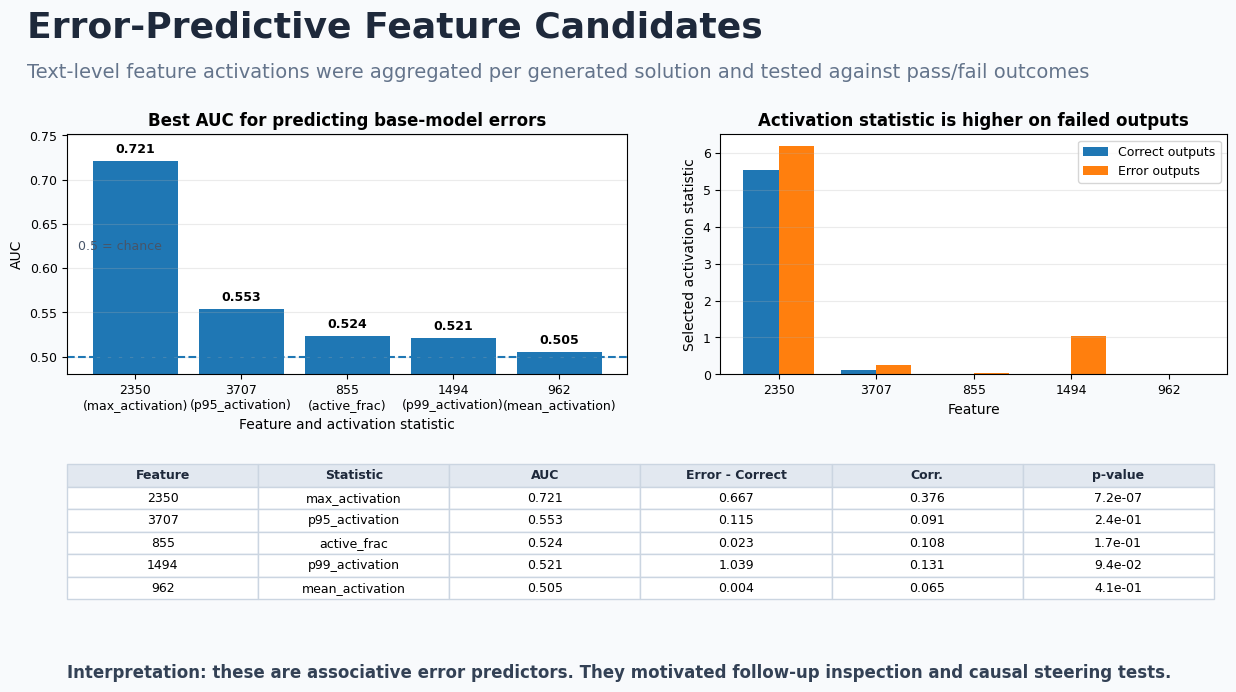

Saved PNG: /content/presentation_assets/error_predictive_features.png
Saved SVG: /content/presentation_assets/error_predictive_features.svg
Copied to gs://data-intelligence-bucket/tests/


In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

features_error_predictive = [2350, 3707, 855, 1494, 962]

# Filter the text-level error-prediction table
d = df_feature_error_corr[
    (df_feature_error_corr["source_model"] == "base") &
    (df_feature_error_corr["feature"].isin(features_error_predictive))
].copy()

# For each feature, keep the row with the best AUC
best_auc = (
    d.sort_values("auc_predict_error", ascending=False)
     .groupby("feature", as_index=False)
     .head(1)
     .sort_values("auc_predict_error", ascending=False)
     .copy()
)

best_auc["label"] = best_auc["feature"].astype(str) + "\n(" + best_auc["score_col"].astype(str) + ")"
best_auc["auc_above_chance"] = best_auc["auc_predict_error"] - 0.5

display(best_auc[
    ["feature", "score_col", "auc_predict_error", "mean_score_correct",
     "mean_score_error", "diff_error_minus_correct",
     "pointbiserial_corr_with_error", "pvalue"]
])

# -------------------------------------------------------
# Figure: error-predictive features
# -------------------------------------------------------
fig = plt.figure(figsize=(13.33, 7.5))
fig.patch.set_facecolor("#F8FAFC")

fig.text(
    0.04, 0.93,
    "Error-Predictive Feature Candidates",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
    ha="left"
)

fig.text(
    0.04, 0.875,
    "Text-level feature activations were aggregated per generated solution and tested against pass/fail outcomes",
    fontsize=14,
    color="#64748B",
    ha="left"
)

# Left chart: AUC by feature
ax1 = fig.add_axes([0.07, 0.48, 0.42, 0.32])
bars = ax1.bar(best_auc["label"], best_auc["auc_predict_error"])
ax1.axhline(0.5, linestyle="--", linewidth=1.5)
ax1.set_ylim(0.48, max(0.75, best_auc["auc_predict_error"].max() + 0.03))
ax1.set_title("Best AUC for predicting base-model errors", fontsize=12, fontweight="bold")
ax1.set_ylabel("AUC")
ax1.set_xlabel("Feature and activation statistic")
ax1.tick_params(axis="x", labelsize=9)
ax1.tick_params(axis="y", labelsize=9)
ax1.grid(axis="y", alpha=0.25)

for bar, auc in zip(bars, best_auc["auc_predict_error"]):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        auc + 0.006,
        f"{auc:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax1.text(
    0.02, 0.52,
    "0.5 = chance",
    transform=ax1.transAxes,
    fontsize=9,
    color="#475569"
)

# Right chart: correct vs error score
ax2 = fig.add_axes([0.56, 0.48, 0.38, 0.32])
x = np.arange(len(best_auc))
width = 0.36

ax2.bar(x - width/2, best_auc["mean_score_correct"], width, label="Correct outputs")
ax2.bar(x + width/2, best_auc["mean_score_error"], width, label="Error outputs")

ax2.set_title("Activation statistic is higher on failed outputs", fontsize=12, fontweight="bold")
ax2.set_ylabel("Selected activation statistic")
ax2.set_xticks(x)
ax2.set_xticklabels(best_auc["feature"].astype(str), fontsize=9)
ax2.set_xlabel("Feature")
ax2.tick_params(axis="y", labelsize=9)
ax2.grid(axis="y", alpha=0.25)
ax2.legend(fontsize=9)

# Bottom table-like summary
summary = best_auc[
    ["feature", "score_col", "auc_predict_error", "diff_error_minus_correct",
     "pointbiserial_corr_with_error", "pvalue"]
].copy()

summary = summary.rename(columns={
    "feature": "Feature",
    "score_col": "Statistic",
    "auc_predict_error": "AUC",
    "diff_error_minus_correct": "Error - Correct",
    "pointbiserial_corr_with_error": "Corr.",
    "pvalue": "p-value"
})

summary["AUC"] = summary["AUC"].map(lambda v: f"{v:.3f}")
summary["Error - Correct"] = summary["Error - Correct"].map(lambda v: f"{v:.3f}")
summary["Corr."] = summary["Corr."].map(lambda v: f"{v:.3f}")
summary["p-value"] = summary["p-value"].map(lambda v: f"{v:.1e}")

ax_tbl = fig.add_axes([0.07, 0.17, 0.86, 0.20])
ax_tbl.axis("off")

tbl = ax_tbl.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.35)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#CBD5E1")
    if row == 0:
        cell.set_text_props(fontweight="bold", color="#1E293B")
        cell.set_facecolor("#E2E8F0")
    else:
        cell.set_facecolor("#FFFFFF")

fig.text(
    0.07, 0.075,
    "Interpretation: these are associative error predictors. They motivated follow-up inspection and causal steering tests.",
    fontsize=12,
    color="#334155",
    fontweight="bold",
    ha="left"
)

png_path = OUT_DIR / "error_predictive_features.png"
svg_path = OUT_DIR / "error_predictive_features.svg"

fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="#F8FAFC")
fig.savefig(svg_path, bbox_inches="tight", facecolor="#F8FAFC")
plt.show()

print("Saved PNG:", png_path)
print("Saved SVG:", svg_path)

try:
    subprocess.run(["gsutil", "cp", str(png_path), "gs://data-intelligence-bucket/tests/"], check=True)
    subprocess.run(["gsutil", "cp", str(svg_path), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)

In [ ]:
def entropy_normalized(probs, eps=1e-12):
    probs = np.asarray(probs, dtype=np.float64)
    probs = probs / (probs.sum() + eps)
    probs = probs[probs > 0]

    if len(probs) <= 1:
        return 0.0

    entropy = -np.sum(probs * np.log(probs + eps))
    return float(entropy / np.log(len(probs)))


def summarize_feature_specificity(feature_id):
    df_feat = aggregate_feature_by_text(feature_id)

    # Text-level concentration.
    text_scores = df_feat["sum_activation"].values.astype(float)
    total = text_scores.sum() + 1e-12
    probs = text_scores / total

    top1_share = float(np.sort(probs)[-1]) if len(probs) else np.nan
    top5_share = float(np.sort(probs)[-5:].sum()) if len(probs) >= 5 else float(np.sort(probs).sum())
    top10_share = float(np.sort(probs)[-10:].sum()) if len(probs) >= 10 else float(np.sort(probs).sum())

    text_entropy = entropy_normalized(probs)

    # Task-level concentration.
    task_scores = df_feat.groupby("task_id")["sum_activation"].sum()
    task_probs = task_scores.values / (task_scores.values.sum() + 1e-12)

    task_top1_share = float(np.sort(task_probs)[-1]) if len(task_probs) else np.nan
    task_top5_share = float(np.sort(task_probs)[-5:].sum()) if len(task_probs) >= 5 else float(np.sort(task_probs).sum())
    task_entropy = entropy_normalized(task_probs)

    # Source specificity.
    source_sum = df_feat.groupby("source_model")["sum_activation"].sum()
    base_sum = float(source_sum.get("base", 0.0))
    merged_sum = float(source_sum.get("merged", 0.0))
    source_base_share = base_sum / (base_sum + merged_sum + 1e-12)

    return {
        "feature": int(feature_id),
        "text_top1_share": top1_share,
        "text_top5_share": top5_share,
        "text_top10_share": top10_share,
        "text_entropy_norm": text_entropy,
        "task_top1_share": task_top1_share,
        "task_top5_share": task_top5_share,
        "task_entropy_norm": task_entropy,
        "source_base_share": source_base_share,
        "source_merged_share": 1.0 - source_base_share,
        "mean_active_frac": float(df_feat["active_frac"].mean()),
        "mean_activation": float(df_feat["mean_activation"].mean()),
        "max_activation": float(df_feat["max_activation"].max()),
    }


specificity_rows = []

for feat in all_candidate_features:
    specificity_rows.append(summarize_feature_specificity(feat))

df_specificity = pd.DataFrame(specificity_rows)

display(
    df_specificity
    .sort_values("task_entropy_norm")
    .head(30)
)

df_specificity.to_csv(CC_DIR / "feature_specificity_v3.csv", index=False)

,feature,text_top1_share,text_top5_share,text_top10_share,text_entropy_norm,task_top1_share,task_top5_share,task_entropy_norm,source_base_share,source_merged_share,mean_active_frac,mean_activation,max_activation
29,2756,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000223,0.005346,38.086510
12,1471,0.495583,1.000000,1.000000,0.536506,0.991138,1.000000,0.051656,0.499359,0.500641,0.000522,0.009800,29.906507
0,124,0.488492,0.985019,0.994668,0.333926,0.955708,0.993081,0.103027,0.498379,0.501621,0.005396,0.042168,27.183853
7,855,0.561413,0.992771,0.997541,0.438709,0.734575,0.995948,0.255942,0.316076,0.683924,0.013040,0.098140,20.517540
6,810,0.798233,0.956202,0.988503,0.283367,0.806465,0.974807,0.288567,0.021843,0.978157,0.007802,0.044439,21.954535
23,2311,0.302626,0.895475,0.965788,0.543366,0.519174,0.919569,0.471267,0.357205,0.642795,0.002516,0.009385,30.891174
21,2191,0.359917,0.833124,0.997522,0.672235,0.528820,0.994705,0.519075,0.654367,0.345633,0.005380,0.058162,23.443811
14,1494,0.205414,0.981758,1.000000,0.736361,0.394202,0.995369,0.669171,0.787620,0.212380,0.004498,0.085400,26.563526
9,962,0.444718,0.930119,1.000000,0.746687,0.444718,0.930119,0.746687,0.183583,0.816417,0.000779,0.009668,26.552578
16,1639,0.116272,0.304786,0.408054,0.815890,0.120077,0.358734,0.810961,0.530993,0.469007,0.034035,0.094397,18.590395


In [ ]:
# Focus on base-harmful candidates.
df_base_error_corr = df_feature_error_corr[
    (df_feature_error_corr["source_model"] == "base") &
    (df_feature_error_corr["score_col"] == "mean_activation")
].copy()

df_harmful_eval = (
    df_harmful_base
    .merge(df_base_error_corr, on="feature", how="left", suffixes=("", "_corr"))
    .merge(df_specificity, on="feature", how="left")
)

# A practical prioritization score for causal testing:
# - high harmful/base score
# - high AUC for predicting base error
# - lower task entropy means more specificity
# - avoid features active in almost every token
df_harmful_eval["causal_priority_score"] = (
    df_harmful_eval["score"]
    * (df_harmful_eval["auc_predict_error"].fillna(0.5) - 0.5).clip(lower=0)
    * (1.0 - df_harmful_eval["task_entropy_norm"].fillna(1.0))
    * (1.0 - df_harmful_eval["mean_active_frac"].fillna(1.0)).clip(lower=0)
)

display(
    df_harmful_eval
    .sort_values("causal_priority_score", ascending=False)
    .head(30)
)

df_harmful_eval.to_csv(CC_DIR / "harmful_base_feature_eval_v3.csv", index=False)

,feature,base_norm,merged_norm,total_norm,base_score,merged_score,global_mean,global_active_frac,merged_mean,merged_active_frac,...,text_entropy_norm,task_top1_share,task_top5_share,task_entropy_norm,source_base_share,source_merged_share,mean_active_frac,mean_activation,max_activation,causal_priority_score
7,3707,1.883405,1.148243,3.031647,0.621248,0.378752,0.093802,0.022291,0.093082,0.022720,...,0.894849,0.066110,0.259923,0.870695,0.476292,0.523708,0.018855,0.077904,18.742231,2.700890e-05
10,855,1.304735,1.277575,2.582310,0.505259,0.494741,0.086479,0.010142,0.112069,0.012311,...,0.438709,0.734575,0.995948,0.255942,0.316076,0.683924,0.013040,0.098140,20.517540,1.938667e-05
15,1494,1.003733,0.939311,1.943043,0.516578,0.483422,0.026784,0.001690,0.010778,0.000901,...,0.736361,0.394202,0.995369,0.669171,0.787620,0.212380,0.004498,0.085400,26.563526,9.865414e-07
14,962,1.252347,1.234193,2.486541,0.503650,0.496350,0.023521,0.001902,0.036385,0.002803,...,0.746687,0.444718,0.930119,0.746687,0.183583,0.816417,0.000779,0.009668,26.552578,6.526973e-07
1,2673,1.703638,0.962338,2.665976,0.639030,0.360970,0.282507,0.118483,0.245199,0.110600,...,0.873670,0.049013,0.207809,0.880688,0.541938,0.458062,0.094106,0.199891,15.546752,0.000000e+00
2,1962,2.001312,1.221670,3.222982,0.620950,0.379050,0.320095,0.132851,0.319291,0.127214,...,0.918530,0.034699,0.131567,0.931504,0.473565,0.526435,0.141235,0.282752,15.271776,0.000000e+00
4,421,1.568511,0.951061,2.519572,0.622531,0.377469,0.146036,0.044741,0.145961,0.044540,...,0.899770,0.042867,0.178335,0.889275,0.472512,0.527488,0.036351,0.113679,12.667521,0.000000e+00
6,810,1.405970,1.370517,2.776487,0.506384,0.493616,0.094806,0.013787,0.175714,0.023922,...,0.283367,0.806465,0.974807,0.288567,0.021843,0.978157,0.007802,0.044439,21.954535,0.000000e+00
5,2934,1.378256,0.948597,2.326853,0.592326,0.407674,0.074520,0.017696,0.074023,0.017416,...,0.927630,0.054833,0.191652,0.914893,0.475760,0.524240,0.014336,0.061289,18.137587,0.000000e+00
3,1639,1.604855,1.244459,2.849314,0.563242,0.436758,0.168400,0.051503,0.149653,0.047343,...,0.815890,0.120077,0.358734,0.810961,0.530993,0.469007,0.034035,0.094397,18.590395,0.000000e+00


In [ ]:
# Load tokenizer for decoding token ids.
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)

def token_association_for_feature(feature_id, top_fraction=0.01, min_count=3):
    vals = Z[:, feature_id]

    threshold = np.quantile(vals, 1.0 - top_fraction)
    top_mask = vals >= threshold

    rows = []

    for filt_idx in np.where(top_mask)[0]:
        full_idx = int(filtered_to_full[filt_idx])
        loc = locate_full_token(full_idx)

        if loc is None:
            continue

        input_ids = np.load(loc["input_ids_path"])[0]
        pos = loc["local_pos_in_full_text"]

        if pos >= len(input_ids):
            continue

        token_id = int(input_ids[pos])
        token_text = tokenizer.decode([token_id])

        rows.append({
            "feature": int(feature_id),
            "filtered_idx": int(filt_idx),
            "full_idx": int(full_idx),
            "activation": float(vals[filt_idx]),
            "token_id": token_id,
            "token_text": token_text,
            "task_id": loc["task_id"],
            "source_model": loc["source_model"],
            "task_label": loc["task_label"],
            "source_correct": loc["source_correct"],
            "base_correct": loc["base_correct"],
            "merged_correct": loc["merged_correct"],
        })

    df_tok = pd.DataFrame(rows)

    if len(df_tok) == 0:
        return df_tok, pd.DataFrame()

    token_summary = (
        df_tok
        .groupby(["token_id", "token_text"])
        .agg(
            count=("activation", "count"),
            mean_activation=("activation", "mean"),
            max_activation=("activation", "max"),
            base_share=("source_model", lambda s: float((s == "base").mean())),
            merged_only_correct_share=("task_label", lambda s: float((s == "merged_only_correct").mean())),
            error_share=("source_correct", lambda s: float((~s.astype(bool)).mean())),
        )
        .reset_index()
    )

    token_summary = token_summary[token_summary["count"] >= min_count].copy()

    token_summary["token_score"] = (
        token_summary["count"]
        * token_summary["mean_activation"]
    )

    token_summary = token_summary.sort_values("token_score", ascending=False)

    return df_tok, token_summary

tokenizer_config.json:   0%|          | 0.00/793 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
top_harmful_for_tokens = (
    df_harmful_eval
    .sort_values("causal_priority_score", ascending=False)
    ["feature"]
    .head(10)
    .astype(int)
    .tolist()
)

print("Top harmful features for token inspection:", top_harmful_for_tokens)

for feat in top_harmful_for_tokens[:5]:
    print("\n" + "=" * 120)
    print("FEATURE", feat)

    df_tok_raw, df_tok_summary = token_association_for_feature(
        feat,
        top_fraction=0.01,
        min_count=2,
    )

    display(df_tok_summary.head(30))

    out_path = CC_DIR / f"feature_{feat}_top_token_associations_v3.csv"
    df_tok_summary.to_csv(out_path, index=False)
    print("Saved:", out_path)

Top harmful features for token inspection: [3707, 855, 1494, 962, 2673, 1962, 421, 810, 2934, 1639]

FEATURE 3707


NameError: name 'locate_full_token' is not defined

In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import subprocess

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    png = OUT_DIR / f"{name}.png"
    svg = OUT_DIR / f"{name}.svg"
    fig.savefig(png, dpi=220, bbox_inches="tight", facecolor="#F8FAFC")
    fig.savefig(svg, bbox_inches="tight", facecolor="#F8FAFC")
    plt.close(fig)
    print("Saved:", png)
    print("Saved:", svg)
    return png, svg

def box(ax, x, y, w, h, text, fc="#FFFFFF", ec="#CBD5E1", size=11, bold=False):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.6,
        edgecolor=ec,
        facecolor=fc,
    )
    ax.add_patch(patch)
    ax.text(
        x + w/2, y + h/2, text,
        ha="center",
        va="center",
        fontsize=size,
        fontweight="bold" if bold else "normal",
        color="#1E293B",
        wrap=True,
    )

def arrow(ax, start, end, color="#64748B"):
    ax.add_patch(FancyArrowPatch(
        start, end,
        arrowstyle="->",
        mutation_scale=16,
        linewidth=1.8,
        color=color,
    ))

# ============================================================
# SLIDE 1 — Method, fixed layout
# ============================================================

fig, ax = plt.subplots(figsize=(13.33, 7.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig.patch.set_facecolor("#F8FAFC")

ax.text(
    0.04, 0.93,
    "How Candidate Features Were Selected",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
    ha="left",
)

ax.text(
    0.04, 0.875,
    "From 4,096 CrossCoder features to a small set of candidates for inspection and steering",
    fontsize=14,
    color="#64748B",
    ha="left",
)

# Pipeline row
y = 0.67
h = 0.13
w = 0.20
xs = [0.055, 0.295, 0.535, 0.775]

box(ax, xs[0], y, w, h, "1. Decoder norms\nbase vs. merged\nfeature direction",
    fc="#EFF6FF", ec="#60A5FA", size=11.5, bold=True)
box(ax, xs[1], y, w, h, "2. Behavioral labels\nmerged-only correct\nvs. other outputs",
    fc="#ECFDF5", ec="#34D399", size=11.5, bold=True)
box(ax, xs[2], y, w, h, "3. Activation gap\nmean / active fraction\nby group",
    fc="#F5F3FF", ec="#8B5CF6", size=11.5, bold=True)
box(ax, xs[3], y, 0.17, h, "4. Candidate score\nrank features\nfor inspection",
    fc="#FFF7ED", ec="#FB923C", size=11.5, bold=True)

arrow(ax, (xs[0] + w, y + h/2), (xs[1], y + h/2))
arrow(ax, (xs[1] + w, y + h/2), (xs[2], y + h/2))
arrow(ax, (xs[2] + w, y + h/2), (xs[3], y + h/2))

# Heuristic box
box(
    ax, 0.08, 0.43, 0.84, 0.105,
    "Main heuristic: score = model-specificity × feature magnitude × behavioral activation difference",
    fc="#FFFFFF",
    ec="#CBD5E1",
    size=14.5,
    bold=True,
)

ax.text(
    0.10, 0.345,
    "Example for helpful merged candidates:",
    fontsize=13,
    fontweight="bold",
    color="#334155",
    ha="left",
)

ax.text(
    0.10, 0.305,
    "score = (merged_score − 0.5) × total_norm × "
    "(mean activation on merged-only-correct − mean activation on other merged outputs)",
    fontsize=11.5,
    color="#475569",
    ha="left",
)

# Candidate groups row
box(
    ax, 0.08, 0.105, 0.25, 0.12,
    "Helpful merged features\nmerged_score > 0.5\ncorrectness_diff > 0",
    fc="#ECFDF5",
    ec="#34D399",
    size=11.5,
    bold=True,
)

box(
    ax, 0.375, 0.105, 0.25, 0.12,
    "Potentially harmful\nbase features\nmerged_score < 0.5\ncorrectness_diff < 0",
    fc="#FEF2F2",
    ec="#F87171",
    size=11.5,
    bold=True,
)

box(
    ax, 0.67, 0.105, 0.25, 0.12,
    "Causal validation\nactivation steering\nand code inspection",
    fc="#F5F3FF",
    ec="#8B5CF6",
    size=11.5,
    bold=True,
)

slide1_png, slide1_svg = save_fig(fig, "feature_selection_method_fixed")


# ============================================================
# SLIDE 2 — Evidence, fixed layout
# ============================================================

helpful_cols = ["feature", "merged_score", "correctness_diff", "correctness_active_diff", "score"]
harmful_cols = ["feature", "merged_score", "correctness_diff", "correctness_active_diff", "score"]

helpful_small = df_helpful_merged[helpful_cols].head(6).copy()
harmful_small = df_harmful_base[harmful_cols].head(6).copy()

for d in [helpful_small, harmful_small]:
    for col in d.columns:
        if col != "feature":
            d[col] = d[col].astype(float).round(4)
    d["feature"] = d["feature"].astype(int)

fig = plt.figure(figsize=(13.33, 7.5))
fig.patch.set_facecolor("#F8FAFC")

# Title area
fig.text(
    0.04, 0.93,
    "Feature Ranking Evidence",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
    ha="left",
)

fig.text(
    0.04, 0.875,
    "Ranking views separate broad associative signals from candidates worth testing causally",
    fontsize=14,
    color="#64748B",
    ha="left",
)

# Use axes boxes manually but with more vertical spacing
ax_left = fig.add_axes([0.07, 0.52, 0.40, 0.28])
ax_right = fig.add_axes([0.55, 0.52, 0.40, 0.28])

bar_df = df_harmful_base.head(8).copy()
ax_left.bar(bar_df["feature"].astype(str), bar_df["score"])
ax_left.set_title("Potentially harmful/base-specific candidates", fontsize=12, fontweight="bold")
ax_left.set_xlabel("Feature", fontsize=10)
ax_left.set_ylabel("Score", fontsize=10)
ax_left.tick_params(axis="x", rotation=45, labelsize=9)
ax_left.tick_params(axis="y", labelsize=9)
ax_left.grid(axis="y", alpha=0.25)

bar_df2 = df_helpful_merged.head(8).copy()
ax_right.bar(bar_df2["feature"].astype(str), bar_df2["score"])
ax_right.set_title("Helpful/merged-associated candidates", fontsize=12, fontweight="bold")
ax_right.set_xlabel("Feature", fontsize=10)
ax_right.set_ylabel("Score", fontsize=10)
ax_right.tick_params(axis="x", rotation=45, labelsize=9)
ax_right.tick_params(axis="y", labelsize=9)
ax_right.grid(axis="y", alpha=0.25)

# Table axes
ax_tbl_left = fig.add_axes([0.055, 0.18, 0.43, 0.25])
ax_tbl_right = fig.add_axes([0.535, 0.18, 0.43, 0.25])

for ax_tbl in [ax_tbl_left, ax_tbl_right]:
    ax_tbl.axis("off")

ax_tbl_left.set_title("Harmful/base candidates", fontsize=12, fontweight="bold", color="#1E293B", pad=6)
ax_tbl_right.set_title("Helpful merged candidates", fontsize=12, fontweight="bold", color="#1E293B", pad=6)

harmful_display = harmful_small.rename(columns={
    "feature": "feat",
    "merged_score": "m_score",
    "correctness_diff": "corr_diff",
    "correctness_active_diff": "act_diff",
    "score": "score",
})

helpful_display = helpful_small.rename(columns={
    "feature": "feat",
    "merged_score": "m_score",
    "correctness_diff": "corr_diff",
    "correctness_active_diff": "act_diff",
    "score": "score",
})

tbl1 = ax_tbl_left.table(
    cellText=harmful_display.values,
    colLabels=harmful_display.columns,
    cellLoc="center",
    loc="center",
)
tbl2 = ax_tbl_right.table(
    cellText=helpful_display.values,
    colLabels=helpful_display.columns,
    cellLoc="center",
    loc="center",
)

for tbl in [tbl1, tbl2]:
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1.0, 1.35)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("#CBD5E1")
        if row == 0:
            cell.set_text_props(fontweight="bold", color="#1E293B")
            cell.set_facecolor("#E2E8F0")
        else:
            cell.set_facecolor("#FFFFFF")

# Footer note
fig.text(
    0.05, 0.075,
    "Interpretation: these rankings are associative, not causal. They identify candidate directions; steering tests are used as causal validation.",
    fontsize=12,
    color="#334155",
    fontweight="bold",
    ha="left",
)

slide2_png, slide2_svg = save_fig(fig, "feature_ranking_evidence_fixed")

# Optional GCS copy
try:
    for p in [slide1_png, slide1_svg, slide2_png, slide2_svg]:
        subprocess.run(["gsutil", "cp", str(p), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied fixed slide assets to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)

slide1_png, slide2_png

Saved: /content/presentation_assets/feature_selection_method_fixed.png
Saved: /content/presentation_assets/feature_selection_method_fixed.svg
Saved: /content/presentation_assets/feature_ranking_evidence_fixed.png
Saved: /content/presentation_assets/feature_ranking_evidence_fixed.svg
Copied fixed slide assets to gs://data-intelligence-bucket/tests/


(PosixPath('/content/presentation_assets/feature_selection_method_fixed.png'),
 PosixPath('/content/presentation_assets/feature_ranking_evidence_fixed.png'))

In [ ]:
features_error_predictive = [2350, 3707, 855, 1494, 962]
features_base_harmful = [1323, 2673, 1962, 1639, 421]
features_helpful_merged = [165, 1477, 2648, 1907, 3807]

features_to_inspect = sorted(set(
    features_error_predictive +
    features_base_harmful +
    features_helpful_merged
))

features_to_inspect

[165,
 421,
 855,
 962,
 1323,
 1477,
 1494,
 1639,
 1907,
 1962,
 2350,
 2648,
 2673,
 3707,
 3807]

In [ ]:
def token_association_for_feature_positive(feature_id, top_k_tokens=300, min_count=1):
    vals = Z[:, feature_id]

    positive_idx = np.where(vals > 0)[0]

    if len(positive_idx) == 0:
        return pd.DataFrame(), pd.DataFrame()

    # Take strongest positive activations.
    top_idx = positive_idx[np.argsort(-vals[positive_idx])[:top_k_tokens]]

    rows = []

    for filt_idx in top_idx:
        full_idx = int(filtered_to_full[filt_idx])
        loc = locate_full_token(full_idx)

        if loc is None:
            continue

        input_ids = np.load(loc["input_ids_path"])[0]
        pos = loc["local_pos_in_full_text"]

        if pos >= len(input_ids):
            continue

        token_id = int(input_ids[pos])
        token_text = tokenizer.decode([token_id])

        rows.append({
            "feature": int(feature_id),
            "filtered_idx": int(filt_idx),
            "full_idx": int(full_idx),
            "activation": float(vals[filt_idx]),
            "token_id": token_id,
            "token_text": token_text,
            "task_id": loc["task_id"],
            "source_model": loc["source_model"],
            "task_label": loc["task_label"],
            "source_correct": bool(loc["source_correct"]),
            "base_correct": bool(loc["base_correct"]),
            "merged_correct": bool(loc["merged_correct"]),
        })

    df_tok = pd.DataFrame(rows)

    if len(df_tok) == 0:
        return df_tok, pd.DataFrame()

    token_summary = (
        df_tok
        .groupby(["token_id", "token_text"])
        .agg(
            count=("activation", "count"),
            mean_activation=("activation", "mean"),
            max_activation=("activation", "max"),
            base_share=("source_model", lambda s: float((s == "base").mean())),
            merged_share=("source_model", lambda s: float((s == "merged").mean())),
            source_error_share=("source_correct", lambda s: float((~s.astype(bool)).mean())),
            merged_only_correct_share=("task_label", lambda s: float((s == "merged_only_correct").mean())),
            both_incorrect_share=("task_label", lambda s: float((s == "both_incorrect").mean())),
        )
        .reset_index()
    )

    token_summary = token_summary[token_summary["count"] >= min_count].copy()

    token_summary["token_score"] = (
        token_summary["count"] *
        token_summary["mean_activation"] *
        (1.0 + token_summary["source_error_share"])
    )

    token_summary = token_summary.sort_values("token_score", ascending=False)

    return df_tok, token_summary

In [ ]:
# Map a full token index back to the corresponding generated text and local position.

filtered_to_full = np.where(mask)[0]
full_to_filtered = {
    int(full_idx): int(filtered_idx)
    for filtered_idx, full_idx in enumerate(filtered_to_full)
}

def locate_full_token(global_full_idx):
    for item in paired_index:
        if item["global_start"] <= global_full_idx < item["global_end"]:
            local_in_output = global_full_idx - item["global_start"]
            local_pos_in_full_text = item["local_start_pos"] + local_in_output

            return {
                **item,
                "local_in_output": int(local_in_output),
                "local_pos_in_full_text": int(local_pos_in_full_text),
            }

    return None

In [ ]:
token_association_tables = {}

for feat in features_to_inspect:
    print("\n" + "=" * 120)
    print("FEATURE", feat)

    df_tok_raw, df_tok_summary = token_association_for_feature_positive(
        feature_id=feat,
        top_k_tokens=300,
        min_count=1,
    )

    token_association_tables[feat] = {
        "raw": df_tok_raw,
        "summary": df_tok_summary,
    }

    display(df_tok_summary.head(25))

    df_tok_summary.to_csv(
        CC_DIR / f"feature_{feat}_positive_token_associations_v3.csv",
        index=False,
    )


FEATURE 165


,token_id,token_text,count,mean_activation,max_activation,base_share,merged_share,source_error_share,merged_only_correct_share,both_incorrect_share,token_score
11,58,[,47,6.805172,10.195601,0.425532,0.574468,0.276596,0.702128,0.000000,408.310348
1,7,(,27,6.446433,7.382808,0.592593,0.407407,0.518519,0.481481,0.222222,264.303751
10,25,:,17,6.632089,8.256547,0.352941,0.647059,0.235294,0.529412,0.058824,139.273872
24,252,s,11,6.400304,7.420146,0.636364,0.363636,0.545455,0.909091,0.000000,108.805170
46,1726,word,11,6.760129,8.368541,0.363636,0.636364,0.363636,1.000000,0.000000,101.401929
49,2600,string,11,6.615003,7.768485,0.454545,0.545455,0.181818,0.454545,0.000000,85.995040
5,15,0,7,6.141055,6.739496,0.285714,0.714286,0.571429,0.428571,0.571429,67.551609
62,13323,lower,7,6.221481,6.669312,0.285714,0.714286,0.428571,0.571429,0.285714,62.214806
71,22441,upper,6,6.683422,7.131464,0.500000,0.500000,0.500000,0.500000,0.166667,60.150801
43,1435,)),7,6.608203,7.818890,0.428571,0.571429,0.285714,0.714286,0.000000,59.473826



FEATURE 421


,token_id,token_text,count,mean_activation,max_activation,base_share,merged_share,source_error_share,merged_only_correct_share,both_incorrect_share,token_score
7,62,_,92,6.485361,12.667521,0.413043,0.586957,0.413043,0.206522,0.347826,843.096977
13,185,\n,41,5.889082,10.266707,0.390244,0.609756,0.463415,0.219512,0.414634,353.344945
17,284,l,29,5.971099,10.540147,0.620690,0.379310,0.655172,0.586207,0.310345,286.612748
9,75,l,13,6.769128,12.093759,0.538462,0.461538,0.307692,0.307692,0.230769,115.075172
47,6487,num,13,6.485527,11.989106,0.615385,0.384615,0.230769,0.384615,0.000000,103.768429
33,1571,br,8,7.760844,11.944014,0.500000,0.500000,0.625000,0.500000,0.250000,100.890968
53,12606,fib,7,5.321108,7.539468,0.142857,0.857143,0.857143,0.000000,0.857143,69.174408
14,207,,8,4.452411,5.673666,0.500000,0.500000,0.375000,0.125000,0.250000,48.976519
35,1753,file,3,7.754325,9.361981,1.000000,0.000000,1.000000,0.000000,1.000000,46.525949
32,1443,type,4,5.326722,6.009257,1.000000,0.000000,1.000000,0.000000,1.000000,42.613772



FEATURE 855


...

,token_id,token_text,count,mean_activation,max_activation,base_share,merged_share,source_error_share,merged_only_correct_share,both_incorrect_share,token_score
16,62,_,74,7.013846,12.245846,0.378378,0.621622,0.445946,0.148649,0.391892,750.481538
23,207,,34,7.471887,12.785281,0.705882,0.294118,0.382353,0.235294,0.176471,351.178711
22,185,\n,20,7.843782,13.188089,0.600000,0.400000,0.750000,0.150000,0.650000,274.532378
49,2974,code,13,6.694081,8.675045,1.000000,0.000000,1.000000,0.000000,1.000000,174.046106
3,11,",",8,9.644470,15.525444,0.750000,0.250000,1.000000,0.250000,0.750000,154.311514
5,13,.,10,6.774285,9.162180,0.700000,0.300000,0.800000,0.100000,0.800000,121.937138
26,284,l,10,6.647916,10.105110,0.900000,0.100000,0.800000,0.200000,0.700000,119.662489
1,8,),6,9.248711,12.057419,1.000000,0.000000,1.000000,0.500000,0.500000,110.984528
9,25,:,7,7.603006,8.626783,0.285714,0.714286,0.857143,0.000000,0.857143,98.839082
34,518,your,6,7.798593,9.055888,1.000000,0.000000,1.000000,0.000000,1.000000,93.583121



FEATURE 3707


,token_id,token_text,count,mean_activation,max_activation,base_share,merged_share,source_error_share,merged_only_correct_share,both_incorrect_share,token_score
16,185,\n,103,5.589438,14.405684,0.446602,0.553398,0.563107,0.300971,0.466019,899.899508
19,284,l,32,5.951587,14.307330,0.531250,0.468750,0.593750,0.500000,0.375000,303.530923
8,62,_,45,4.219370,12.955067,0.311111,0.688889,0.533333,0.133333,0.511111,291.136512
12,75,l,25,6.891536,11.870072,0.600000,0.400000,0.360000,0.440000,0.200000,234.312224
49,13324,dig,6,8.972602,13.913046,0.000000,1.000000,0.500000,0.166667,0.500000,80.753420
21,306,g,4,7.188748,11.499011,0.000000,1.000000,1.000000,0.000000,1.000000,57.509982
32,1753,file,3,6.723188,13.211589,0.666667,0.333333,1.000000,0.000000,1.000000,40.339126
35,3659,tri,2,9.860675,13.377635,0.000000,1.000000,1.000000,0.000000,1.000000,39.442700
20,292,st,6,4.344126,7.983427,0.500000,0.500000,0.500000,1.000000,0.000000,39.097132
13,76,m,3,13.002367,18.742231,0.666667,0.333333,0.000000,0.000000,0.000000,39.007100



FEATURE 3807


,token_id,token_text,count,mean_activation,max_activation,base_share,merged_share,source_error_share,merged_only_correct_share,both_incorrect_share,token_score
0,7,(,82,7.219767,10.128147,0.536585,0.463415,0.341463,0.573171,0.085366,794.174423
11,3160,range,65,7.742285,11.059761,0.507692,0.492308,0.338462,0.569231,0.092308,673.578772
14,6446,len,43,8.766489,11.186829,0.488372,0.511628,0.348837,0.534884,0.116279,508.456373
8,460,i,45,6.646562,7.764421,0.466667,0.533333,0.288889,0.555556,0.088889,385.500613
16,10405,len,10,6.888398,8.542679,0.400000,0.600000,0.200000,0.700000,0.000000,82.660777
1,8,),9,6.180972,6.609229,0.444444,0.555556,0.444444,0.444444,0.222222,80.352635
5,72,i,9,6.784316,7.511073,0.444444,0.555556,0.111111,0.444444,0.000000,67.843158
7,279,in,9,6.780182,8.184031,0.444444,0.555556,0.111111,0.444444,0.000000,67.801821
2,11,",",6,7.062288,8.490088,0.333333,0.666667,0.333333,1.000000,0.000000,56.498301
10,2221,lambda,4,6.095598,6.277790,0.500000,0.500000,0.750000,0.500000,0.250000,42.669188


Features available for word clouds: [855, 962, 1494, 2350, 3707]


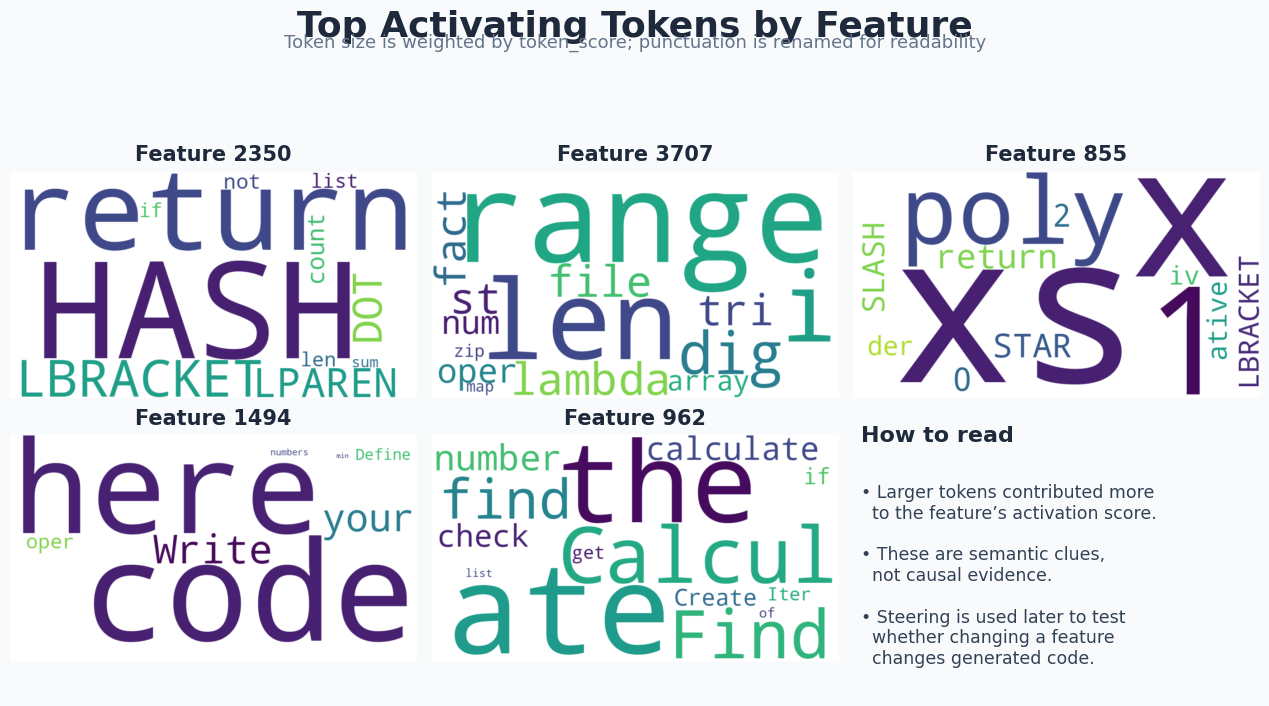

Saved PNG: /content/presentation_assets/feature_token_wordclouds.png
Saved SVG: /content/presentation_assets/feature_token_wordclouds.svg
Copied to gs://data-intelligence-bucket/tests/


In [216]:
# Generate token word clouds per CrossCoder feature
# Assumes you already have one dataframe per feature OR a combined dataframe.
# If not, see the manual dictionary fallback below.

!pip install -q wordcloud

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import subprocess
import re

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Option A: if you already have per-feature token tables
# Expected format:
# token_tables_by_feature = {
#     962: df_tokens_962,
#     2350: df_tokens_2350,
#     ...
# }
# Each df should include: token_text, token_score
# ------------------------------------------------------------

features_to_plot = [2350, 3707, 855, 1494, 962]

# Try to discover token tables if you named them like df_tokens_962, df_feature_962, etc.
token_tables_by_feature = {}

for feat in features_to_plot:
    possible_names = [
        f"df_tokens_{feat}",
        f"df_feature_{feat}",
        f"tokens_{feat}",
        f"feature_{feat}_tokens",
    ]
    for name in possible_names:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            token_tables_by_feature[feat] = globals()[name].copy()
            break

# ------------------------------------------------------------
# Option B fallback: manually define from the visible tables
# Use this if auto-discovery does not find your token dataframes.
# ------------------------------------------------------------

if len(token_tables_by_feature) == 0:
    manual_tokens = {
        962: [
            ("ate", 175.90), ("the", 139.64), ("Calcul", 131.08),
            ("Find", 96.53), ("find", 60.60), ("number", 55.95),
            ("calculate", 50.39), ("check", 46.75), ("Create", 22.81),
            ("if", 22.22), ("get", 13.90), ("Iter", 13.88),
            ("of", 6.50), ("list", 4.33)
        ],
        2350: [
            ("return", 453.82), ("#", 475.41), ("[", 163.64),
            ("(", 90.66), (".", 90.16), ("count", 18.14),
            ("list", 12.18), ("len", 12.00), ("if", 11.97),
            ("sum", 5.93), ("not", 13.17)
        ],
        3707: [
            ("range", 673.58), ("len", 508.46), ("i", 385.50),
            ("dig", 80.75), ("file", 40.34), ("tri", 39.44),
            ("st", 39.10), ("fact", 36.85), ("oper", 36.41),
            ("num", 33.43), ("array", 33.03), ("lambda", 42.67),
            ("zip", 7.86), ("map", 6.08)
        ],
        855: [
            ("xs", 272.17), ("x", 201.00), ("poly", 76.01),
            ("return", 62.15), ("*", 58.84), ("0", 57.99),
            ("1", 131.76), ("2", 55.22), ("/", 50.40),
            ("[", 42.40), ("der", 37.63), ("iv", 36.22),
            ("ative", 38.97)
        ],
        1494: [
            ("code", 255.77), ("here", 251.05), ("Write", 229.89),
            ("your", 213.60), ("Define", 5.51), ("oper", 10.81),
            ("numbers", 0.99), ("min", 0.52)
        ],
    }

    for feat, items in manual_tokens.items():
        token_tables_by_feature[feat] = pd.DataFrame(
            items,
            columns=["token_text", "token_score"]
        )

print("Features available for word clouds:", sorted(token_tables_by_feature.keys()))

# ------------------------------------------------------------
# Cleaning helpers
# ------------------------------------------------------------

def clean_token_text(tok):
    tok = str(tok)

    # Make invisible tokens slide-readable
    replacements = {
        "\n": "NEWLINE",
        "\t": "TAB",
        " ": "SPACE",
        "": "EMPTY",
    }
    tok = replacements.get(tok, tok)

    tok = tok.replace("\\n", "NEWLINE")
    tok = tok.replace("\\t", "TAB")

    # Avoid wordcloud treating punctuation too weirdly
    readable = {
        "(": "LPAREN",
        ")": "RPAREN",
        "[": "LBRACKET",
        "]": "RBRACKET",
        "{": "LBRACE",
        "}": "RBRACE",
        ":": "COLON",
        ",": "COMMA",
        ".": "DOT",
        "#": "HASH",
        "+": "PLUS",
        "-": "MINUS",
        "*": "STAR",
        "/": "SLASH",
        "=": "EQUALS",
        "==": "EQEQ",
        "+=": "PLUSEQ",
        "[]": "EMPTY_LIST",
        "(": "LPAREN",
        "))": "RPAREN_RPAREN",
        ")))": "RPAREN3",
        "():": "CALL_COLON",
        "):": "RPAREN_COLON",
        "([": "LPAREN_LBRACKET",
    }

    return readable.get(tok, tok.strip() or "EMPTY")

def df_to_freqs(df, top_n=35, score_col="token_score"):
    d = df.copy()

    if "token_text" not in d.columns:
        raise ValueError("Expected column token_text")

    if score_col not in d.columns:
        # fallback to mean_activation * count if available
        if {"mean_activation", "count"}.issubset(d.columns):
            d[score_col] = d["mean_activation"] * d["count"]
        elif "count" in d.columns:
            d[score_col] = d["count"]
        else:
            raise ValueError(f"No {score_col}, mean_activation/count, or count column found.")

    d = d[["token_text", score_col]].dropna()
    d["clean_token"] = d["token_text"].apply(clean_token_text)
    d[score_col] = pd.to_numeric(d[score_col], errors="coerce").fillna(0)
    d = d[d[score_col] > 0]

    # merge duplicated cleaned tokens
    d = (
        d.groupby("clean_token", as_index=False)[score_col]
        .sum()
        .sort_values(score_col, ascending=False)
        .head(top_n)
    )

    return dict(zip(d["clean_token"], d[score_col]))

# ------------------------------------------------------------
# Plot word clouds in a slide-friendly grid
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(13.33, 7.5))
fig.patch.set_facecolor("#F8FAFC")
axes = axes.ravel()

fig.suptitle(
    "Top Activating Tokens by Feature",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
    y=0.965
)

fig.text(
    0.5,
    0.915,
    "Token size is weighted by token_score; punctuation is renamed for readability",
    ha="center",
    fontsize=13,
    color="#64748B"
)

for ax in axes:
    ax.axis("off")

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    freqs = df_to_freqs(token_tables_by_feature[feat], top_n=30)

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        prefer_horizontal=0.9,
        collocations=False,
        max_words=30,
        random_state=42,
        normalize_plurals=False,
    ).generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Feature {feat}", fontsize=15, fontweight="bold", color="#1E293B", pad=8)
    ax.axis("off")

# last panel: short interpretation notes
ax = axes[-1]
ax.axis("off")
ax.text(
    0.02, 0.86,
    "How to read",
    fontsize=16,
    fontweight="bold",
    color="#1E293B",
    transform=ax.transAxes,
)
ax.text(
    0.02, 0.72,
    "• Larger tokens contributed more\n  to the feature’s activation score.\n\n"
    "• These are semantic clues,\n  not causal evidence.\n\n"
    "• Steering is used later to test\n  whether changing a feature\n  changes generated code.",
    fontsize=12.5,
    color="#334155",
    transform=ax.transAxes,
    va="top",
)

plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.88])

png_path = OUT_DIR / "feature_token_wordclouds.png"
svg_path = OUT_DIR / "feature_token_wordclouds.svg"

fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="#F8FAFC")
fig.savefig(svg_path, bbox_inches="tight", facecolor="#F8FAFC")
plt.show()

print("Saved PNG:", png_path)
print("Saved SVG:", svg_path)

try:
    subprocess.run(["gsutil", "cp", str(png_path), "gs://data-intelligence-bucket/tests/"], check=True)
    subprocess.run(["gsutil", "cp", str(svg_path), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)

In [ ]:
# Generate token word clouds per CrossCoder feature
# Assumes you already have one dataframe per feature OR a combined dataframe.
# If not, see the manual dictionary fallback below.

!pip install -q wordcloud

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import subprocess
import re

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Option A: if you already have per-feature token tables
# Expected format:
# token_tables_by_feature = {
#     962: df_tokens_962,
#     2350: df_tokens_2350,
#     ...
# }
# Each df should include: token_text, token_score
# ------------------------------------------------------------

features_to_plot = [2350, 3707, 855, 1494, 962]

# Try to discover token tables if you named them like df_tokens_962, df_feature_962, etc.
token_tables_by_feature = {}

for feat in features_to_plot:
    possible_names = [
        f"df_tokens_{feat}",
        f"df_feature_{feat}",
        f"tokens_{feat}",
        f"feature_{feat}_tokens",
    ]
    for name in possible_names:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            token_tables_by_feature[feat] = globals()[name].copy()
            break

# ------------------------------------------------------------
# Option B fallback: manually define from the visible tables
# Use this if auto-discovery does not find your token dataframes.
# ------------------------------------------------------------

if len(token_tables_by_feature) == 0:
    manual_tokens = {
        962: [
            ("ate", 175.90), ("the", 139.64), ("Calcul", 131.08),
            ("Find", 96.53), ("find", 60.60), ("number", 55.95),
            ("calculate", 50.39), ("check", 46.75), ("Create", 22.81),
            ("if", 22.22), ("get", 13.90), ("Iter", 13.88),
            ("of", 6.50), ("list", 4.33)
        ],
        2350: [
            ("return", 453.82), ("#", 475.41), ("[", 163.64),
            ("(", 90.66), (".", 90.16), ("count", 18.14),
            ("list", 12.18), ("len", 12.00), ("if", 11.97),
            ("sum", 5.93), ("not", 13.17)
        ],
        3707: [
            ("range", 673.58), ("len", 508.46), ("i", 385.50),
            ("dig", 80.75), ("file", 40.34), ("tri", 39.44),
            ("st", 39.10), ("fact", 36.85), ("oper", 36.41),
            ("num", 33.43), ("array", 33.03), ("lambda", 42.67),
            ("zip", 7.86), ("map", 6.08)
        ],
        855: [
            ("xs", 272.17), ("x", 201.00), ("poly", 76.01),
            ("return", 62.15), ("*", 58.84), ("0", 57.99),
            ("1", 131.76), ("2", 55.22), ("/", 50.40),
            ("[", 42.40), ("der", 37.63), ("iv", 36.22),
            ("ative", 38.97)
        ],
        1494: [
            ("code", 255.77), ("here", 251.05), ("Write", 229.89),
            ("your", 213.60), ("Define", 5.51), ("oper", 10.81),
            ("numbers", 0.99), ("min", 0.52)
        ],
    }

    for feat, items in manual_tokens.items():
        token_tables_by_feature[feat] = pd.DataFrame(
            items,
            columns=["token_text", "token_score"]
        )

print("Features available for word clouds:", sorted(token_tables_by_feature.keys()))

# ------------------------------------------------------------
# Cleaning helpers
# ------------------------------------------------------------

def clean_token_text(tok):
    tok = str(tok)

    # Make invisible tokens slide-readable
    replacements = {
        "\n": "NEWLINE",
        "\t": "TAB",
        " ": "SPACE",
        "": "EMPTY",
    }
    tok = replacements.get(tok, tok)

    tok = tok.replace("\\n", "NEWLINE")
    tok = tok.replace("\\t", "TAB")

    # Avoid wordcloud treating punctuation too weirdly
    readable = {
        "(": "LPAREN",
        ")": "RPAREN",
        "[": "LBRACKET",
        "]": "RBRACKET",
        "{": "LBRACE",
        "}": "RBRACE",
        ":": "COLON",
        ",": "COMMA",
        ".": "DOT",
        "#": "HASH",
        "+": "PLUS",
        "-": "MINUS",
        "*": "STAR",
        "/": "SLASH",
        "=": "EQUALS",
        "==": "EQEQ",
        "+=": "PLUSEQ",
        "[]": "EMPTY_LIST",
        "(": "LPAREN",
        "))": "RPAREN_RPAREN",
        ")))": "RPAREN3",
        "():": "CALL_COLON",
        "):": "RPAREN_COLON",
        "([": "LPAREN_LBRACKET",
    }

    return readable.get(tok, tok.strip() or "EMPTY")

def df_to_freqs(df, top_n=35, score_col="token_score"):
    d = df.copy()

    if "token_text" not in d.columns:
        raise ValueError("Expected column token_text")

    if score_col not in d.columns:
        # fallback to mean_activation * count if available
        if {"mean_activation", "count"}.issubset(d.columns):
            d[score_col] = d["mean_activation"] * d["count"]
        elif "count" in d.columns:
            d[score_col] = d["count"]
        else:
            raise ValueError(f"No {score_col}, mean_activation/count, or count column found.")

    d = d[["token_text", score_col]].dropna()
    d["clean_token"] = d["token_text"].apply(clean_token_text)
    d[score_col] = pd.to_numeric(d[score_col], errors="coerce").fillna(0)
    d = d[d[score_col] > 0]

    # merge duplicated cleaned tokens
    d = (
        d.groupby("clean_token", as_index=False)[score_col]
        .sum()
        .sort_values(score_col, ascending=False)
        .head(top_n)
    )

    return dict(zip(d["clean_token"], d[score_col]))

# ------------------------------------------------------------
# Plot word clouds in a slide-friendly grid
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(13.33, 7.5))
fig.patch.set_facecolor("#F8FAFC")
axes = axes.ravel()

fig.suptitle(
    "Top Activating Tokens by Feature",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
    y=0.965
)

fig.text(
    0.5,
    0.915,
    "Token size is weighted by token_score; punctuation is renamed for readability",
    ha="center",
    fontsize=13,
    color="#64748B"
)

for ax in axes:
    ax.axis("off")

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    freqs = df_to_freqs(token_tables_by_feature[feat], top_n=30)

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        prefer_horizontal=0.9,
        collocations=False,
        max_words=30,
        random_state=42,
        normalize_plurals=False,
    ).generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Feature {feat}", fontsize=15, fontweight="bold", color="#1E293B", pad=8)
    ax.axis("off")

# last panel: short interpretation notes
ax = axes[-1]
ax.axis("off")
ax.text(
    0.02, 0.86,
    "How to read",
    fontsize=16,
    fontweight="bold",
    color="#1E293B",
    transform=ax.transAxes,
)
ax.text(
    0.02, 0.72,
    "• Larger tokens contributed more\n  to the feature’s activation score.\n\n"
    "• These are semantic clues,\n  not causal evidence.\n\n"
    "• Steering is used later to test\n  whether changing a feature\n  changes generated code.",
    fontsize=12.5,
    color="#334155",
    transform=ax.transAxes,
    va="top",
)

plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.88])

png_path = OUT_DIR / "feature_token_wordclouds.png"
svg_path = OUT_DIR / "feature_token_wordclouds.svg"

fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="#F8FAFC")
fig.savefig(svg_path, bbox_inches="tight", facecolor="#F8FAFC")
plt.show()

print("Saved PNG:", png_path)
print("Saved SVG:", svg_path)

try:
    subprocess.run(["gsutil", "cp", str(png_path), "gs://data-intelligence-bucket/tests/"], check=True)
    subprocess.run(["gsutil", "cp", str(svg_path), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)# Generate token word clouds per CrossCoder feature
# Assumes you already have one dataframe per feature OR a combined dataframe.
# If not, see the manual dictionary fallback below.

!pip install -q wordcloud

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import subprocess
import re

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Option A: if you already have per-feature token tables
# Expected format:
# token_tables_by_feature = {
#     962: df_tokens_962,
#     2350: df_tokens_2350,
#     ...
# }
# Each df should include: token_text, token_score
# ------------------------------------------------------------

features_to_plot = [2350, 3707, 855, 1494, 962]

# Try to discover token tables if you named them like df_tokens_962, df_feature_962, etc.
token_tables_by_feature = {}

for feat in features_to_plot:
    possible_names = [
        f"df_tokens_{feat}",
        f"df_feature_{feat}",
        f"tokens_{feat}",
        f"feature_{feat}_tokens",
    ]
    for name in possible_names:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            token_tables_by_feature[feat] = globals()[name].copy()
            break

# ------------------------------------------------------------
# Option B fallback: manually define from the visible tables
# Use this if auto-discovery does not find your token dataframes.
# ------------------------------------------------------------

if len(token_tables_by_feature) == 0:
    manual_tokens = {
        962: [
            ("ate", 175.90), ("the", 139.64), ("Calcul", 131.08),
            ("Find", 96.53), ("find", 60.60), ("number", 55.95),
            ("calculate", 50.39), ("check", 46.75), ("Create", 22.81),
            ("if", 22.22), ("get", 13.90), ("Iter", 13.88),
            ("of", 6.50), ("list", 4.33)
        ],
        2350: [
            ("return", 453.82), ("#", 475.41), ("[", 163.64),
            ("(", 90.66), (".", 90.16), ("count", 18.14),
            ("list", 12.18), ("len", 12.00), ("if", 11.97),
            ("sum", 5.93), ("not", 13.17)
        ],
        3707: [
            ("range", 673.58), ("len", 508.46), ("i", 385.50),
            ("dig", 80.75), ("file", 40.34), ("tri", 39.44),
            ("st", 39.10), ("fact", 36.85), ("oper", 36.41),
            ("num", 33.43), ("array", 33.03), ("lambda", 42.67),
            ("zip", 7.86), ("map", 6.08)
        ],
        855: [
            ("xs", 272.17), ("x", 201.00), ("poly", 76.01),
            ("return", 62.15), ("*", 58.84), ("0", 57.99),
            ("1", 131.76), ("2", 55.22), ("/", 50.40),
            ("[", 42.40), ("der", 37.63), ("iv", 36.22),
            ("ative", 38.97)
        ],
        1494: [
            ("code", 255.77), ("here", 251.05), ("Write", 229.89),
            ("your", 213.60), ("Define", 5.51), ("oper", 10.81),
            ("numbers", 0.99), ("min", 0.52)
        ],
    }

    for feat, items in manual_tokens.items():
        token_tables_by_feature[feat] = pd.DataFrame(
            items,
            columns=["token_text", "token_score"]
        )

print("Features available for word clouds:", sorted(token_tables_by_feature.keys()))

# ------------------------------------------------------------
# Cleaning helpers
# ------------------------------------------------------------

def clean_token_text(tok):
    tok = str(tok)

    # Make invisible tokens slide-readable
    replacements = {
        "\n": "NEWLINE",
        "\t": "TAB",
        " ": "SPACE",
        "": "EMPTY",
    }
    tok = replacements.get(tok, tok)

    tok = tok.replace("\\n", "NEWLINE")
    tok = tok.replace("\\t", "TAB")

    # Avoid wordcloud treating punctuation too weirdly
    readable = {
        "(": "LPAREN",
        ")": "RPAREN",
        "[": "LBRACKET",
        "]": "RBRACKET",
        "{": "LBRACE",
        "}": "RBRACE",
        ":": "COLON",
        ",": "COMMA",
        ".": "DOT",
        "#": "HASH",
        "+": "PLUS",
        "-": "MINUS",
        "*": "STAR",
        "/": "SLASH",
        "=": "EQUALS",
        "==": "EQEQ",
        "+=": "PLUSEQ",
        "[]": "EMPTY_LIST",
        "(": "LPAREN",
        "))": "RPAREN_RPAREN",
        ")))": "RPAREN3",
        "():": "CALL_COLON",
        "):": "RPAREN_COLON",
        "([": "LPAREN_LBRACKET",
    }

    return readable.get(tok, tok.strip() or "EMPTY")

def df_to_freqs(df, top_n=35, score_col="token_score"):
    d = df.copy()

    if "token_text" not in d.columns:
        raise ValueError("Expected column token_text")

    if score_col not in d.columns:
        # fallback to mean_activation * count if available
        if {"mean_activation", "count"}.issubset(d.columns):
            d[score_col] = d["mean_activation"] * d["count"]
        elif "count" in d.columns:
            d[score_col] = d["count"]
        else:
            raise ValueError(f"No {score_col}, mean_activation/count, or count column found.")

    d = d[["token_text", score_col]].dropna()
    d["clean_token"] = d["token_text"].apply(clean_token_text)
    d[score_col] = pd.to_numeric(d[score_col], errors="coerce").fillna(0)
    d = d[d[score_col] > 0]

    # merge duplicated cleaned tokens
    d = (
        d.groupby("clean_token", as_index=False)[score_col]
        .sum()
        .sort_values(score_col, ascending=False)
        .head(top_n)
    )

    return dict(zip(d["clean_token"], d[score_col]))

# ------------------------------------------------------------
# Plot word clouds in a slide-friendly grid
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(13.33, 7.5))
fig.patch.set_facecolor("#F8FAFC")
axes = axes.ravel()

fig.suptitle(
    "Top Activating Tokens by Feature",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
    y=0.965
)

fig.text(
    0.5,
    0.915,
    "Token size is weighted by token_score; punctuation is renamed for readability",
    ha="center",
    fontsize=13,
    color="#64748B"
)

for ax in axes:
    ax.axis("off")

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    freqs = df_to_freqs(token_tables_by_feature[feat], top_n=30)

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        prefer_horizontal=0.9,
        collocations=False,
        max_words=30,
        random_state=42,
        normalize_plurals=False,
    ).generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Feature {feat}", fontsize=15, fontweight="bold", color="#1E293B", pad=8)
    ax.axis("off")

# last panel: short interpretation notes
ax = axes[-1]
ax.axis("off")
ax.text(
    0.02, 0.86,
    "How to read",
    fontsize=16,
    fontweight="bold",
    color="#1E293B",
    transform=ax.transAxes,
)
ax.text(
    0.02, 0.72,
    "• Larger tokens contributed more\n  to the feature’s activation score.\n\n"
    "• These are semantic clues,\n  not causal evidence.\n\n"
    "• Steering is used later to test\n  whether changing a feature\n  changes generated code.",
    fontsize=12.5,
    color="#334155",
    transform=ax.transAxes,
    va="top",
)

plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.88])

png_path = OUT_DIR / "feature_token_wordclouds.png"
svg_path = OUT_DIR / "feature_token_wordclouds.svg"

fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="#F8FAFC")
fig.savefig(svg_path, bbox_inches="tight", facecolor="#F8FAFC")
plt.show()

print("Saved PNG:", png_path)
print("Saved SVG:", svg_path)

try:
    subprocess.run(["gsutil", "cp", str(png_path), "gs://data-intelligence-bucket/tests/"], check=True)
    subprocess.run(["gsutil", "cp", str(svg_path), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)def show_top_examples_for_feature(feature_id, top_k=20, window=35):
    """
    Show the strongest activating token contexts for one CrossCoder feature.
    Requires: Z, filtered_to_full, paired_index, tokenizer.
    """

    vals = Z[:, feature_id]
    positive_idx = np.where(vals > 0)[0]

    if len(positive_idx) == 0:
        print("No positive activations for feature", feature_id)
        return

    top_filtered_idx = positive_idx[np.argsort(-vals[positive_idx])[:top_k]]

    if "df_features" in globals():
        feature_row = df_features[df_features["feature"] == feature_id].to_dict("records")
        if feature_row:
            print("=" * 120)
            print("FEATURE", feature_id)
            print(feature_row[0])
            print("=" * 120)

    for rank, filt_idx in enumerate(top_filtered_idx, start=1):
        full_idx = int(filtered_to_full[filt_idx])
        loc = locate_full_token(full_idx)

        if loc is None:
            print("Token not found:", filt_idx, full_idx)
            continue

        input_ids = np.load(loc["input_ids_path"])[0]
        pos = loc["local_pos_in_full_text"]

        if pos >= len(input_ids):
            print("Position out of range:", pos, len(input_ids))
            continue

        left = max(0, pos - window)
        right = min(len(input_ids), pos + window + 1)

        token_text = tokenizer.decode([int(input_ids[pos])])
        context_text = tokenizer.decode(input_ids[left:right])

        print("\n" + "-" * 120)
        print(f"[{rank}] activation={vals[filt_idx]:.4f}")
        print("filtered_idx:", int(filt_idx), "full_idx:", int(full_idx))
        print("task:", loc["task_id"])
        print("source_model:", loc["source_model"])
        print("task_label:", loc["task_label"])
        print("source_correct:", loc["source_correct"])
        print("base_correct:", loc["base_correct"])
        print("merged_correct:", loc["merged_correct"])
        print("token:", repr(token_text))
        print("context:")
        print(repr(context_text))

In [ ]:
for feat in features_to_inspect:
    print("\n\n" + "#" * 120)
    print("CONTEXTS FOR FEATURE", feat)
    print("#" * 120)

    show_top_examples_for_feature(feat, top_k=12, window=45)



########################################################################################################################
CONTEXTS FOR FEATURE 165
########################################################################################################################
FEATURE 165
{'feature': 165, 'base_norm': 1.6151072978973389, 'merged_norm': 1.6965841054916382, 'total_norm': 3.3116912841796875, 'base_score': 0.48769861459732056, 'merged_score': 0.5123013854026794, 'global_mean': 1.802554726600647, 'global_active_frac': 0.9435845966932545, 'merged_mean': 1.9045590162277222, 'merged_active_frac': 0.9559603643278951, 'merged_only_correct_mean': 2.219240665435791, 'other_merged_mean': 1.7425905466079712, 'correctness_diff': 0.4766501188278198, 'merged_only_correct_active_frac': 0.9658321060382916, 'other_merged_active_frac': 0.9508793208004851, 'correctness_active_diff': 0.01495278523780652, 'correctness_gain_score': 0.01941795882586911}

-------------------------------------------------

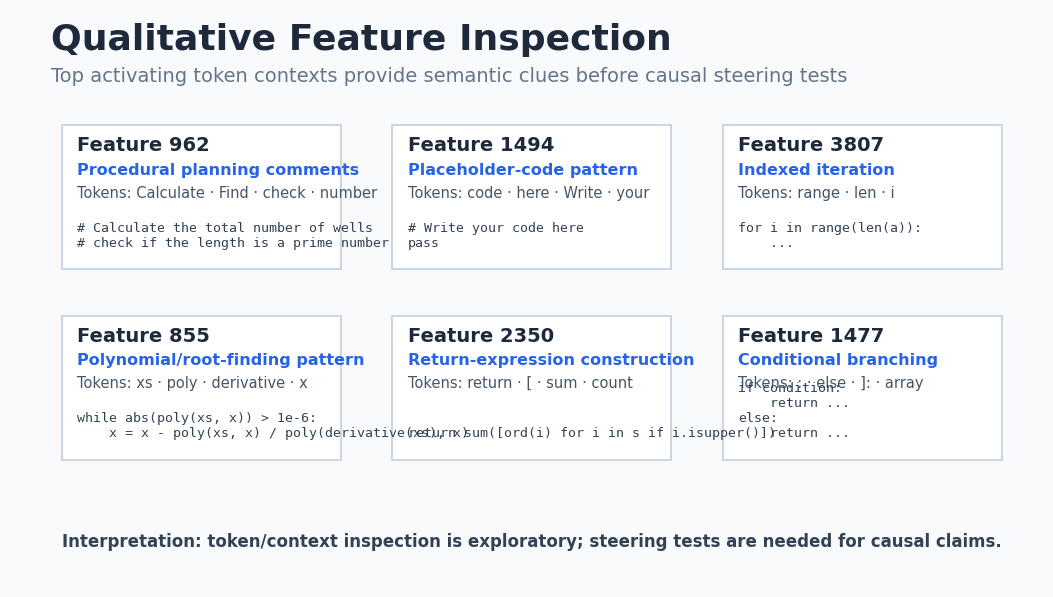

Saved PNG: /content/presentation_assets/qualitative_feature_examples.png
Saved SVG: /content/presentation_assets/qualitative_feature_examples.svg
Copied to gs://data-intelligence-bucket/tests/


In [217]:
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

feature_examples = [
    {
        "feature": 962,
        "label": "Procedural planning comments",
        "tokens": "Calculate · Find · check · number",
        "example": "# Calculate the total number of wells\n# check if the length is a prime number",
    },
    {
        "feature": 1494,
        "label": "Placeholder-code pattern",
        "tokens": "code · here · Write · your",
        "example": "# Write your code here\npass",
    },
    {
        "feature": 3807,
        "label": "Indexed iteration",
        "tokens": "range · len · i",
        "example": "for i in range(len(a)):\n    ...",
    },
    {
        "feature": 855,
        "label": "Polynomial/root-finding pattern",
        "tokens": "xs · poly · derivative · x",
        "example": "while abs(poly(xs, x)) > 1e-6:\n    x = x - poly(xs, x) / poly(derivative(xs), x)",
    },
    {
        "feature": 2350,
        "label": "Return-expression construction",
        "tokens": "return · [ · sum · count",
        "example": "return sum([ord(i) for i in s if i.isupper()])",
    },
    {
        "feature": 1477,
        "label": "Conditional branching",
        "tokens": ": · else · ]: · array",
        "example": "if condition:\n    return ...\nelse:\n    return ...",
    },
]

fig, ax = plt.subplots(figsize=(13.33, 7.5))
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")
ax.axis("off")

ax.text(
    0.04, 0.93,
    "Qualitative Feature Inspection",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
    transform=ax.transAxes,
)

ax.text(
    0.04, 0.875,
    "Top activating token contexts provide semantic clues before causal steering tests",
    fontsize=14,
    color="#64748B",
    transform=ax.transAxes,
)

# layout
x_positions = [0.05, 0.37, 0.69]
y_positions = [0.55, 0.22]

for idx, item in enumerate(feature_examples):
    col = idx % 3
    row = idx // 3
    x = x_positions[col]
    y = y_positions[row]

    # card
    rect = plt.Rectangle(
        (x, y), 0.27, 0.25,
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="#CBD5E1",
        linewidth=1.4,
    )
    ax.add_patch(rect)

    ax.text(
        x + 0.015, y + 0.205,
        f"Feature {item['feature']}",
        fontsize=14,
        fontweight="bold",
        color="#1E293B",
        transform=ax.transAxes,
    )

    ax.text(
        x + 0.015, y + 0.165,
        item["label"],
        fontsize=11.5,
        fontweight="bold",
        color="#2563EB",
        transform=ax.transAxes,
    )

    ax.text(
        x + 0.015, y + 0.125,
        f"Tokens: {item['tokens']}",
        fontsize=10.5,
        color="#475569",
        transform=ax.transAxes,
    )

    ax.text(
        x + 0.015, y + 0.035,
        item["example"],
        fontsize=9.5,
        color="#334155",
        family="monospace",
        transform=ax.transAxes,
        va="bottom",
    )

ax.text(
    0.05, 0.07,
    "Interpretation: token/context inspection is exploratory; steering tests are needed for causal claims.",
    fontsize=12,
    fontweight="bold",
    color="#334155",
    transform=ax.transAxes,
)

png_path = OUT_DIR / "qualitative_feature_examples.png"
svg_path = OUT_DIR / "qualitative_feature_examples.svg"

fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="#F8FAFC")
fig.savefig(svg_path, bbox_inches="tight", facecolor="#F8FAFC")
plt.show()

print("Saved PNG:", png_path)
print("Saved SVG:", svg_path)

try:
    subprocess.run(["gsutil", "cp", str(png_path), "gs://data-intelligence-bucket/tests/"], check=True)
    subprocess.run(["gsutil", "cp", str(svg_path), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)

# 23

In [ ]:
feature_id = 2350
df_2350 = aggregate_feature_by_text(feature_id)

display(
    df_2350[df_2350["source_model"] == "base"]
    .sort_values("max_activation", ascending=False)
    [[
        "task_id",
        "task_label",
        "source_correct",
        "mean_activation",
        "max_activation",
        "p95_activation",
        "p99_activation",
        "active_frac",
        "num_tokens",
    ]]
    .head(30)
)

,task_id,task_label,source_correct,mean_activation,max_activation,p95_activation,p99_activation,active_frac,num_tokens
66,HumanEval/66,both_correct,True,3.876949,8.007746,7.593321,7.924860,1.000000,20
69,HumanEval/69,both_incorrect,False,2.949103,7.850769,5.849461,7.423810,1.000000,62
101,HumanEval/101,merged_only_correct,False,5.197009,7.644068,7.340541,7.583363,1.000000,7
163,HumanEval/163,both_incorrect,False,2.237556,7.598054,4.726621,6.243652,0.977273,132
97,HumanEval/97,both_correct,True,3.822570,7.570771,7.369415,7.530499,1.000000,18
87,HumanEval/87,merged_only_correct,False,2.320031,7.561604,6.513724,7.349561,0.885714,35
133,HumanEval/133,both_incorrect,False,3.649539,7.533180,7.261564,7.478857,1.000000,18
94,HumanEval/94,merged_only_correct,False,5.419850,7.310947,7.206604,7.290078,1.000000,5
108,HumanEval/108,both_incorrect,False,3.185746,7.262096,6.518641,7.112134,1.000000,24
140,HumanEval/140,both_incorrect,False,3.844699,7.228542,6.889382,7.160944,1.000000,22


In [ ]:
def binned_error_rate(df_feat, source_model="base", score_col="max_activation", q=5):
    d = df_feat[df_feat["source_model"] == source_model].copy()
    d["error"] = ~d["source_correct"]

    # Drop duplicates in case quantile bins collapse.
    d["bin"] = pd.qcut(
        d[score_col],
        q=q,
        duplicates="drop",
    )

    out = (
        d.groupby("bin", observed=True)
        .agg(
            n=("task_id", "count"),
            error_rate=("error", "mean"),
            score_min=(score_col, "min"),
            score_median=(score_col, "median"),
            score_max=(score_col, "max"),
            examples=("task_id", lambda x: list(x)[:8]),
        )
        .reset_index()
    )

    return out


for col in ["mean_activation", "max_activation", "p95_activation", "p99_activation", "active_frac"]:
    print("\n" + "=" * 100)
    print("Feature 2350 | base |", col)
    display(binned_error_rate(df_2350, source_model="base", score_col=col, q=5))


Feature 2350 | base | mean_activation


,bin,n,error_rate,score_min,score_median,score_max,examples
0,"(0.854, 1.874]",33,0.515152,0.854702,1.717156,1.872996,"[HumanEval/3, HumanEval/8, HumanEval/12, Human..."
1,"(1.874, 2.283]",33,0.454545,1.873879,2.085754,2.280977,"[HumanEval/5, HumanEval/6, HumanEval/10, Human..."
2,"(2.283, 2.684]",32,0.625000,2.293139,2.450559,2.673771,"[HumanEval/4, HumanEval/20, HumanEval/23, Huma..."
3,"(2.684, 3.756]",33,0.575758,2.685977,3.168636,3.729844,"[HumanEval/0, HumanEval/7, HumanEval/9, HumanE..."
4,"(3.756, 5.42]",33,0.787879,3.795127,4.191180,5.419850,"[HumanEval/1, HumanEval/2, HumanEval/16, Human..."



Feature 2350 | base | max_activation


,bin,n,error_rate,score_min,score_median,score_max,examples
0,"(2.8360000000000003, 5.252]",33,0.272727,2.836860,4.883984,5.232295,"[HumanEval/2, HumanEval/3, HumanEval/8, HumanE..."
1,"(5.252, 5.85]",33,0.393939,5.264625,5.480724,5.847942,"[HumanEval/4, HumanEval/10, HumanEval/12, Huma..."
2,"(5.85, 6.237]",32,0.750000,5.859263,6.041873,6.230960,"[HumanEval/0, HumanEval/1, HumanEval/5, HumanE..."
3,"(6.237, 6.595]",33,0.757576,6.238584,6.398821,6.591195,"[HumanEval/6, HumanEval/7, HumanEval/22, Human..."
4,"(6.595, 8.008]",33,0.787879,6.601095,6.852741,8.007746,"[HumanEval/30, HumanEval/42, HumanEval/66, Hum..."



Feature 2350 | base | p95_activation


,bin,n,error_rate,score_min,score_median,score_max,examples
0,"(2.442, 4.015]",33,0.393939,2.443253,3.699494,4.005483,"[HumanEval/3, HumanEval/8, HumanEval/13, Human..."
1,"(4.015, 4.62]",33,0.484848,4.021558,4.320907,4.602875,"[HumanEval/0, HumanEval/10, HumanEval/12, Huma..."
2,"(4.62, 5.276]",32,0.593750,4.690584,5.028129,5.262577,"[HumanEval/2, HumanEval/4, HumanEval/5, HumanE..."
3,"(5.276, 5.993]",33,0.787879,5.279065,5.640398,5.990294,"[HumanEval/1, HumanEval/9, HumanEval/15, Human..."
4,"(5.993, 7.593]",33,0.696970,5.996881,6.513724,7.593321,"[HumanEval/7, HumanEval/16, HumanEval/22, Huma..."



Feature 2350 | base | p99_activation


,bin,n,error_rate,score_min,score_median,score_max,examples
0,"(2.7110000000000003, 4.89]",33,0.303030,2.712117,4.602395,4.886207,"[HumanEval/3, HumanEval/8, HumanEval/10, Human..."
1,"(4.89, 5.417]",33,0.424242,4.891745,5.165102,5.413436,"[HumanEval/2, HumanEval/4, HumanEval/6, HumanE..."
2,"(5.417, 5.852]",32,0.687500,5.428855,5.696177,5.847841,"[HumanEval/0, HumanEval/5, HumanEval/9, HumanE..."
3,"(5.852, 6.418]",33,0.787879,5.853542,6.125209,6.410573,"[HumanEval/1, HumanEval/15, HumanEval/16, Huma..."
4,"(6.418, 7.925]",33,0.757576,6.429225,6.727952,7.924860,"[HumanEval/7, HumanEval/22, HumanEval/30, Huma..."



Feature 2350 | base | active_frac


,bin,n,error_rate,score_min,score_median,score_max,examples
0,"(0.759, 0.926]",33,0.545455,0.760417,0.890625,0.925000,"[HumanEval/3, HumanEval/12, HumanEval/14, Huma..."
1,"(0.926, 0.968]",34,0.617647,0.927419,0.947368,0.968254,"[HumanEval/6, HumanEval/8, HumanEval/10, Human..."
2,"(0.968, 1.0]",97,0.597938,0.968750,1.000000,1.000000,"[HumanEval/0, HumanEval/1, HumanEval/2, HumanE..."


In [ ]:
random_features = np.random.default_rng(0).choice(d_hidden, size=10, replace=False)

baseline_rows = []

for feat in random_features:
    df_tmp = aggregate_feature_by_text(int(feat))
    d = df_tmp[df_tmp["source_model"] == "base"].copy()
    y_error = (~d["source_correct"]).astype(int).values

    for col in ["mean_activation", "max_activation", "p95_activation", "p99_activation"]:
        auc = safe_auc(y_error, d[col].values)
        baseline_rows.append({
            "feature": int(feat),
            "score_col": col,
            "auc_predict_error": auc,
        })

df_baseline_auc = pd.DataFrame(baseline_rows)

display(df_baseline_auc.sort_values("auc_predict_error", ascending=False))
print("2350 AUCs:")
display(
    df_feature_error_corr[
        (df_feature_error_corr["feature"] == 2350) &
        (df_feature_error_corr["source_model"] == "base")
    ].sort_values("auc_predict_error", ascending=False)
)

,feature,score_col,auc_predict_error
33,717,max_activation,0.502000
32,717,mean_activation,0.501385
35,717,p99_activation,0.501385
0,3476,mean_activation,0.500000
4,3331,mean_activation,0.500000
1,3476,max_activation,0.500000
2,3476,p95_activation,0.500000
3,3476,p99_activation,0.500000
7,3331,p99_activation,0.500000
6,3331,p95_activation,0.500000


2350 AUCs:


,feature,source_model,score_col,n_texts,error_rate,mean_score_correct,mean_score_error,diff_error_minus_correct,auc_predict_error,pointbiserial_corr_with_error,pvalue
241,2350,base,max_activation,164,0.591463,5.532943,6.199669,0.666726,0.721342,0.375684,7.154863e-07
243,2350,base,p99_activation,164,0.591463,5.269740,5.900850,0.631110,0.707801,0.344503,6.269048e-06
242,2350,base,p95_activation,164,0.591463,4.699483,5.237336,0.537853,0.647946,0.247682,1.385785e-03
240,2350,base,mean_activation,164,0.591463,2.471115,2.911006,0.439891,0.618403,0.220257,4.597172e-03
244,2350,base,active_frac,164,0.591463,0.960930,0.965187,0.004257,0.528312,0.043573,5.795773e-01


In [ ]:
def show_top_texts_for_feature(feature_id, source_model="base", score_col="max_activation", top_k=20):
    df_feat = aggregate_feature_by_text(feature_id)
    d = df_feat[df_feat["source_model"] == source_model].copy()
    d = d.sort_values(score_col, ascending=False).head(top_k)

    for _, row in d.iterrows():
        task_id = row["task_id"]
        source = row["source_model"]

        if source == "base":
            r = base_by_task[task_id]
        else:
            r = merged_by_task[task_id]

        print("=" * 120)
        print(
            "feature:", feature_id,
            "| task:", task_id,
            "| label:", row["task_label"],
            "| correct:", row["source_correct"],
            "|", score_col, "=", row[score_col],
        )
        print("\n--- candidate_code ---")
        print(r["candidate_code"][:1500])


show_top_texts_for_feature(
    feature_id=2350,
    source_model="base",
    score_col="max_activation",
    top_k=15,
)

feature: 2350 | task: HumanEval/66 | label: both_correct | correct: True | max_activation = 8.007745742797852

--- candidate_code ---

def digitSum(s):
    """Task
    Write a function that takes a string as input and returns the sum of the upper characters only'
    ASCII codes.

    Examples:
        digitSum("") => 0
        digitSum("abAB") => 131
        digitSum("abcCd") => 67
        digitSum("helloE") => 69
        digitSum("woArBld") => 131
        digitSum("aAaaaXa") => 153
    """
    return sum([ord(i) for i in s if i.isupper()])

feature: 2350 | task: HumanEval/69 | label: both_incorrect | correct: False | max_activation = 7.850768566131592

--- candidate_code ---

def search(lst):
    '''
    You are given a non-empty list of positive integers. Return the greatest integer that is greater than 
    zero, and has a frequency greater than or equal to the value of the integer itself. 
    The frequency of an integer is the number of times it appears in the list.
    If no suc

In [ ]:
df_2350 = aggregate_feature_by_text(2350)

paired_2350 = (
    df_2350
    .pivot_table(
        index="task_id",
        columns="source_model",
        values=["mean_activation", "max_activation", "p95_activation", "p99_activation"],
        aggfunc="first"
    )
)

paired_2350.columns = [f"{metric}_{model}" for metric, model in paired_2350.columns]
paired_2350 = paired_2350.reset_index()

labels_small = df_labels[["task_id", "label"]].copy()
paired_2350 = paired_2350.merge(labels_small, on="task_id", how="left")

display(
    paired_2350[paired_2350["label"] == "merged_only_correct"]
    .assign(
        delta_max=lambda d: d["max_activation_base"] - d["max_activation_merged"],
        delta_p99=lambda d: d["p99_activation_base"] - d["p99_activation_merged"],
        delta_mean=lambda d: d["mean_activation_base"] - d["mean_activation_merged"],
    )
    .sort_values("delta_max", ascending=False)
    .head(30)
)

,task_id,max_activation_base,max_activation_merged,mean_activation_base,mean_activation_merged,p95_activation_base,p95_activation_merged,p99_activation_base,p99_activation_merged,label,delta_max,delta_p99,delta_mean


In [ ]:
# Stering

# steering


In [ ]:
# Use correctness labels, not performance/time labels.

correctness_path = EVAL_DIR / "task_correctness_labels_v3.json"

if "df_correctness" not in globals():
    with open(correctness_path) as f:
        correctness_labels = json.load(f)

    df_correctness = pd.DataFrame(correctness_labels)

print(df_correctness["label"].value_counts())

target_task_ids = (
    df_correctness[df_correctness["label"] == "merged_only_correct"]["task_id"]
    .tolist()
)

target_examples = [
    ex for ex in examples
    if ex["task_id"] in set(target_task_ids)
]

print("Target tasks:", len(target_examples))
print(target_task_ids[:20])


label
both_correct           64
merged_only_correct    54
both_incorrect         43
base_only_correct       3
Name: count, dtype: int64
Target tasks: 54
['HumanEval/5', 'HumanEval/10', 'HumanEval/33', 'HumanEval/36', 'HumanEval/37', 'HumanEval/41', 'HumanEval/49', 'HumanEval/56', 'HumanEval/62', 'HumanEval/64', 'HumanEval/65', 'HumanEval/73', 'HumanEval/74', 'HumanEval/77', 'HumanEval/78', 'HumanEval/80', 'HumanEval/82', 'HumanEval/85', 'HumanEval/86', 'HumanEval/87']


In [ ]:
STEERING_MAX_TASKS = 20
target_examples_steering = target_examples[:STEERING_MAX_TASKS]

print("Steering eval tasks:", len(target_examples_steering))

Steering eval tasks: 20


In [ ]:
df_task_correctness = df_correctness.copy()

In [ ]:
# Features selected from the previous interpretability analysis.
# 2350: high-activation shortcut / compact-return pattern.
# 1494: placeholder / "Write your code here" / incomplete solution pattern.
# 962: procedural comment-plan pattern associated with incorrect outputs.

STEERING_FEATURES = [2350, 1494, 962]

# Negative steering means subtracting the decoder direction.
# Start small because some features, especially 2350, are dense and can be useful in correct code too.
STEERING_ALPHAS = [0.0, -0.10, -0.25, -0.50, -1.00]

print("features:", STEERING_FEATURES)
print("alphas:", STEERING_ALPHAS)

features: [2350, 1494, 962]
alphas: [0.0, -0.1, -0.25, -0.5, -1.0]


In [ ]:
def feature_scale_from_Z(feature_id, percentile=99.0):
    """
    Estimate a natural activation scale for a feature.
    We use only positive activations and take a high percentile.
    """

    vals = Z[:, feature_id]
    vals = vals[vals > 0]

    if len(vals) == 0:
        return 1.0

    return float(np.percentile(vals, percentile))


feature_scales = {}

for feat in STEERING_FEATURES:
    feature_scales[feat] = {
        "p95": feature_scale_from_Z(feat, 95),
        "p99": feature_scale_from_Z(feat, 99),
        "max": float(Z[:, feat].max()),
    }

feature_scales

{2350: {'p95': 4.99039363861084,
  'p99': 6.238748550415039,
  'max': 8.007745742797852},
 1494: {'p95': 26.112550735473633,
  'p99': 26.562763214111328,
  'max': 26.563526153564453},
 962: {'p95': 25.059551239013672,
  'p99': 26.076923370361328,
  'max': 26.55257797241211}}

In [ ]:
STEERING_SCALE_KIND = "p99"

In [ ]:
def get_decoder_vector(cc_model, feature_id, side="base"):
    """
    Return the decoder vector for a CrossCoder feature.

    side="base" uses the base decoder direction.
    side="merged" uses the merged decoder direction.
    """

    if side == "base":
        # decoder_base.weight shape is usually [d_model, d_hidden]
        vec = cc_model.decoder_base.weight[:, feature_id].detach().float()
    elif side == "merged":
        vec = cc_model.decoder_merged.weight[:, feature_id].detach().float()
    else:
        raise ValueError("side must be 'base' or 'merged'")

    return vec


for feat in STEERING_FEATURES:
    v = get_decoder_vector(cc_model, feat, side="base")
    print(feat, v.shape, float(v.norm()))

2350 torch.Size([4096]) 1.4015746116638184
1494 torch.Size([4096]) 1.003733515739441
962 torch.Size([4096]) 1.2523469924926758


In [ ]:
def get_transformer_layers(model):
    """
    Try to find the transformer block list for common causal LM architectures.
    DeepSeek-Coder is LLaMA-like, so model.model.layers should usually work.
    """

    candidates = [
        ("model.layers", lambda m: m.model.layers),
        ("model.model.layers", lambda m: m.model.model.layers),
        ("transformer.h", lambda m: m.transformer.h),
        ("gpt_neox.layers", lambda m: m.gpt_neox.layers),
    ]

    for name, getter in candidates:
        try:
            layers = getter(model)
            print("Using layers at:", name)
            return layers
        except Exception:
            pass

    raise RuntimeError("Could not find transformer layers for this model.")


def get_layer_module(model, layer_id):
    layers = get_transformer_layers(model)
    print("Number of layers:", len(layers))
    return layers[layer_id]

In [ ]:
from contextlib import contextmanager

@contextmanager
def steering_hook(model, layer_id, steering_vector, alpha=0.0, apply_to_last_token_only=True):
    """
    Add a steering vector to the hidden state at a given layer during generation.

    alpha controls intervention strength.
    alpha < 0 subtracts the direction.
    alpha > 0 adds the direction.

    We apply it to the last token only. This affects next-token prediction while
    avoiding rewriting all prompt token states.
    """

    if alpha == 0.0:
        yield
        return

    layer = get_layer_module(model, layer_id)

    steering_vector = steering_vector.to(model.device)
    steering_vector = steering_vector.to(dtype=torch.float16)

    def hook_fn(module, inputs, output):
        # Some transformer blocks return a tensor; others return a tuple.
        if isinstance(output, tuple):
            hidden = output[0]
            rest = output[1:]
        else:
            hidden = output
            rest = None

        vec = alpha * steering_vector.view(1, 1, -1)

        if apply_to_last_token_only:
            hidden = hidden.clone()
            hidden[:, -1:, :] = hidden[:, -1:, :] + vec
        else:
            hidden = hidden + vec

        if rest is None:
            return hidden

        return (hidden, *rest)

    handle = layer.register_forward_hook(hook_fn)

    try:
        yield
    finally:
        handle.remove()

In [ ]:
@torch.no_grad()
def generate_completion_steered(
    model,
    tokenizer,
    prompt,
    feature_id=None,
    alpha=0.0,
    scale=1.0,
    decoder_side="base",
    seed=0,
    max_new_tokens=None,
    do_sample=False,
):
    """
    Generate code with optional CrossCoder decoder-vector steering.

    alpha is multiplied by scale:
        hidden' = hidden + alpha * scale * decoder_vector

    For harmful/error-associated features, use negative alpha.
    """

    if max_new_tokens is None:
        max_new_tokens = MAX_NEW_TOKENS

    set_seed(seed)
    torch.manual_seed(seed)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
    ).to(model.device)

    if feature_id is None or alpha == 0.0:
        steering_vector = None
        effective_alpha = 0.0
    else:
        steering_vector = get_decoder_vector(
            cc_model,
            feature_id=feature_id,
            side=decoder_side,
        )
        effective_alpha = alpha * scale

    with steering_hook(
        model=model,
        layer_id=LAYER_ID,
        steering_vector=steering_vector if steering_vector is not None else torch.zeros(d_model),
        alpha=effective_alpha,
        apply_to_last_token_only=True,
    ):
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=TEMPERATURE if do_sample else None,
            top_p=TOP_P if do_sample else None,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    gen_ids = output_ids[0, inputs["input_ids"].shape[1]:]
    completion = tokenizer.decode(gen_ids, skip_special_tokens=True)

    return completion

In [ ]:
def generate_and_evaluate_one_steered(
    model,
    tokenizer,
    ex,
    feature_id=None,
    alpha=0.0,
    scale=1.0,
    decoder_side="base",
    seed=0,
    do_sample=False,
):
    prompt = ex["prompt"]
    test_code = ex["test"]
    entry_point = ex["entry_point"]

    completion = generate_completion_steered(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        feature_id=feature_id,
        alpha=alpha,
        scale=scale,
        decoder_side=decoder_side,
        seed=seed,
        do_sample=do_sample,
    )

    candidate_code = make_candidate_code(
        prompt=prompt,
        completion=completion,
        entry_point=entry_point,
    )

    syntax_ok, syntax_error = quick_syntax_check(candidate_code)

    if syntax_ok:
        eval_result = run_candidate_in_subprocess(
            candidate_code=candidate_code,
            test_code=test_code,
            entry_point=entry_point,
            repeats=PERF_REPEATS,
            timeout=PERF_TIMEOUT_SECONDS,
        )
    else:
        eval_result = {
            "correct": False,
            "times": [],
            "error": syntax_error,
        }

    return {
        "task_id": ex["task_id"],
        "entry_point": entry_point,
        "feature_id": feature_id,
        "alpha": alpha,
        "scale": scale,
        "decoder_side": decoder_side,
        "seed": seed,
        "raw_completion": completion,
        "candidate_code": candidate_code,
        "syntax_ok": syntax_ok,
        "correct": bool(eval_result["correct"]),
        "times": eval_result["times"],
        "median_time": float(np.median(eval_result["times"])) if eval_result["times"] else None,
        "error": eval_result["error"],
    }

In [ ]:
STEERING_RESULTS_PATH = STEER_DIR / "base_negative_steering_smoke_v1.json"

base_model, base_tokenizer = load_quantized_model(BASE_MODEL)

steering_rows = []

for feature_id in STEERING_FEATURES:
    scale = feature_scales[feature_id][STEERING_SCALE_KIND]

    for alpha in STEERING_ALPHAS:
        print("\n" + "=" * 120)
        print("Feature:", feature_id, "alpha:", alpha, "scale:", scale)

        for task_idx, ex in enumerate(tqdm(target_examples_steering, desc=f"feat={feature_id} alpha={alpha}")):
            seed = 777000 + task_idx

            row = generate_and_evaluate_one_steered(
                model=base_model,
                tokenizer=base_tokenizer,
                ex=ex,
                feature_id=feature_id if alpha != 0.0 else None,
                alpha=alpha,
                scale=scale,
                decoder_side="base",
                seed=seed,
                do_sample=False,
            )

            row["target_group"] = "merged_only_correct"
            row["scale_kind"] = STEERING_SCALE_KIND
            row["model_name"] = BASE_MODEL
            row["model_label"] = "base"

            steering_rows.append(row)

            print(
                row["task_id"],
                "feat", feature_id,
                "alpha", alpha,
                "syntax", row["syntax_ok"],
                "correct", row["correct"],
            )

        with open(STEERING_RESULTS_PATH, "w") as f:
            json.dump(steering_rows, f, indent=2)

del base_model
gc.collect()
torch.cuda.empty_cache()

print("Saved:", STEERING_RESULTS_PATH)

config.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

...

Using layers at: model.layers
Number of layers: 32
HumanEval/5 feat 962 alpha -0.25 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/10 feat 962 alpha -0.25 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/33 feat 962 alpha -0.25 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/36 feat 962 alpha -0.25 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/37 feat 962 alpha -0.25 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/41 feat 962 alpha -0.25 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/49 feat 962 alpha -0.25 syntax False correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/56 feat 962 alpha -0.25 syntax True correct True
Using layers at: model.layers
Number of layers: 32
HumanEval/62 feat 962 alpha -0.25 syntax True correct False
Us

feat=962 alpha=-0.5:   0%|          | 0/20 [00:00<?, ?it/s]

Using layers at: model.layers
Number of layers: 32
HumanEval/5 feat 962 alpha -0.5 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/10 feat 962 alpha -0.5 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/33 feat 962 alpha -0.5 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/36 feat 962 alpha -0.5 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/37 feat 962 alpha -0.5 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/41 feat 962 alpha -0.5 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/49 feat 962 alpha -0.5 syntax True correct True
Using layers at: model.layers
Number of layers: 32
HumanEval/56 feat 962 alpha -0.5 syntax True correct True
Using layers at: model.layers
Number of layers: 32
HumanEval/62 feat 962 alpha -0.5 syntax True correct False
Using layers 

feat=962 alpha=-1.0:   0%|          | 0/20 [00:00<?, ?it/s]

Using layers at: model.layers
Number of layers: 32
HumanEval/5 feat 962 alpha -1.0 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/10 feat 962 alpha -1.0 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/33 feat 962 alpha -1.0 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/36 feat 962 alpha -1.0 syntax True correct True
Using layers at: model.layers
Number of layers: 32
HumanEval/37 feat 962 alpha -1.0 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/41 feat 962 alpha -1.0 syntax True correct False
Using layers at: model.layers
Number of layers: 32
HumanEval/49 feat 962 alpha -1.0 syntax True correct True
Using layers at: model.layers
Number of layers: 32
HumanEval/56 feat 962 alpha -1.0 syntax True correct True
Using layers at: model.layers
Number of layers: 32
HumanEval/62 feat 962 alpha -1.0 syntax True correct False
Using layers a

In [ ]:
with open(STEERING_RESULTS_PATH) as f:
    steering_rows = json.load(f)

df_steer = pd.DataFrame(steering_rows)

summary_steer = (
    df_steer
    .groupby(["feature_id", "alpha"])
    .agg(
        n=("task_id", "count"),
        syntax_rate=("syntax_ok", "mean"),
        correct_rate=("correct", "mean"),
        correct_count=("correct", "sum"),
    )
    .reset_index()
    .sort_values(["feature_id", "alpha"])
)

display(summary_steer)

,feature_id,alpha,n,syntax_rate,correct_rate,correct_count
0,962.0,-1.00,20,1.00,0.20,4
1,962.0,-0.50,20,1.00,0.15,3
2,962.0,-0.25,20,0.95,0.10,2
3,962.0,-0.10,20,0.90,0.05,1
4,1494.0,-1.00,20,0.95,0.15,3
5,1494.0,-0.50,20,0.95,0.15,3
6,1494.0,-0.25,20,0.95,0.05,1
7,1494.0,-0.10,20,0.95,0.05,1
8,2350.0,-1.00,20,0.95,0.10,2
9,2350.0,-0.50,20,0.90,0.05,1


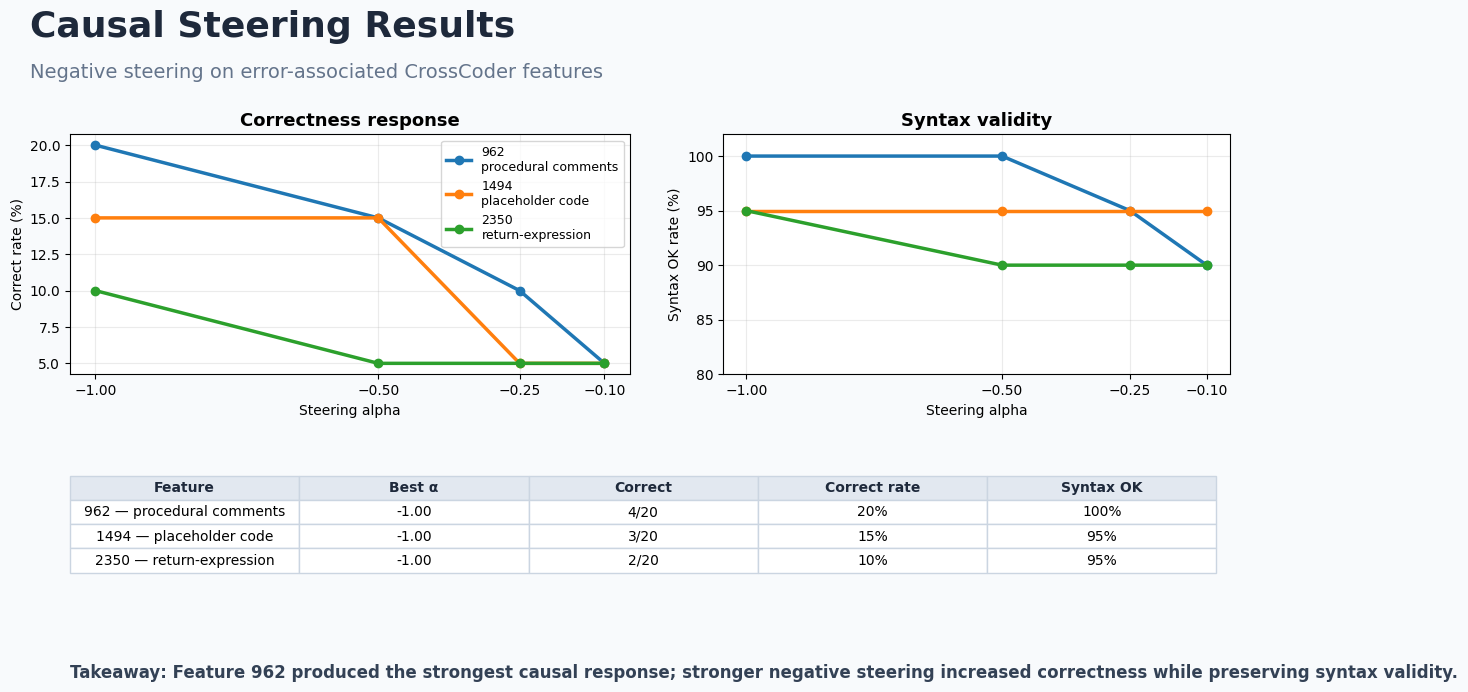

Saved PNG: /content/presentation_assets/causal_steering_results.png
Saved SVG: /content/presentation_assets/causal_steering_results.svg
Copied to gs://data-intelligence-bucket/tests/


In [218]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

df_steering_summary = pd.DataFrame([
    {"feature_id": 962, "alpha": -1.00, "n": 20, "syntax_rate": 1.00, "correct_rate": 0.20, "correct_count": 4},
    {"feature_id": 962, "alpha": -0.50, "n": 20, "syntax_rate": 1.00, "correct_rate": 0.15, "correct_count": 3},
    {"feature_id": 962, "alpha": -0.25, "n": 20, "syntax_rate": 0.95, "correct_rate": 0.10, "correct_count": 2},
    {"feature_id": 962, "alpha": -0.10, "n": 20, "syntax_rate": 0.90, "correct_rate": 0.05, "correct_count": 1},
    {"feature_id": 1494, "alpha": -1.00, "n": 20, "syntax_rate": 0.95, "correct_rate": 0.15, "correct_count": 3},
    {"feature_id": 1494, "alpha": -0.50, "n": 20, "syntax_rate": 0.95, "correct_rate": 0.15, "correct_count": 3},
    {"feature_id": 1494, "alpha": -0.25, "n": 20, "syntax_rate": 0.95, "correct_rate": 0.05, "correct_count": 1},
    {"feature_id": 1494, "alpha": -0.10, "n": 20, "syntax_rate": 0.95, "correct_rate": 0.05, "correct_count": 1},
    {"feature_id": 2350, "alpha": -1.00, "n": 20, "syntax_rate": 0.95, "correct_rate": 0.10, "correct_count": 2},
    {"feature_id": 2350, "alpha": -0.50, "n": 20, "syntax_rate": 0.90, "correct_rate": 0.05, "correct_count": 1},
    {"feature_id": 2350, "alpha": -0.25, "n": 20, "syntax_rate": 0.90, "correct_rate": 0.05, "correct_count": 1},
    {"feature_id": 2350, "alpha": -0.10, "n": 20, "syntax_rate": 0.90, "correct_rate": 0.05, "correct_count": 1},
])

feature_labels = {
    962: "962\nprocedural comments",
    1494: "1494\nplaceholder code",
    2350: "2350\nreturn-expression"
}

fig = plt.figure(figsize=(13.33, 7.5))
fig.patch.set_facecolor("#F8FAFC")

fig.text(
    0.04, 0.93,
    "Causal Steering Results",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
    ha="left"
)

fig.text(
    0.04, 0.875,
    "Negative steering on error-associated CrossCoder features",
    fontsize=14,
    color="#64748B",
    ha="left"
)

# Correctness chart
ax1 = fig.add_axes([0.07, 0.48, 0.42, 0.32])

for feature_id, d in df_steering_summary.groupby("feature_id"):
    d = d.sort_values("alpha")
    ax1.plot(
        d["alpha"],
        d["correct_rate"] * 100,
        marker="o",
        linewidth=2.5,
        label=feature_labels[int(feature_id)]
    )

ax1.set_title("Correctness response", fontsize=13, fontweight="bold")
ax1.set_xlabel("Steering alpha")
ax1.set_ylabel("Correct rate (%)")
ax1.set_xticks([-1.0, -0.5, -0.25, -0.1])
ax1.grid(True, alpha=0.25)
ax1.legend(fontsize=9)

# Syntax chart
ax2 = fig.add_axes([0.56, 0.48, 0.38, 0.32])

for feature_id, d in df_steering_summary.groupby("feature_id"):
    d = d.sort_values("alpha")
    ax2.plot(
        d["alpha"],
        d["syntax_rate"] * 100,
        marker="o",
        linewidth=2.5,
        label=feature_labels[int(feature_id)]
    )

ax2.set_title("Syntax validity", fontsize=13, fontweight="bold")
ax2.set_xlabel("Steering alpha")
ax2.set_ylabel("Syntax OK rate (%)")
ax2.set_xticks([-1.0, -0.5, -0.25, -0.1])
ax2.set_ylim(80, 102)
ax2.grid(True, alpha=0.25)

# Summary table
best = (
    df_steering_summary
    .sort_values(["correct_rate", "syntax_rate"], ascending=False)
    .groupby("feature_id", as_index=False)
    .head(1)
    .sort_values("correct_rate", ascending=False)
    .copy()
)

best["feature"] = best["feature_id"].map({
    962: "962 — procedural comments",
    1494: "1494 — placeholder code",
    2350: "2350 — return-expression"
})
best["correct"] = best["correct_count"].astype(str) + "/20"
best["correct_rate"] = (best["correct_rate"] * 100).map(lambda x: f"{x:.0f}%")
best["syntax_rate"] = (best["syntax_rate"] * 100).map(lambda x: f"{x:.0f}%")
best["alpha"] = best["alpha"].map(lambda x: f"{x:.2f}")

table_df = best[["feature", "alpha", "correct", "correct_rate", "syntax_rate"]].rename(columns={
    "feature": "Feature",
    "alpha": "Best α",
    "correct": "Correct",
    "correct_rate": "Correct rate",
    "syntax_rate": "Syntax OK"
})

ax_tbl = fig.add_axes([0.07, 0.18, 0.86, 0.20])
ax_tbl.axis("off")

tbl = ax_tbl.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 1.45)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#CBD5E1")
    if row == 0:
        cell.set_text_props(fontweight="bold", color="#1E293B")
        cell.set_facecolor("#E2E8F0")
    else:
        cell.set_facecolor("#FFFFFF")

fig.text(
    0.07, 0.075,
    "Takeaway: Feature 962 produced the strongest causal response; stronger negative steering increased correctness while preserving syntax validity.",
    fontsize=12,
    color="#334155",
    fontweight="bold",
    ha="left"
)

png_path = OUT_DIR / "causal_steering_results.png"
svg_path = OUT_DIR / "causal_steering_results.svg"

fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="#F8FAFC")
fig.savefig(svg_path, bbox_inches="tight", facecolor="#F8FAFC")
plt.show()

print("Saved PNG:", png_path)
print("Saved SVG:", svg_path)

try:
    subprocess.run(["gsutil", "cp", str(png_path), "gs://data-intelligence-bucket/tests/"], check=True)
    subprocess.run(["gsutil", "cp", str(svg_path), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)

In [155]:
feature_id = 962

df_feat = df_steer[df_steer["feature_id"].eq(feature_id)].copy()

print("Alphas disponíveis para feature", feature_id)
print(sorted(df_feat["alpha"].dropna().unique()))

print("\nContagem por alpha:")
display(df_feat.groupby("alpha")["task_id"].nunique().reset_index(name="n_tasks"))

print("\nTask ids por alpha:")
display(
    df_feat.groupby("alpha")["task_id"]
    .apply(lambda s: sorted(s.unique()))
    .reset_index(name="task_ids")
)

Alphas disponíveis para feature 962
[np.float64(-1.0), np.float64(-0.5), np.float64(-0.25), np.float64(-0.1)]

Contagem por alpha:


,alpha,n_tasks
0,-1.00,20
1,-0.50,20
2,-0.25,20
3,-0.10,20



Task ids por alpha:


,alpha,task_ids
0,-1.00,"[HumanEval/10, HumanEval/33, HumanEval/36, Hum..."
1,-0.50,"[HumanEval/10, HumanEval/33, HumanEval/36, Hum..."
2,-0.25,"[HumanEval/10, HumanEval/33, HumanEval/36, Hum..."
3,-0.10,"[HumanEval/10, HumanEval/33, HumanEval/36, Hum..."


In [156]:
feature_id = 962
alpha_a = 0.0
alpha_b = -1.0

df_feat = df_steer[df_steer["feature_id"].eq(feature_id)].copy()

# evita problemas de float tipo -1 vs -1.0
df_feat["alpha_round"] = df_feat["alpha"].astype(float).round(4)

improved = (
    df_feat[
        df_feat["alpha_round"].eq(alpha_b) &
        df_feat["correct"].eq(True)
    ]["task_id"]
    .unique()
    .tolist()
)

gains = []

for task_id in improved:
    rows0 = df_feat[
        df_feat["task_id"].eq(task_id) &
        df_feat["alpha_round"].eq(alpha_a)
    ]

    rowsb = df_feat[
        df_feat["task_id"].eq(task_id) &
        df_feat["alpha_round"].eq(alpha_b)
    ]

    if rows0.empty or rowsb.empty:
        gains.append({
            "task_id": task_id,
            "has_alpha0": not rows0.empty,
            "has_alpha_minus1": not rowsb.empty,
            "alpha0_syntax": None,
            "alpha0_correct": None,
            "alpha0_error": None,
            "alpha_minus1_syntax": rowsb.iloc[0]["syntax_ok"] if not rowsb.empty else None,
            "alpha_minus1_correct": rowsb.iloc[0]["correct"] if not rowsb.empty else None,
            "alpha_minus1_error": rowsb.iloc[0]["error"] if not rowsb.empty else None,
        })
        continue

    row0 = rows0.iloc[0]
    rowb = rowsb.iloc[0]

    gains.append({
        "task_id": task_id,
        "has_alpha0": True,
        "has_alpha_minus1": True,
        "alpha0_syntax": row0["syntax_ok"],
        "alpha0_correct": row0["correct"],
        "alpha0_error": row0["error"],
        "alpha_minus1_syntax": rowb["syntax_ok"],
        "alpha_minus1_correct": rowb["correct"],
        "alpha_minus1_error": rowb["error"],
    })

df_gains = pd.DataFrame(gains)
display(df_gains)

real_gains = df_gains[
    df_gains["has_alpha0"].eq(True) &
    df_gains["alpha0_correct"].eq(False) &
    df_gains["alpha_minus1_correct"].eq(True)
]

display(real_gains)
print("Correct at alpha=-1:", len(df_gains))
print("Real gains over alpha=0:", len(real_gains))
print("Missing alpha=0 comparisons:", (~df_gains["has_alpha0"]).sum())

,task_id,has_alpha0,has_alpha_minus1,alpha0_syntax,alpha0_correct,alpha0_error,alpha_minus1_syntax,alpha_minus1_correct,alpha_minus1_error
0,HumanEval/36,False,True,None,None,None,True,True,None
1,HumanEval/49,False,True,None,None,None,True,True,None
2,HumanEval/56,False,True,None,None,None,True,True,None
3,HumanEval/78,False,True,None,None,None,True,True,None


,task_id,has_alpha0,has_alpha_minus1,alpha0_syntax,alpha0_correct,alpha0_error,alpha_minus1_syntax,alpha_minus1_correct,alpha_minus1_error


Correct at alpha=-1: 4
Real gains over alpha=0: 0
Missing alpha=0 comparisons: 4


In [157]:
feature_id = 962
alpha_b = -1.0

df_feat = df_steer[df_steer["feature_id"].eq(feature_id)].copy()
df_feat["alpha_round"] = df_feat["alpha"].astype(float).round(4)

correct_minus1 = (
    df_feat[
        df_feat["alpha_round"].eq(alpha_b) &
        df_feat["correct"].eq(True)
    ][["task_id", "syntax_ok", "correct", "error", "candidate_code"]]
    .rename(columns={
        "syntax_ok": "steer_minus1_syntax",
        "correct": "steer_minus1_correct",
        "error": "steer_minus1_error",
        "candidate_code": "steer_minus1_code",
    })
)

base_compare = (
    df_base[["task_id", "syntax_ok", "correct", "error", "candidate_code"]]
    .rename(columns={
        "syntax_ok": "base_syntax",
        "correct": "base_correct",
        "error": "base_error",
        "candidate_code": "base_code",
    })
)

df_minus1_vs_base = correct_minus1.merge(base_compare, on="task_id", how="left")

df_minus1_vs_base["gain_over_base"] = (
    df_minus1_vs_base["base_correct"].eq(False) &
    df_minus1_vs_base["steer_minus1_correct"].eq(True)
)

display(
    df_minus1_vs_base[
        [
            "task_id",
            "base_syntax",
            "base_correct",
            "steer_minus1_syntax",
            "steer_minus1_correct",
            "gain_over_base",
            "base_error",
            "steer_minus1_error",
        ]
    ]
)

print("Correct at alpha=-1:", len(df_minus1_vs_base))
print("Gains over original base:", df_minus1_vs_base["gain_over_base"].sum())

,task_id,base_syntax,base_correct,steer_minus1_syntax,steer_minus1_correct,gain_over_base,base_error,steer_minus1_error
0,HumanEval/36,True,False,True,True,True,AssertionError()\nTraceback (most recent call ...,None
1,HumanEval/49,False,False,True,True,True,"SyntaxError('invalid syntax', ('<unknown>', 22...",None
2,HumanEval/56,True,False,True,True,True,AssertionError()\nTraceback (most recent call ...,None
3,HumanEval/78,True,False,True,True,True,AssertionError('Fifth test error: 7')\nTraceba...,None


Correct at alpha=-1: 4
Gains over original base: 4


In [158]:
from IPython.display import display, Markdown

def show_base_vs_steered(task_id):
    row = df_minus1_vs_base[df_minus1_vs_base["task_id"].eq(task_id)].iloc[0]

    display(Markdown(f"# {task_id}"))

    display(Markdown("## Base / no steering"))
    display(Markdown(
        f"syntax_ok={row['base_syntax']} | correct={row['base_correct']}\n\n"
        f"error: `{str(row['base_error'])[:500]}`"
    ))
    print(row["base_code"])

    print("\n" + "="*120 + "\n")

    display(Markdown("## Feature 962, alpha = -1.0"))
    display(Markdown(
        f"syntax_ok={row['steer_minus1_syntax']} | correct={row['steer_minus1_correct']}\n\n"
        f"error: `{str(row['steer_minus1_error'])[:500]}`"
    ))
    print(row["steer_minus1_code"])

for task_id in df_minus1_vs_base["task_id"]:
    show_base_vs_steered(task_id)

# HumanEval/36

## Base / no steering

syntax_ok=True | correct=False

error: `AssertionError()
Traceback (most recent call last):
  File "/tmp/tmpq8i8rnb8.py", line 15, in <module>
    check(fizz_buzz)
  File "<string>", line 7, in check
AssertionError
`



def fizz_buzz(n: int):
    """Return the number of times the digit 7 appears in integers less than n which are divisible by 11 or 13.
    >>> fizz_buzz(50)
    0
    >>> fizz_buzz(78)
    2
    >>> fizz_buzz(79)
    3
    """
    return sum(1 for i in range(1, n) if i % 11 == 0 or i % 13 == 0 and '7' in str(i))





## Feature 962, alpha = -1.0

...

syntax_ok=True | correct=False

error: `AssertionError('Fifth test error: 7')
Traceback (most recent call last):
  File "/tmp/tmpbqd7jp5z.py", line 15, in <module>
    check(hex_key)
  File "<string>", line 8, in check
AssertionError: Fifth test error: 7
`


def hex_key(num):
    """You have been tasked to write a function that receives 
    a hexadecimal number as a string and counts the number of hexadecimal 
    digits that are primes (prime number, or a prime, is a natural number 
    greater than 1 that is not a product of two smaller natural numbers).
    Hexadecimal digits are 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, A, B, C, D, E, F.
    Prime numbers are 2, 3, 5, 7, 11, 13, 17,...
    So you have to determine a number of the following digits: 2, 3, 5, 7, 
    B (=decimal 11), D (=decimal 13).
    Note: you may assume the input is always correct or empty string, 
    and symbols A,B,C,D,E,F are always uppercase.
    Examples:
    For num = "AB" the output should be 1.
    For num = "1077E" the output should be 2.
    For num = "ABED1A33" the output should be 4.
    For num = "123456789ABCDEF0" the output should be 6.
    For num = "2020" the output should be 2.
    """
    # your code here
    count = 0
    for i in num:
        if i in "235

## Feature 962, alpha = -1.0

syntax_ok=True | correct=True

error: `None`


def hex_key(num):
    """You have been tasked to write a function that receives 
    a hexadecimal number as a string and counts the number of hexadecimal 
    digits that are primes (prime number, or a prime, is a natural number 
    greater than 1 that is not a product of two smaller natural numbers).
    Hexadecimal digits are 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, A, B, C, D, E, F.
    Prime numbers are 2, 3, 5, 7, 11, 13, 17,...
    So you have to determine a number of the following digits: 2, 3, 5, 7, 
    B (=decimal 11), D (=decimal 13).
    Note: you may assume the input is always correct or empty string, 
    and symbols A,B,C,D,E,F are always uppercase.
    Examples:
    For num = "AB" the output should be 1.
    For num = "1077E" the output should be 2.
    For num = "ABED1A33" the output should be 4.
    For num = "123456789ABCDEF0" the output should be 6.
    For num = "2020" the output should be 2.
    """
    hex_num = "0123456789ABCDEF"
    count = 0
    for i in num:
        

In [159]:
def show_steering_progression(task_id, feature_id=962):
    rows = (
        df_steer[
            df_steer["feature_id"].eq(feature_id) &
            df_steer["task_id"].eq(task_id)
        ]
        .sort_values("alpha", ascending=False)
    )

    display(rows[["task_id", "feature_id", "alpha", "syntax_ok", "correct", "error"]])

    for _, r in rows.iterrows():
        display(Markdown(f"## {task_id} — feature {feature_id}, alpha={r['alpha']}"))
        display(Markdown(f"syntax_ok={r['syntax_ok']} | correct={r['correct']}"))
        if r["error"]:
            display(Markdown(f"error: `{str(r['error'])[:500]}`"))
        print(r["candidate_code"])
        print("\n" + "="*120 + "\n")

for task_id in df_minus1_vs_base["task_id"]:
    show_steering_progression(task_id)

,task_id,feature_id,alpha,syntax_ok,correct,error
223,HumanEval/36,962.0,-0.10,True,False,AssertionError()\nTraceback (most recent call ...
243,HumanEval/36,962.0,-0.25,True,False,AssertionError()\nTraceback (most recent call ...
263,HumanEval/36,962.0,-0.50,True,False,AssertionError()\nTraceback (most recent call ...
283,HumanEval/36,962.0,-1.00,True,True,None


## HumanEval/36 — feature 962, alpha=-0.1

syntax_ok=True | correct=False

error: `AssertionError()
Traceback (most recent call last):
  File "/tmp/tmphzobng9g.py", line 15, in <module>
    check(fizz_buzz)
  File "<string>", line 7, in check
AssertionError
`



def fizz_buzz(n: int):
    """Return the number of times the digit 7 appears in integers less than n which are divisible by 11 or 13.
    >>> fizz_buzz(50)
    0
    >>> fizz_buzz(78)
    2
    >>> fizz_buzz(79)
    3
    """
    return sum(1 for i in range(1, n) if i % 11 == 0 or i % 13 == 0 and '7' in str(i))





...

syntax_ok=True | correct=True


def hex_key(num):
    """You have been tasked to write a function that receives 
    a hexadecimal number as a string and counts the number of hexadecimal 
    digits that are primes (prime number, or a prime, is a natural number 
    greater than 1 that is not a product of two smaller natural numbers).
    Hexadecimal digits are 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, A, B, C, D, E, F.
    Prime numbers are 2, 3, 5, 7, 11, 13, 17,...
    So you have to determine a number of the following digits: 2, 3, 5, 7, 
    B (=decimal 11), D (=decimal 13).
    Note: you may assume the input is always correct or empty string, 
    and symbols A,B,C,D,E,F are always uppercase.
    Examples:
    For num = "AB" the output should be 1.
    For num = "1077E" the output should be 2.
    For num = "ABED1A33" the output should be 4.
    For num = "123456789ABCDEF0" the output should be 6.
    For num = "2020" the output should be 2.
    """
    hex_num = "0123456789ABCDEF"
    count = 0
    for i in num:
        

## HumanEval/78 — feature 962, alpha=-1.0

syntax_ok=True | correct=True


def hex_key(num):
    """You have been tasked to write a function that receives 
    a hexadecimal number as a string and counts the number of hexadecimal 
    digits that are primes (prime number, or a prime, is a natural number 
    greater than 1 that is not a product of two smaller natural numbers).
    Hexadecimal digits are 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, A, B, C, D, E, F.
    Prime numbers are 2, 3, 5, 7, 11, 13, 17,...
    So you have to determine a number of the following digits: 2, 3, 5, 7, 
    B (=decimal 11), D (=decimal 13).
    Note: you may assume the input is always correct or empty string, 
    and symbols A,B,C,D,E,F are always uppercase.
    Examples:
    For num = "AB" the output should be 1.
    For num = "1077E" the output should be 2.
    For num = "ABED1A33" the output should be 4.
    For num = "123456789ABCDEF0" the output should be 6.
    For num = "2020" the output should be 2.
    """
    hex_num = "0123456789ABCDEF"
    count = 0
    for i in num:
        

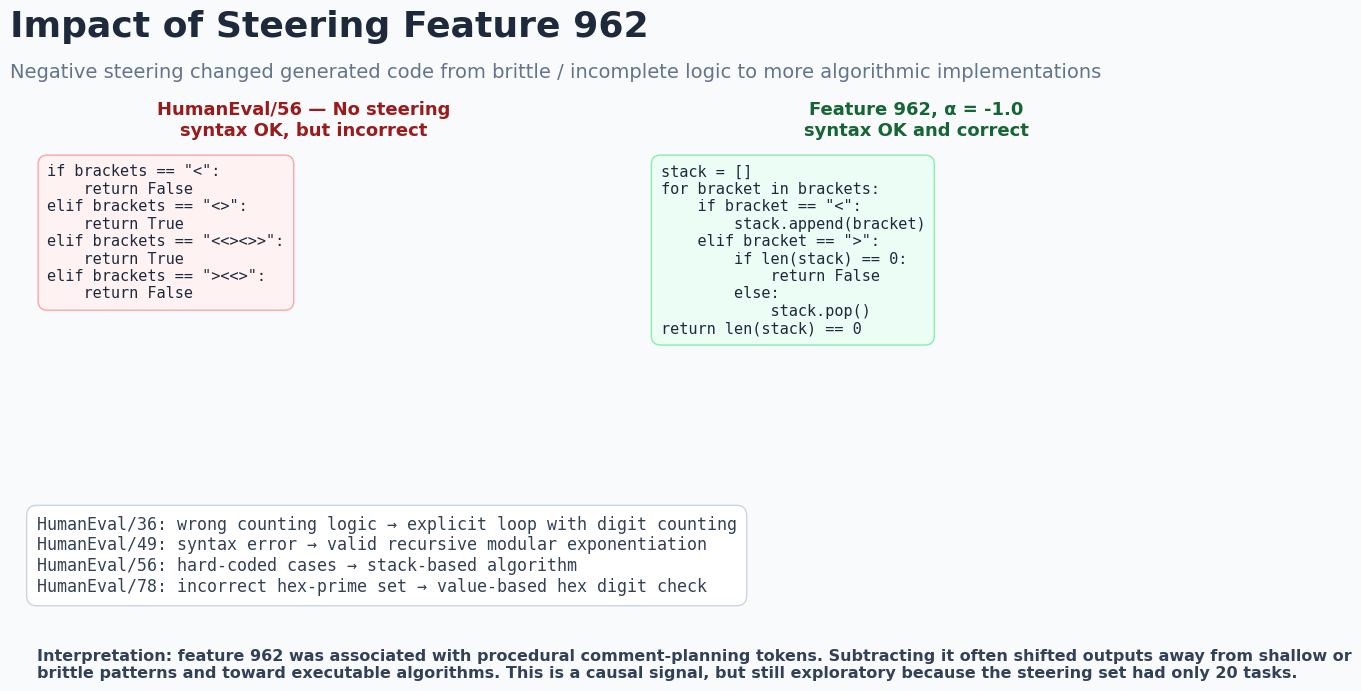

Saved PNG: /content/presentation_assets/feature_962_code_impact.png
Saved SVG: /content/presentation_assets/feature_962_code_impact.svg
Copied to gs://data-intelligence-bucket/tests/


In [219]:
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import textwrap

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

before_code = '''
if brackets == "<":
    return False
elif brackets == "<>":
    return True
elif brackets == "<<><>>":
    return True
elif brackets == "><<>":
    return False
'''.strip()

after_code = '''
stack = []
for bracket in brackets:
    if bracket == "<":
        stack.append(bracket)
    elif bracket == ">":
        if len(stack) == 0:
            return False
        else:
            stack.pop()
return len(stack) == 0
'''.strip()

fig = plt.figure(figsize=(13.33, 7.5))
fig.patch.set_facecolor("#F8FAFC")

fig.text(
    0.04, 0.93,
    "Impact of Steering Feature 962",
    fontsize=26,
    fontweight="bold",
    color="#1E293B",
)

fig.text(
    0.04, 0.875,
    "Negative steering changed generated code from brittle / incomplete logic to more algorithmic implementations",
    fontsize=14,
    color="#64748B",
)

# Main before/after panels
ax_before = fig.add_axes([0.06, 0.38, 0.40, 0.40])
ax_after = fig.add_axes([0.52, 0.38, 0.40, 0.40])

for ax in [ax_before, ax_after]:
    ax.axis("off")

ax_before.set_title(
    "HumanEval/56 — No steering\nsyntax OK, but incorrect",
    fontsize=13,
    fontweight="bold",
    color="#991B1B",
    pad=10,
)

ax_after.set_title(
    "Feature 962, α = -1.0\nsyntax OK and correct",
    fontsize=13,
    fontweight="bold",
    color="#166534",
    pad=10,
)

bbox_before = dict(boxstyle="round,pad=0.6", facecolor="#FEF2F2", edgecolor="#FCA5A5")
bbox_after = dict(boxstyle="round,pad=0.6", facecolor="#ECFDF5", edgecolor="#86EFAC")

ax_before.text(
    0.02, 0.95,
    before_code,
    va="top",
    ha="left",
    fontsize=11,
    family="monospace",
    color="#1E293B",
    bbox=bbox_before,
    transform=ax_before.transAxes,
)

ax_after.text(
    0.02, 0.95,
    after_code,
    va="top",
    ha="left",
    fontsize=11,
    family="monospace",
    color="#1E293B",
    bbox=bbox_after,
    transform=ax_after.transAxes,
)

# Bottom summary box
fig.text(
    0.06, 0.285,
    "Observed improvements with feature 962, α = -1.0",
    fontsize=15,
    fontweight="bold",
    color="#1E293B",
)

summary_text = (
    "HumanEval/36: wrong counting logic → explicit loop with digit counting\n"
    "HumanEval/49: syntax error → valid recursive modular exponentiation\n"
    "HumanEval/56: hard-coded cases → stack-based algorithm\n"
    "HumanEval/78: incorrect hex-prime set → value-based hex digit check"
)

fig.text(
    0.06, 0.19,
    summary_text,
    fontsize=12,
    color="#334155",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#CBD5E1"),
)

# Discussion note
discussion = (
    "Interpretation: feature 962 was associated with procedural comment-planning tokens. "
    "Subtracting it often shifted outputs away from shallow or brittle patterns and toward executable algorithms. "
    "This is a causal signal, but still exploratory because the steering set had only 20 tasks."
)

fig.text(
    0.06, 0.075,
    textwrap.fill(discussion, width=145),
    fontsize=11.5,
    color="#334155",
    fontweight="bold",
)

png_path = OUT_DIR / "feature_962_code_impact.png"
svg_path = OUT_DIR / "feature_962_code_impact.svg"

fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="#F8FAFC")
fig.savefig(svg_path, bbox_inches="tight", facecolor="#F8FAFC")
plt.show()

print("Saved PNG:", png_path)
print("Saved SVG:", svg_path)

try:
    subprocess.run(["gsutil", "cp", str(png_path), "gs://data-intelligence-bucket/tests/"], check=True)
    subprocess.run(["gsutil", "cp", str(svg_path), "gs://data-intelligence-bucket/tests/"], check=True)
    print("Copied to gs://data-intelligence-bucket/tests/")
except Exception as e:
    print("GCS copy skipped/failed:", e)

In [160]:
qualitative_962 = pd.DataFrame([
    {
        "task_id": "HumanEval/36",
        "base_failure_mode": "Overly compact one-liner; wrong boolean precedence/counting semantics",
        "steered_behavior": "Explicit loop; checks divisibility first; counts digit occurrences",
        "first_successful_alpha": -1.0,
        "interpretation": "Suppresses brittle shortcut completion"
    },
    {
        "task_id": "HumanEval/49",
        "base_failure_mode": "Incomplete recursive expression causing syntax error",
        "steered_behavior": "Complete recursive modular exponentiation formula",
        "first_successful_alpha": -0.5,
        "interpretation": "Suppresses incomplete expression generation"
    },
    {
        "task_id": "HumanEval/56",
        "base_failure_mode": "Overfits to docstring examples",
        "steered_behavior": "General stack-based algorithm",
        "first_successful_alpha": -0.1,
        "interpretation": "Moves from example memorization to algorithmic abstraction"
    },
    {
        "task_id": "HumanEval/78",
        "base_failure_mode": "Surface-level wrong character set; includes non-prime hex digit C",
        "steered_behavior": "Maps hex symbols to values and checks prime-valued digits",
        "first_successful_alpha": -0.25,
        "interpretation": "Improves semantic grounding of symbol-to-value mapping"
    },
])

display(qualitative_962)

,task_id,base_failure_mode,steered_behavior,first_successful_alpha,interpretation
0,HumanEval/36,Overly compact one-liner; wrong boolean preced...,Explicit loop; checks divisibility first; coun...,-1.00,Suppresses brittle shortcut completion
1,HumanEval/49,Incomplete recursive expression causing syntax...,Complete recursive modular exponentiation formula,-0.50,Suppresses incomplete expression generation
2,HumanEval/56,Overfits to docstring examples,General stack-based algorithm,-0.10,Moves from example memorization to algorithmic...
3,HumanEval/78,Surface-level wrong character set; includes no...,Maps hex symbols to values and checks prime-va...,-0.25,Improves semantic grounding of symbol-to-value...


In [161]:
feature_id = 962

tested_tasks = sorted(df_steer[df_steer["feature_id"].eq(feature_id)]["task_id"].unique())

base_baseline = (
    df_base[df_base["task_id"].isin(tested_tasks)]
    .assign(feature_id=feature_id, alpha=0.0)
    [["feature_id", "alpha", "task_id", "syntax_ok", "correct"]]
)

steer_points = (
    df_steer[df_steer["feature_id"].eq(feature_id)]
    [["feature_id", "alpha", "task_id", "syntax_ok", "correct"]]
)

plot_raw = pd.concat([base_baseline, steer_points], ignore_index=True)

plot_df = (
    plot_raw
    .groupby(["feature_id", "alpha"])
    .agg(
        n=("task_id", "nunique"),
        syntax_rate=("syntax_ok", "mean"),
        correct_rate=("correct", "mean"),
        correct_count=("correct", "sum"),
    )
    .reset_index()
    .sort_values("alpha")
)

display(plot_df)

,feature_id,alpha,n,syntax_rate,correct_rate,correct_count
0,962.0,-1.00,20,1.00,0.20,4
1,962.0,-0.50,20,1.00,0.15,3
2,962.0,-0.25,20,0.95,0.10,2
3,962.0,-0.10,20,0.90,0.05,1
4,962.0,0.00,20,0.95,0.00,0


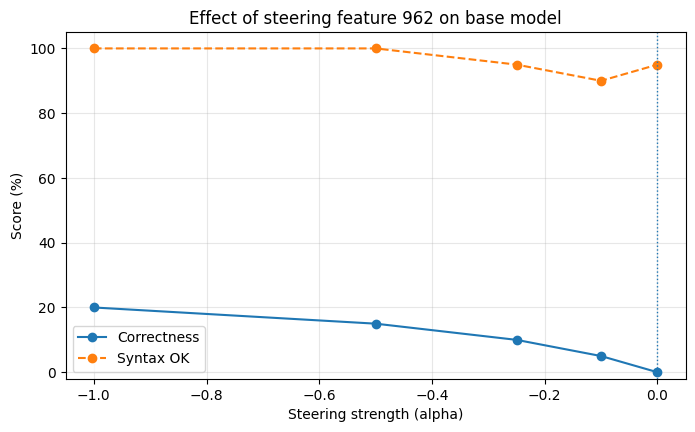

In [162]:
import numpy as np
import matplotlib.pyplot as plt

g = plot_df.sort_values("alpha")

x = g["alpha"].to_numpy()
y_correct = 100 * g["correct_rate"].to_numpy()
y_syntax = 100 * g["syntax_rate"].to_numpy()

plt.figure(figsize=(8, 4.5))
plt.plot(x, y_correct, marker="o", label="Correctness")
plt.plot(x, y_syntax, marker="o", linestyle="--", label="Syntax OK")

plt.axvline(0, linestyle=":", linewidth=1)
plt.ylim(-2, 105)
plt.xlabel("Steering strength (alpha)")
plt.ylabel("Score (%)")
plt.title("Effect of steering feature 962 on base model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [181]:
!cd recatcher_crosscoder_humaneval/


/bin/bash: line 1: cd: recatcher_crosscoder_humaneval/: No such file or directory


In [182]:
!ls

activations  crosscoder  evaluation  generations  steering


In [184]:
!gcloud auth list
!gcloud config get-value project

      Credentialed Accounts
ACTIVE  ACCOUNT
*       lucas.armand@rdstation.com

To set the active account, run:
    $ gcloud config set account `ACCOUNT`

rd-rvn-analytics-prd-01


In [185]:
from pathlib import Path
import datetime

SRC_DIR = Path("recatcher_crosscoder_humaneval")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

archive_name = f"recatcher_crosscoder_humaneval_backup_{timestamp}.tar.gz"
archive_path = Path("/content") / archive_name

archive_path

PosixPath('/content/recatcher_crosscoder_humaneval_backup_20260506_055301.tar.gz')

In [186]:
!du -sh recatcher_crosscoder_humaneval
!tar -czf "{archive_path}" recatcher_crosscoder_humaneval
!ls -lh "{archive_path}"

du: cannot access 'recatcher_crosscoder_humaneval': No such file or directory
tar: recatcher_crosscoder_humaneval: Cannot stat: No such file or directory
tar: Exiting with failure status due to previous errors
-rw-r--r-- 1 root root 45 May  6 05:53 /content/recatcher_crosscoder_humaneval_backup_20260506_055301.tar.gz


In [187]:
!tar -tzf "{archive_path}" | head -50

In [189]:
!gsutil ls gs://data-intelligence-bucket/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://data-intelligence-bucket/clientes.csv
gs://data-intelligence-bucket/generated_workspace_file.json
gs://data-intelligence-bucket//
gs://data-intelligence-bucket/api-tldv/
gs://data-intelligence-bucket/api-zoom/
gs://data-intelligence-bucket/api_tldv/
gs://data-intelligence-bucket/base_ativa_porte/
gs://data-intelligence-bucket/buyer-journey/
gs://data-intelligence-bucket/call-sagan/
gs://data-intelligence-bucket/call_sagan_cs/
gs://data-intelligence-bucket/cloudaudit.googleapis.com/
gs://data-intelligence-bucket/company-size-calculate-v2/
gs://data-intelligence-bucket/company-size-enrichment/
gs://data-intelligence-bucket/crm-retention/
gs://data-intelligence-bucket/customer-happiness-index/
gs://data-intelligence-bucket/ecomme

In [190]:
from pathlib import Path
import datetime

SRC_DIR = Path("recatcher_crosscoder_humaneval")
DEST_GCS_DIR = "gs://data-intelligence-bucket/tests"

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

full_archive = "recatcher_crosscoder_humaneval_backup_20260506_055301.tar.gz"

print("Source:", SRC_DIR)
print("Full archive:", full_archive)
print("Important archive:", important_archive)
print("GCS destination:", DEST_GCS_DIR)

Source: recatcher_crosscoder_humaneval
Full archive: /content/recatcher_crosscoder_humaneval_FULL_20260506_055718.tar.gz
Important archive: /content/recatcher_crosscoder_humaneval_IMPORTANT_20260506_055718.tar.gz
GCS destination: gs://data-intelligence-bucket/tests


In [203]:
!du -sh recatcher_crosscoder_humaneval
!du -sh recatcher_crosscoder_humaneval/*

1.6G	recatcher_crosscoder_humaneval
1.4G	recatcher_crosscoder_humaneval/activations
258M	recatcher_crosscoder_humaneval/crosscoder
112K	recatcher_crosscoder_humaneval/evaluation
692K	recatcher_crosscoder_humaneval/generations
512K	recatcher_crosscoder_humaneval/steering


In [208]:
!tar -czf "{full_archive}" recatcher_crosscoder_humaneval
!ls -lh "{full_archive}"

-rw-r--r-- 1 root root 1.5G May  6 06:03 recatcher_crosscoder_humaneval_backup_20260506_055301.tar.gz


In [206]:
!tar -tzf "{full_archive}" | head -50

In [209]:
!gsutil -m cp "{full_archive}" "{DEST_GCS_DIR}/"

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://recatcher_crosscoder_humaneval_backup_20260506_055301.tar.gz [Content-Type=application/x-tar]...
==> NOTE: You are uploading one or more large file(s), which would run
significantly faster if you enable parallel composite uploads. This
feature can be enabled by editing the
"parallel_composite_upload_threshold" value in your .boto
configuration file. However, note that if you do this large files will
be uploaded as `composite objects
<https://cloud.google.com/storage/docs/composite-objects>`_,which
means that any user who downloads such objects will need to have a
compiled crcmod installed (see "gsutil help crcmod"). This is because
without a compiled crcmod, computing checksums on composite objects is
so slow that gs

In [211]:
# Create presentation: ReCatcher + CrossCoder experiment
# Output: /content/recatcher_crosscoder_presentation.pptx and GCS copy

!pip install -q python-pptx matplotlib pandas numpy

from pathlib import Path
import subprocess, textwrap, datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor

OUT_DIR = Path("/content/presentation_assets")
OUT_DIR.mkdir(exist_ok=True)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
pptx_path = Path(f"/content/recatcher_crosscoder_presentation_{timestamp}.pptx")
GCS_DEST = "gs://data-intelligence-bucket/tests/"

# ---------- Helpers ----------
def get_df(name):
    return globals().get(name, None)

def add_title(slide, title, subtitle=None):
    box = slide.shapes.add_textbox(Inches(0.55), Inches(0.35), Inches(12.2), Inches(0.7))
    p = box.text_frame.paragraphs[0]
    p.text = title
    p.font.size = Pt(30)
    p.font.bold = True
    p.font.color.rgb = RGBColor(25, 35, 55)
    if subtitle:
        box2 = slide.shapes.add_textbox(Inches(0.58), Inches(1.0), Inches(12), Inches(0.35))
        p2 = box2.text_frame.paragraphs[0]
        p2.text = subtitle
        p2.font.size = Pt(14)
        p2.font.color.rgb = RGBColor(90, 90, 90)

def add_bullets(slide, bullets, x=0.75, y=1.45, w=12, h=5.5, size=18):
    box = slide.shapes.add_textbox(Inches(x), Inches(y), Inches(w), Inches(h))
    tf = box.text_frame
    tf.word_wrap = True
    for i, b in enumerate(bullets):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.text = b
        p.font.size = Pt(size)
        p.level = 0
        p.space_after = Pt(8)

def add_table(slide, df, x, y, w, h, font_size=10):
    rows, cols = df.shape[0] + 1, df.shape[1]
    table = slide.shapes.add_table(rows, cols, Inches(x), Inches(y), Inches(w), Inches(h)).table
    for j, col in enumerate(df.columns):
        cell = table.cell(0, j)
        cell.text = str(col)
        cell.text_frame.paragraphs[0].font.bold = True
        cell.text_frame.paragraphs[0].font.size = Pt(font_size)
    for i in range(df.shape[0]):
        for j in range(cols):
            cell = table.cell(i+1, j)
            cell.text = str(df.iloc[i, j])
            cell.text_frame.paragraphs[0].font.size = Pt(font_size)
    return table

def savefig(name):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()
    return path

# ---------- Data extraction ----------
df_base = get_df("df_base")
df_merged = get_df("df_merged")
df_correctness = get_df("df_correctness")
df_steer = get_df("df_steer")

# fallback values from current experiment
base_correct = float(df_base["correct"].mean()) if df_base is not None else 0.4085
merged_correct = float(df_merged["correct"].mean()) if df_merged is not None else 0.7195
base_syntax = float(df_base["syntax_ok"].mean()) if df_base is not None else 0.9695
merged_syntax = float(df_merged["syntax_ok"].mean()) if df_merged is not None else 0.9878

label_counts = None
if df_correctness is not None and "label" in df_correctness:
    label_counts = df_correctness["label"].value_counts()
else:
    label_counts = pd.Series({
        "both_correct": 64,
        "merged_only_correct": 54,
        "both_incorrect": 43,
        "base_only_correct": 3
    })

# choose best causal feature
BEST_FEATURE_ID = 936

if df_steer is not None and "feature_id" in df_steer:
    df_steer = df_steer.copy()

    # clean feature_id safely
    df_steer["feature_id_clean"] = pd.to_numeric(df_steer["feature_id"], errors="coerce")
    df_steer = df_steer[np.isfinite(df_steer["feature_id_clean"])].copy()
    df_steer["feature_id_clean"] = df_steer["feature_id_clean"].astype(int)

    available = set(df_steer["feature_id_clean"].unique())

    if BEST_FEATURE_ID not in available:
        tmp = (
            df_steer
            .groupby(["feature_id_clean", "alpha"], dropna=True)["correct"]
            .sum()
            .reset_index()
            .sort_values("correct", ascending=False)
        )

        if len(tmp) > 0:
            BEST_FEATURE_ID = int(tmp.iloc[0]["feature_id_clean"])
        else:
            BEST_FEATURE_ID = 936

# ---------- Figures ----------
# Correctness / syntax chart
plt.figure(figsize=(6.5, 3.6))
x = np.arange(2)
plt.bar(x - .18, [base_correct*100, merged_correct*100], width=.36, label="Correctness")
plt.bar(x + .18, [base_syntax*100, merged_syntax*100], width=.36, label="Syntax OK")
plt.xticks(x, ["Base", "Merged"])
plt.ylabel("Rate (%)")
plt.ylim(0, 105)
plt.title("DeepSeek base vs merged on HumanEval")
plt.legend()
fig_correctness = savefig("correctness_syntax.png")

# label counts
plt.figure(figsize=(6.5, 3.6))
label_counts.reindex(["both_correct","merged_only_correct","base_only_correct","both_incorrect"]).plot(kind="bar")
plt.ylabel("Tasks")
plt.title("Task-level outcome labels")
plt.xticks(rotation=25, ha="right")
fig_labels = savefig("task_labels.png")

# steering chart
fig_steering = None
if df_steer is not None:
    plot_df = (
        df_steer.groupby(["feature_id", "alpha"])
        .agg(n=("task_id", "nunique"), correct_rate=("correct", "mean"), syntax_rate=("syntax_ok", "mean"), correct_count=("correct","sum"))
        .reset_index()
    )
    top_features = (
        plot_df.groupby("feature_id")["correct_count"].max()
        .sort_values(ascending=False).head(5).index.tolist()
    )
    plt.figure(figsize=(7, 4))
    for fid in top_features:
        g = plot_df[plot_df["feature_id"].eq(fid)].sort_values("alpha")
        plt.plot(g["alpha"], 100*g["correct_rate"], marker="o", label=f"Feature {int(fid)}")
    plt.axvline(0, linestyle=":", linewidth=1)
    plt.ylabel("Correct rate (%)")
    plt.xlabel("Steering strength")
    plt.title("Causal steering smoke test")
    plt.ylim(-2, 105)
    plt.legend(fontsize=8)
    fig_steering = savefig("steering_effects.png")

# ---------- Presentation ----------
prs = Presentation()
prs.slide_width = Inches(13.33)
prs.slide_height = Inches(7.5)

# 1
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "From Regression Testing to Model Diffing", "A simplified ReCatcher + CrossCoder experiment on DeepSeek code generation")
add_bullets(s, [
    "Goal: compare a base code model with a merged variant, then inspect internal features that may explain behavioral differences.",
    "ReCatcher inspired the external evaluation: correctness, syntax validity, and task-level regressions.",
    "CrossCoder inspired the internal analysis: learn sparse features from paired activations and test them causally with steering.",
], y=1.65, size=20)

# 2
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "ReCatcher: What I Replicated in Simplified Form")
add_bullets(s, [
    "Original idea: regression testing for LLM code generation after model updates.",
    "Dimensions: logical correctness, static code issues, and performance.",
    "My simplified version focused first on executable outcomes: HumanEval correctness, syntax errors, and timing when comparable.",
    "Instead of fully reproducing the framework, I used it as a task-level diffing scaffold."
], size=18)

# 3
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "ReCatcher Table 1: How I Used It")
table1 = pd.DataFrame([
    ["Logical correctness", "Incorrect code rate / test failures", "Main signal for regression or improvement"],
    ["Errors", "Syntax errors, missing imports", "Useful for identifying broken generations"],
    ["Maintainability / readability", "Pylint / duplication / code smells", "Not fully replicated here"],
    ["Performance", "Execution time and memory improvement/regression", "Partially explored when both outputs pass"],
])
add_table(s, table1, 0.65, 1.35, 12.0, 3.2, font_size=11)
add_bullets(s, [
    "Key interpretation: Table 1 reports how often a model update improves or regresses on each dimension, not only average score changes."
], y=5.05, size=17)

# 4
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "Experimental Setup")
setup = pd.DataFrame([
    ["Base model", "deepseek-ai/deepseek-coder-6.7b-base"],
    ["Merged model", "ori-ai-fabric/ds-trinity-7b-v1"],
    ["Dataset", "openai/openai_humaneval, 164 tasks"],
    ["Generations", "1 per task, deterministic / low-temperature smoke test"],
    ["Activation layer", "Layer 12 residual stream"],
    ["Analysis folders", "generations, evaluation, activations, crosscoder, steering"],
])
add_table(s, setup, 0.8, 1.35, 11.8, 4.2, font_size=12)

# 5
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "External Behavioral Difference: Base vs Merged")
s.shapes.add_picture(str(fig_correctness), Inches(0.7), Inches(1.35), width=Inches(6.0))
s.shapes.add_picture(str(fig_labels), Inches(6.9), Inches(1.35), width=Inches(5.8))
add_bullets(s, [
    f"Base correctness: {base_correct*100:.1f}%; merged correctness: {merged_correct*100:.1f}%.",
    f"Key subset: {int(label_counts.get('merged_only_correct', 0))} tasks where the merged model passed and the base model failed."
], y=5.55, size=16)

# 6
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "Why CrossCoder?")
add_bullets(s, [
    "ReCatcher tells us what changed behaviorally; CrossCoder helps ask where the change may be represented internally.",
    "A CrossCoder learns a sparse shared feature space from paired activations of two models.",
    "Features can be ranked by model-side decoder norms, activation statistics, and correlation with behavioral labels.",
    "I used a standard CrossCoder-style setup as a lightweight exploratory model-diffing tool."
], size=19)

# 7
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "CrossCoder Variants and My Choice")
variants = pd.DataFrame([
    ["Standard CrossCoder", "Shared sparse feature dictionary; exclusivity inferred post hoc"],
    ["Dedicated Feature CrossCoder", "Partitions features into model A-exclusive, model B-exclusive, and shared"],
    ["My experiment", "Simplified standard CrossCoder-style training on layer 12 activations"],
])
add_table(s, variants, 0.75, 1.3, 12.0, 2.3, font_size=12)
add_bullets(s, [
    "Rationale: start with a minimal version that can run in the available notebook environment.",
    "Limitation: no architectural exclusivity partition; feature interpretation is more exploratory."
], y=4.15, size=18)

# 8
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "Feature Search Strategy")
add_bullets(s, [
    "1. Generate and evaluate base and merged solutions on HumanEval.",
    "2. Label each task: both correct, merged-only correct, base-only correct, or both incorrect.",
    "3. Capture paired activations from layer 12.",
    "4. Train a sparse CrossCoder and compute feature statistics.",
    "5. Prioritize features by association with correctness differences and by interpretability of top activating tokens.",
    "6. Validate promising features with activation steering."
], size=18)

# 9
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "Feature Metrics Used")
metrics = pd.DataFrame([
    ["Relative decoder norm", "Whether the feature is more base-like or merged-like"],
    ["Global mean / active fraction", "How often the feature activates"],
    ["Group activation difference", "Whether it appears more in merged-only-correct or other groups"],
    ["Correctness gain score", "Heuristic priority score for candidate features"],
    ["Steering response", "Causal test: does adding/subtracting the vector change correctness?"],
])
add_table(s, metrics, 0.75, 1.25, 12.0, 4.0, font_size=12)

# 10
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "Causal Steering Results")
if fig_steering:
    s.shapes.add_picture(str(fig_steering), Inches(0.9), Inches(1.25), width=Inches(7.1))
add_bullets(s, [
    f"Best causal feature in the current notebook selection: Feature {BEST_FEATURE_ID}.",
    "Negative steering was tested by adding alpha × scale × decoder vector at generation time.",
    "The most interesting cases are where the original base model failed but the steered base model passed.",
], x=8.25, y=1.55, w=4.4, h=4.8, size=16)

# 11
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, f"Interpreting Feature {BEST_FEATURE_ID}")
add_bullets(s, [
    "The causal interpretation should be cautious: steering a direction is stronger evidence than correlation, but it is still a small-sample smoke test.",
    "For the strongest feature, the relevant question is not only whether it activates naturally, but whether suppressing its direction changes the generation trajectory.",
    "Observed pattern from the qualitative analysis: steering can move outputs away from brittle local completions and toward more complete algorithmic solutions.",
    "Next step: inspect max-activating tokens, compare corrected vs uncorrected tasks, and test robustness across seeds and more tasks."
], size=18)

# 12
s = prs.slides.add_slide(prs.slide_layouts[6])
add_title(s, "Main Takeaways")
add_bullets(s, [
    "The merged DeepSeek variant substantially outperformed the base model on HumanEval in this run.",
    "A simplified ReCatcher-style evaluation produced useful task-level labels for model diffing.",
    "CrossCoder features provided a bridge from behavioral differences to internal activation directions.",
    "Activation steering gave causal evidence that some feature directions can affect code correctness.",
    "Current limitation: small steering sample, simplified CrossCoder, and feature semantics still require careful validation."
], size=20)

prs.save(pptx_path)
print("Saved:", pptx_path)

# Copy to GCS
try:
    subprocess.run(["gsutil", "cp", str(pptx_path), GCS_DEST], check=True)
    print("Copied to:", GCS_DEST)
except Exception as e:
    print("GCS copy failed; local file is still saved:", e)

pptx_path

Saved: /content/recatcher_crosscoder_presentation_20260506_062336.pptx
Copied to: gs://data-intelligence-bucket/tests/


PosixPath('/content/recatcher_crosscoder_presentation_20260506_062336.pptx')

In [163]:
# %% [code]
TOP_CONTEXT_TASKS_962 = [
    "HumanEval/115",
    "HumanEval/127",
    "HumanEval/136",
    "HumanEval/157",
]

feature_id = 962
alphas = [0.0, -1.0]

scale = feature_scales[feature_id][STEERING_SCALE_KIND]

target_examples_token_contexts = [
    ex for ex in examples
    if ex["task_id"] in TOP_CONTEXT_TASKS_962
]

print("Target examples:", [ex["task_id"] for ex in target_examples_token_contexts])
print("Feature:", feature_id, "scale:", scale, "scale_kind:", STEERING_SCALE_KIND)

base_model, base_tokenizer = load_quantized_model(BASE_MODEL)

token_context_steering_rows = []

for ex in target_examples_token_contexts:
    task_id = ex["task_id"]

    # importante: mesmo seed para alpha=0 e alpha=-1
    # uso task_idx para manter determinismo estável
    seed = 962000 + int(task_id.split("/")[-1])

    for alpha in alphas:
        row = generate_and_evaluate_one_steered(
            model=base_model,
            tokenizer=base_tokenizer,
            ex=ex,
            feature_id=feature_id if alpha != 0.0 else None,
            alpha=alpha,
            scale=scale,
            decoder_side="base",
            seed=seed,
            do_sample=False,
        )

        row["analysis_group"] = "top_token_context_feature_962"
        row["scale_kind"] = STEERING_SCALE_KIND
        row["model_name"] = BASE_MODEL
        row["model_label"] = "base"

        token_context_steering_rows.append(row)

        print(
            task_id,
            "alpha", alpha,
            "syntax", row["syntax_ok"],
            "correct", row["correct"],
            "error", str(row["error"])[:120] if row["error"] else None,
        )

del base_model
gc.collect()
torch.cuda.empty_cache()

df_token_context_steer = pd.DataFrame(token_context_steering_rows)

display(
    df_token_context_steer[
        ["task_id", "feature_id", "alpha", "syntax_ok", "correct", "error"]
    ].sort_values(["task_id", "alpha"])
)

Target examples: ['HumanEval/115', 'HumanEval/127', 'HumanEval/136', 'HumanEval/157']
Feature: 962 scale: 26.076923370361328 scale_kind: p99


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

HumanEval/115 alpha 0.0 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmp1zxvptb2.py", line 15, in <module>
    check(
Using layers at: model.layers
Number of layers: 32
HumanEval/115 alpha -1.0 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmp6dr6luu8.py", line 15, in <module>
    check(
HumanEval/127 alpha 0.0 syntax True correct False error AssertionError()
Traceback (most recent call last):
  File "/tmp/tmp39uu42za.py", line 15, in <module>
    check(interse
Using layers at: model.layers
Number of layers: 32
HumanEval/127 alpha -1.0 syntax True correct False error AssertionError()
Traceback (most recent call last):
  File "/tmp/tmpf508gi78.py", line 15, in <module>
    check(interse
HumanEval/136 alpha 0.0 syntax True correct False error AssertionError()
Traceback (most recent call last):
  File "/tmp/tmp0hrwpyzt.py", line 15, in <module>
    check(largest
Using layer

,task_id,feature_id,alpha,syntax_ok,correct,error
1,HumanEval/115,962.0,-1.0,True,False,AssertionError('Error')\nTraceback (most recen...
0,HumanEval/115,NaN,0.0,True,False,AssertionError('Error')\nTraceback (most recen...
3,HumanEval/127,962.0,-1.0,True,False,AssertionError()\nTraceback (most recent call ...
2,HumanEval/127,NaN,0.0,True,False,AssertionError()\nTraceback (most recent call ...
5,HumanEval/136,962.0,-1.0,True,False,AssertionError()\nTraceback (most recent call ...
4,HumanEval/136,NaN,0.0,True,False,AssertionError()\nTraceback (most recent call ...
7,HumanEval/157,962.0,-1.0,True,True,None
6,HumanEval/157,NaN,0.0,True,True,None


In [164]:
# %% [code]
wide_token_context = (
    df_token_context_steer
    .pivot_table(
        index="task_id",
        columns="alpha",
        values=["syntax_ok", "correct", "error", "candidate_code"],
        aggfunc="first"
    )
)

summary_rows = []

for task_id in TOP_CONTEXT_TASKS_962:
    rows0 = df_token_context_steer[
        df_token_context_steer["task_id"].eq(task_id) &
        df_token_context_steer["alpha"].eq(0.0)
    ]

    rows1 = df_token_context_steer[
        df_token_context_steer["task_id"].eq(task_id) &
        df_token_context_steer["alpha"].eq(-1.0)
    ]

    if rows0.empty or rows1.empty:
        continue

    r0 = rows0.iloc[0]
    r1 = rows1.iloc[0]

    summary_rows.append({
        "task_id": task_id,
        "alpha0_syntax": r0["syntax_ok"],
        "alpha0_correct": r0["correct"],
        "alpha_minus1_syntax": r1["syntax_ok"],
        "alpha_minus1_correct": r1["correct"],
        "improved": (not r0["correct"]) and r1["correct"],
        "regressed": r0["correct"] and (not r1["correct"]),
        "same_correctness": r0["correct"] == r1["correct"],
        "alpha0_error": r0["error"],
        "alpha_minus1_error": r1["error"],
    })

df_token_context_summary = pd.DataFrame(summary_rows)
display(df_token_context_summary)

print("Improved:", df_token_context_summary["improved"].sum())
print("Regressed:", df_token_context_summary["regressed"].sum())
print("Same correctness:", df_token_context_summary["same_correctness"].sum())

,task_id,alpha0_syntax,alpha0_correct,alpha_minus1_syntax,alpha_minus1_correct,improved,regressed,same_correctness,alpha0_error,alpha_minus1_error
0,HumanEval/115,True,False,True,False,False,False,True,AssertionError('Error')\nTraceback (most recen...,AssertionError('Error')\nTraceback (most recen...
1,HumanEval/127,True,False,True,False,False,False,True,AssertionError()\nTraceback (most recent call ...,AssertionError()\nTraceback (most recent call ...
2,HumanEval/136,True,False,True,False,False,False,True,AssertionError()\nTraceback (most recent call ...,AssertionError()\nTraceback (most recent call ...
3,HumanEval/157,True,True,True,True,False,False,True,None,None


Improved: 0
Regressed: 0
Same correctness: 4


In [165]:
# %% [code]
from IPython.display import display, Markdown

def show_alpha0_vs_minus1_for_context_task(task_id):
    rows0 = df_token_context_steer[
        df_token_context_steer["task_id"].eq(task_id) &
        df_token_context_steer["alpha"].eq(0.0)
    ]

    rows1 = df_token_context_steer[
        df_token_context_steer["task_id"].eq(task_id) &
        df_token_context_steer["alpha"].eq(-1.0)
    ]

    if rows0.empty or rows1.empty:
        print("Missing task/alpha:", task_id)
        return

    r0 = rows0.iloc[0]
    r1 = rows1.iloc[0]

    display(Markdown(f"# {task_id}"))

    display(Markdown("## alpha = 0.0 / no steering"))
    display(Markdown(
        f"syntax_ok={r0['syntax_ok']} | correct={r0['correct']}\n\n"
        f"error: `{str(r0['error'])[:500]}`"
    ))
    print(r0["candidate_code"])

    print("\n" + "=" * 120 + "\n")

    display(Markdown("## alpha = -1.0 / feature 962 negative steering"))
    display(Markdown(
        f"syntax_ok={r1['syntax_ok']} | correct={r1['correct']}\n\n"
        f"error: `{str(r1['error'])[:500]}`"
    ))
    print(r1["candidate_code"])

for task_id in TOP_CONTEXT_TASKS_962:
    show_alpha0_vs_minus1_for_context_task(task_id)

# HumanEval/115

## alpha = 0.0 / no steering

syntax_ok=True | correct=False

error: `AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmp1zxvptb2.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in check
AssertionError: Error
`


def max_fill(grid, capacity):
    import math
    """
    You are given a rectangular grid of wells. Each row represents a single well,
    and each 1 in a row represents a single unit of water.
    Each well has a corresponding bucket that can be used to extract water from it, 
    and all buckets have the same capacity.
    Your task is to use the buckets to empty the wells.
    Output the number of times you need to lower the buckets.

    Example 1:
        Input: 
            grid : [[0,0,1,0], [0,1,0,0], [1,1,1,1]]
            bucket_capacity : 1
        Output: 6

    Example 2:
        Input: 
            grid : [[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]]
            bucket_capacity : 2
        Output: 5
    
    Example 3:
        Input: 
            grid : [[0,0,0], [0,0,0]]
            bucket_capacity : 5
        Output: 0

    Constraints:
        * all wells have the same length
        * 1 <= grid.length <= 10^2
        * 1 <= grid[:,1].length <= 10^2
        * grid[i][

## alpha = -1.0 / feature 962 negative steering

...

syntax_ok=True | correct=True

error: `None`


def right_angle_triangle(a, b, c):
    '''
    Given the lengths of the three sides of a triangle. Return True if the three
    sides form a right-angled triangle, False otherwise.
    A right-angled triangle is a triangle in which one angle is right angle or 
    90 degree.
    Example:
    right_angle_triangle(3, 4, 5) == True
    right_angle_triangle(1, 2, 3) == False
    '''
    if a > b and a > c:
        if a**2 == b**2 + c**2:
            return True
        else:
            return False
    elif b > a and b > c:
        if b**2 == a**2 + c**2:
            return True
        else:
            return False
    elif c > a and c > b:
        if c**2 == a**2 + b**2:
            return True
        else:
            return False
    else:
        return False





## alpha = -1.0 / feature 962 negative steering

syntax_ok=True | correct=True

error: `None`


def right_angle_triangle(a, b, c):
    '''
    Given the lengths of the three sides of a triangle. Return True if the three
    sides form a right-angled triangle, False otherwise.
    A right-angled triangle is a triangle in which one angle is right angle or 
    90 degree.
    Example:
    right_angle_triangle(3, 4, 5) == True
    right_angle_triangle(1, 2, 3) == False
    '''
    if a**2 + b**2 == c**2:
        return True
    elif a**2 + c**2 == b**2:
        return True
    elif b**2 + c**2 == a**2:
        return True
    else:
        return False



In [166]:
# %% [code]
task_id = "HumanEval/115"
feature_id = 962

alphas = [0.0, -0.5, -1.0, -2.0, -3.0, -5.0]

scale = feature_scales[feature_id][STEERING_SCALE_KIND]

ex_115 = next(ex for ex in examples if ex["task_id"] == task_id)

base_model, base_tokenizer = load_quantized_model(BASE_MODEL)

rows_115_stronger = []

seed = 962115  # mesmo seed para comparar alphas

for alpha in alphas:
    row = generate_and_evaluate_one_steered(
        model=base_model,
        tokenizer=base_tokenizer,
        ex=ex_115,
        feature_id=feature_id if alpha != 0.0 else None,
        alpha=alpha,
        scale=scale,
        decoder_side="base",
        seed=seed,
        do_sample=False,
    )

    row["analysis_group"] = "feature_962_stronger_steering_humaneval_115"
    row["scale_kind"] = STEERING_SCALE_KIND
    row["model_name"] = BASE_MODEL
    row["model_label"] = "base"

    rows_115_stronger.append(row)

    print(
        "alpha", alpha,
        "syntax", row["syntax_ok"],
        "correct", row["correct"],
        "error", str(row["error"])[:160] if row["error"] else None,
    )

del base_model
gc.collect()
torch.cuda.empty_cache()

df_115_stronger = pd.DataFrame(rows_115_stronger)

display(
    df_115_stronger[
        ["task_id", "feature_id", "alpha", "syntax_ok", "correct", "error"]
    ]
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

alpha 0.0 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmpbv7t9h0d.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in 
Using layers at: model.layers
Number of layers: 32
alpha -0.5 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmpogrtq807.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in 
Using layers at: model.layers
Number of layers: 32
alpha -1.0 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmpmj27mfub.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in 
Using layers at: model.layers
Number of layers: 32
alpha -2.0 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmp6jc2uhqa.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in 
Using layers at: model.layers
Nu

,task_id,feature_id,alpha,syntax_ok,correct,error
0,HumanEval/115,NaN,0.0,True,False,AssertionError('Error')\nTraceback (most recen...
1,HumanEval/115,962.0,-0.5,True,False,AssertionError('Error')\nTraceback (most recen...
2,HumanEval/115,962.0,-1.0,True,False,AssertionError('Error')\nTraceback (most recen...
3,HumanEval/115,962.0,-2.0,True,False,AssertionError('Error')\nTraceback (most recen...
4,HumanEval/115,962.0,-3.0,True,False,AssertionError('Error')\nTraceback (most recen...
5,HumanEval/115,962.0,-5.0,True,False,AssertionError('Error')\nTraceback (most recen...


In [167]:
task_id = "HumanEval/115"
feature_id = 1494

alphas = [0.0, -0.25, -0.5, -1.0, -2.0, -3.0]

scale = feature_scales[feature_id][STEERING_SCALE_KIND]
ex_115 = next(ex for ex in examples if ex["task_id"] == task_id)

base_model, base_tokenizer = load_quantized_model(BASE_MODEL)

rows_115_1494 = []
seed = 1494115

for alpha in alphas:
    row = generate_and_evaluate_one_steered(
        model=base_model,
        tokenizer=base_tokenizer,
        ex=ex_115,
        feature_id=feature_id if alpha != 0.0 else None,
        alpha=alpha,
        scale=scale,
        decoder_side="base",
        seed=seed,
        do_sample=False,
    )

    rows_115_1494.append(row)

    print(
        "alpha", alpha,
        "syntax", row["syntax_ok"],
        "correct", row["correct"],
        "error", str(row["error"])[:160] if row["error"] else None,
    )

del base_model
gc.collect()
torch.cuda.empty_cache()

df_115_1494 = pd.DataFrame(rows_115_1494)

df_115_1494["has_todo"] = df_115_1494["candidate_code"].str.contains(
    "TODO|Implement me|your code here|write your code",
    case=False,
    regex=True,
    na=False,
)

display(df_115_1494[["task_id", "feature_id", "alpha", "syntax_ok", "correct", "has_todo", "error"]])

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

alpha 0.0 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmph91uug25.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in 
Using layers at: model.layers
Number of layers: 32
alpha -0.25 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmp7d891jha.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in 
Using layers at: model.layers
Number of layers: 32
alpha -0.5 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmpdw87c8yu.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in 
Using layers at: model.layers
Number of layers: 32
alpha -1.0 syntax True correct False error AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmppd2hnzec.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in 
Using layers at: model.layers
N

,task_id,feature_id,alpha,syntax_ok,correct,has_todo,error
0,HumanEval/115,NaN,0.00,True,False,True,AssertionError('Error')\nTraceback (most recen...
1,HumanEval/115,1494.0,-0.25,True,False,True,AssertionError('Error')\nTraceback (most recen...
2,HumanEval/115,1494.0,-0.50,True,False,True,AssertionError('Error')\nTraceback (most recen...
3,HumanEval/115,1494.0,-1.00,True,False,True,AssertionError('Error')\nTraceback (most recen...
4,HumanEval/115,1494.0,-2.00,True,False,True,AssertionError('Error')\nTraceback (most recen...
5,HumanEval/115,1494.0,-3.00,True,False,True,AssertionError('Error')\nTraceback (most recen...


In [169]:
from IPython.display import display, Markdown

def show_codes_from_df(df, title):
    display(Markdown(f"# {title}"))

    for _, r in df.sort_values("alpha", ascending=False).iterrows():
        feature = r["feature_id"] if "feature_id" in r else None
        alpha = r["alpha"]

        display(Markdown(
            f"## feature={feature}, alpha={alpha}\n"
            f"syntax_ok={r['syntax_ok']} | correct={r['correct']}"
        ))

        if "has_todo" in df.columns:
            display(Markdown(f"has_todo={r['has_todo']}"))

        if r["error"]:
            display(Markdown(f"error: `{str(r['error'])[:700]}`"))

        print(r["candidate_code"])
        print("\n" + "=" * 140 + "\n")

In [170]:
show_codes_from_df(
    df_115_1494,
    "HumanEval/115 — feature 1494 steering"
)

# HumanEval/115 — feature 1494 steering

## feature=nan, alpha=0.0
syntax_ok=True | correct=False

has_todo=True

error: `AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmph91uug25.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in check
AssertionError: Error
`


def max_fill(grid, capacity):
    import math
    """
    You are given a rectangular grid of wells. Each row represents a single well,
    and each 1 in a row represents a single unit of water.
    Each well has a corresponding bucket that can be used to extract water from it, 
    and all buckets have the same capacity.
    Your task is to use the buckets to empty the wells.
    Output the number of times you need to lower the buckets.

    Example 1:
        Input: 
            grid : [[0,0,1,0], [0,1,0,0], [1,1,1,1]]
            bucket_capacity : 1
        Output: 6

    Example 2:
        Input: 
            grid : [[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]]
            bucket_capacity : 2
        Output: 5
    
    Example 3:
        Input: 
            grid : [[0,0,0], [0,0,0]]
            bucket_capacity : 5
        Output: 0

    Constraints:
        * all wells have the same length
        * 1 <= grid.length <= 10^2
        * 1 <= grid[:,1].length <= 10^2
        * grid[i][

...


def max_fill(grid, capacity):
    import math
    """
    You are given a rectangular grid of wells. Each row represents a single well,
    and each 1 in a row represents a single unit of water.
    Each well has a corresponding bucket that can be used to extract water from it, 
    and all buckets have the same capacity.
    Your task is to use the buckets to empty the wells.
    Output the number of times you need to lower the buckets.

    Example 1:
        Input: 
            grid : [[0,0,1,0], [0,1,0,0], [1,1,1,1]]
            bucket_capacity : 1
        Output: 6

    Example 2:
        Input: 
            grid : [[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]]
            bucket_capacity : 2
        Output: 5
    
    Example 3:
        Input: 
            grid : [[0,0,0], [0,0,0]]
            bucket_capacity : 5
        Output: 0

    Constraints:
        * all wells have the same length
        * 1 <= grid.length <= 10^2
        * 1 <= grid[:,1].length <= 10^2
        * grid[i][

## feature=1494.0, alpha=-3.0
syntax_ok=True | correct=False

has_todo=True

error: `AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmpe1c_ud0k.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in check
AssertionError: Error
`


def max_fill(grid, capacity):
    import math
    """
    You are given a rectangular grid of wells. Each row represents a single well,
    and each 1 in a row represents a single unit of water.
    Each well has a corresponding bucket that can be used to extract water from it, 
    and all buckets have the same capacity.
    Your task is to use the buckets to empty the wells.
    Output the number of times you need to lower the buckets.

    Example 1:
        Input: 
            grid : [[0,0,1,0], [0,1,0,0], [1,1,1,1]]
            bucket_capacity : 1
        Output: 6

    Example 2:
        Input: 
            grid : [[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]]
            bucket_capacity : 2
        Output: 5
    
    Example 3:
        Input: 
            grid : [[0,0,0], [0,0,0]]
            bucket_capacity : 5
        Output: 0

    Constraints:
        * all wells have the same length
        * 1 <= grid.length <= 10^2
        * 1 <= grid[:,1].length <= 10^2
        * grid[i][

In [171]:
show_codes_from_df(
    df_115_stronger,
    "HumanEval/115 — feature 962 stronger steering"
)

# HumanEval/115 — feature 962 stronger steering

## feature=nan, alpha=0.0
syntax_ok=True | correct=False

error: `AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmpbv7t9h0d.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in check
AssertionError: Error
`


def max_fill(grid, capacity):
    import math
    """
    You are given a rectangular grid of wells. Each row represents a single well,
    and each 1 in a row represents a single unit of water.
    Each well has a corresponding bucket that can be used to extract water from it, 
    and all buckets have the same capacity.
    Your task is to use the buckets to empty the wells.
    Output the number of times you need to lower the buckets.

    Example 1:
        Input: 
            grid : [[0,0,1,0], [0,1,0,0], [1,1,1,1]]
            bucket_capacity : 1
        Output: 6

    Example 2:
        Input: 
            grid : [[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]]
            bucket_capacity : 2
        Output: 5
    
    Example 3:
        Input: 
            grid : [[0,0,0], [0,0,0]]
            bucket_capacity : 5
        Output: 0

    Constraints:
        * all wells have the same length
        * 1 <= grid.length <= 10^2
        * 1 <= grid[:,1].length <= 10^2
        * grid[i][

## feature=962.0, alpha=-0.5
syntax_ok=True | correct=False

...

error: `AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmpm8vuxji5.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in check
AssertionError: Error
`


def max_fill(grid, capacity):
    import math
    """
    You are given a rectangular grid of wells. Each row represents a single well,
    and each 1 in a row represents a single unit of water.
    Each well has a corresponding bucket that can be used to extract water from it, 
    and all buckets have the same capacity.
    Your task is to use the buckets to empty the wells.
    Output the number of times you need to lower the buckets.

    Example 1:
        Input: 
            grid : [[0,0,1,0], [0,1,0,0], [1,1,1,1]]
            bucket_capacity : 1
        Output: 6

    Example 2:
        Input: 
            grid : [[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]]
            bucket_capacity : 2
        Output: 5
    
    Example 3:
        Input: 
            grid : [[0,0,0], [0,0,0]]
            bucket_capacity : 5
        Output: 0

    Constraints:
        * all wells have the same length
        * 1 <= grid.length <= 10^2
        * 1 <= grid[:,1].length <= 10^2
        * grid[i][

## feature=962.0, alpha=-5.0
syntax_ok=True | correct=False

error: `AssertionError('Error')
Traceback (most recent call last):
  File "/tmp/tmp155a2js0.py", line 15, in <module>
    check(max_fill)
  File "<string>", line 6, in check
AssertionError: Error
`


def max_fill(grid, capacity):
    import math
    """
    You are given a rectangular grid of wells. Each row represents a single well,
    and each 1 in a row represents a single unit of water.
    Each well has a corresponding bucket that can be used to extract water from it, 
    and all buckets have the same capacity.
    Your task is to use the buckets to empty the wells.
    Output the number of times you need to lower the buckets.

    Example 1:
        Input: 
            grid : [[0,0,1,0], [0,1,0,0], [1,1,1,1]]
            bucket_capacity : 1
        Output: 6

    Example 2:
        Input: 
            grid : [[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]]
            bucket_capacity : 2
        Output: 5
    
    Example 3:
        Input: 
            grid : [[0,0,0], [0,0,0]]
            bucket_capacity : 5
        Output: 0

    Constraints:
        * all wells have the same length
        * 1 <= grid.length <= 10^2
        * 1 <= grid[:,1].length <= 10^2
        * grid[i][